<a href="https://colab.research.google.com/github/Jeezar16/TFM_Analisis_Datos_2026/blob/main/notebooks/TFM_Riesgo_de_Fondeo_BCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyección de Riesgo de Fondeo Corporativo ante la Consolidación Bancaria: Un Enfoque de Machine Learning y Simulación de Montecarlo

El sistema financiero de Costa Rica se enfrenta a una disrupción histórica: la potencial venta del Banco de Costa Rica (BCR). Cuando un actor estatal de este calibre desaparece, el mercado inevitablemente se concentra. Para las grandes empresas, este escenario de oligopolio representa un riesgo directo a través del encarecimiento de sus líneas de crédito. Este proyecto resuelve un problema crítico para las tesorerías corporativas: lograr cuantificar matemáticamente cuánto de una futura subida en las tasas de interés será atribuible a la economía global, y cuánto será una consecuencia directa del abuso de poder de un mercado sin el BCR.

Para garantizar resultados aplicables en un entorno empresarial real, el modelo se cimenta en 176 meses (casi 15 años) de historia macroeconómica pura. Esta ventana temporal es estratégica: entrena al algoritmo a través de recesiones, pandemias y expansiones, otorgándole una comprensión profunda de cómo reacciona el mercado financiero costarricense ante choques severos. Siguiendo esa línea, se ha diseñado una solución que aporta un valor predictivo más confiable al de las herramientas automatizadas convencionales.

Con ayuda del aprendizaje automático (mediante un modelo XGBoost), el algoritmo identifica cambios drásticos en el mercado y comprende la inercia económica, detectando cómo las tasas reaccionan con meses de retraso ante la inflación o la devaluación. Además, es ideal para lidiar con variables financieras que son inestables y que están fuertemente conectadas entre sí. Por otro lado, y dado que la venta del BCR es un evento inédito, se ha integrado una simulación basada en probabilidades que genera 5000 realidades alternativas sobre la redistribución del mercado. El sistema no entrega una predicción plana, sino un panorama robusto del riesgo futuro, tomando en cuenta miles de simulaciones con escenarios distintos.

In [ ]:
# ==============================================================================
# PARTE 0: IMPORTS, MENÚ Y PREPARACIÓN DE RUTAS
# ==============================================================================

# Instalaciones requeridas
!pip install -q shap linearmodels xgboost PyGithub

# ==============================================================================
# IMPORTS
# ==============================================================================

import os
import requests
import base64
import time
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from io import StringIO
from IPython.display import display, HTML, clear_output
from getpass import getpass
from github import Github

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import shap
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from linearmodels.panel import PanelOLS
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import KFold

import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# MENÚ INTERACTIVO
# ==============================================================================

def inicializar_entorno():
    print("\n" + "═"*85)
    print("  CONFIGURACIÓN DEL ENTORNO Y EXTRACCIÓN DE DATOS")
    print("═"*85)
    print("\n  [MODO 1: EN VIVO] (Recomendado para actualizar datos)")
    print("  - Se requerirá tu Token de GitHub para SOBREESCRIBIR los datos finales en la nube.")
    print("  - Se requerirá el cURL del BCCR para descargar la información económica reciente.")
    print("\n  [MODO 2: LOCAL] (Modo de lectura rápida)")
    print("  - NO se pedirán contraseñas ni tokens.")
    print("  - Utilizará los datos que ya están guardados en el repositorio.")
    print("  - No realizará cambios en tu cuenta de GitHub.")
    print("-" * 85)

    opcion = input("  Presione '1' para MODO EN VIVO o CUALQUIER OTRA TECLA para MODO LOCAL: ")

    github_token, token_bccr, cookie_bccr, user_agent = None, None, None, None

    if opcion.strip() == '1':
        print("\n  [MODO EN VIVO ACTIVADO]")
        print("\n  Paso 1: Autenticación de GitHub")
        github_token = getpass("  Ingresa tu Token de GitHub (los caracteres no se verán): ")

        clear_output()
        print("\n" + "═"*85)
        print("  INSTRUCCIONES DE ACTUALIZACIÓN DE DATOS (SUGEF Y BCCR)")
        print("═"*85)
        print("\n  [SECCIÓN 1] INSTRUCCIONES MANUALES (SUGEF)")
        print(" 1.  Ingrese a: https://www.sugef.fi.cr/rsw_reportes/ReporteEncajeLegal")
        print(" 2.  Menú superior izquierdo -> 'Información crediticia'.")
        print(" 3.  Ingrese a 'Cartera de crédito a partir de 2024' (repetir luego para 'hasta dic 2023').")
        print(" 4.  Navegue a la pestaña 'Categoría de Riesgo'.")
        print(" 5.  En Tableau, clic en los 3 puntos (...) -> Exportar Datos -> 'Datos con diseño actual'.")
        print(" 6.  Suba los archivos a GitHub con estos NOMBRES EXACTOS:")
        print("       -> Detalle del Saldo Principal y Productos, por categoría de riesgo pre 2024.xlsx")
        print("       -> Detalle del Saldo Principal y Productos, por Categoría de Riesgo post 2024.xlsx")
        print(" 7.  Elimine los archivos antiguos en GitHub si es necesario.")

        print("\n  [SECCIÓN 2] EXTRACCIÓN EN VIVO (BCCR)")
        print(" 1.  Ingrese a: https://sdd.bccr.fi.cr/es/IndicadoresEconomicos/Inicio/Contenedor/969?Cuadro=1016")
        print(" 2.  Presione F12 (Network/Red), seleccione la primera opción y descargue el CSV.")
        print(" 3.  Haga clic derecho sobre el evento 'DescargueCsv' -> 'Copy' -> 'Copy as cURL (bash)'.")

        print("\n  Paso 2: Autenticación BCCR")
        print("  Pegue todo el texto del 'cURL (bash)' en la caja de abajo y presione ENTER una vez.\n")

        curl_bash = input("  >> [PEGUE SU cURL AQUÍ]: ")

        clear_output()
        print("\n" + "═"*85)
        print("  PROCESANDO CREDENCIALES DE FORMA SEGURA ")
        print("═"*85)

        token_match = re.search(r"Token_CSRF:\s*([A-Za-z0-9\-\.]+)", curl_bash)
        cookie_match = re.search(r"-b\s*['\"]([^'\"]+)['\"]", curl_bash)
        if not cookie_match:
            cookie_match = re.search(r"Cookie:\s*([^'\"]+)", curl_bash, re.IGNORECASE)
        ua_match = re.search(r"User-Agent:\s*([^'\"]+)", curl_bash, re.IGNORECASE)
        if token_match and cookie_match:
            token_bccr = token_match.group(1).strip()
            cookie_bccr = cookie_match.group(1).strip()
            user_agent = ua_match.group(1).strip() if ua_match else "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36"
            print("  Token, Cookie y Perfil de Navegador extraídos automáticamente.")
        else:
            print("  Error: No se detectó credenciales del BCCR. Activando modo local por defecto...")
            return False, github_token, None, None, None

        return True, github_token, token_bccr, cookie_bccr, user_agent

    else:
        print("\n  [MODO LOCAL ACTIVADO] Omitiendo solicitud de credenciales de GitHub y BCCR...")
        return False, None, None, None, None

# Ejecutar el menú y asignar variables
ACTUALIZAR_GITHUB, GITHUB_TOKEN, MI_NUEVO_TOKEN, MI_NUEVA_COOKIE, MI_USER_AGENT = inicializar_entorno()


# ==============================================================================
# CLONACIÓN DEL REPOSITORIO GITHUB
# ==============================================================================

# Si hay una carpeta antes se borra
!rm -rf TFM_Analisis_Datos_2026

# Lógica de clonación dependiendo del modo seleccionado
if ACTUALIZAR_GITHUB and GITHUB_TOKEN:
    # Clona usando el token (Permite leer y escribir al final del código)
    repo_url = f"https://{GITHUB_TOKEN}@github.com/Jeezar16/TFM_Analisis_Datos_2026.git"
    print(" Clonando repositorio con permisos de escritura...")
else:
    # Solo lectura
    repo_url = "https://github.com/Jeezar16/TFM_Analisis_Datos_2026.git"
    print(" Clonando repositorio en modo de solo lectura...")

os.system(f"git clone {repo_url} > /dev/null 2>&1")

print(" Entorno preparado. Archivos detectados en data/:")
try:
    print(os.listdir('TFM_Analisis_Datos_2026/data/'))
except FileNotFoundError:
    print(" Error: No se encontró la carpeta de datos. Si el repositorio es privado, debes usar el Modo en Vivo.")


═════════════════════════════════════════════════════════════════════════════════════
  PROCESANDO CREDENCIALES DE FORMA SEGURA 
═════════════════════════════════════════════════════════════════════════════════════
  Token, Cookie y Perfil de Navegador extraídos automáticamente.
 Clonando repositorio con permisos de escritura...
 Entorno preparado. Archivos detectados en data/:
['Montecarlo_Export_Dashboard.csv', 'Detalle del Saldo Principal y Productos, por Categoría de Riesgo post 2024.xlsx', 'Dataset_PRE_Imputacion.csv', 'Detalle del Saldo Principal y Productos, por categoría de riesgo pre 2024.xlsx', '.gitkeep', 'Dataset_Panel_Transformado_Modelado.csv', 'Dataset_Macro_BCCR_Completo.csv']


In [ ]:
# ==============================================================================
# PARTE 1: EXTRACCIÓN DATOS BCCR Y CARGA DE DATOS DESDE GITHUB
# ==============================================================================

# ------------------------------------------------------------------------------
# SINCRONIZACIÓN CON GITHUB
# ------------------------------------------------------------------------------
def sincronizar_con_github(df, nombre_archivo, token, nombre_repo):
    """Crea o sobreescribe un archivo CSV directamente en GitHub."""
    print(f"\n  Sincronizando {nombre_archivo} con la nube (GitHub)...")

    csv_data = df.to_csv(index=False, encoding='utf-8')
    g = Github(token)
    repo = g.get_repo(nombre_repo)
    ruta_en_repo = f"data/{nombre_archivo}"

    try:
        # Verifica si el archivo ya existe para actualizarlo
        contents = repo.get_contents(ruta_en_repo)
        repo.update_file(contents.path, f"Actualización automática: {nombre_archivo}", csv_data, contents.sha)
        print("       ↳ Archivo actualizado exitosamente (Versión anterior eliminada).")
    except:
        # Si no existe, lo crea por primera vez
        repo.create_file(ruta_en_repo, f"Creación inicial: {nombre_archivo}", csv_data)
        print("       ↳ Archivo creado exitosamente en el repositorio.")


# ==============================================================================
# EXTRACCIÓN CON REINTENTOS
# ==============================================================================
def descargar_bccr_seguro(url, headers, payload, max_intentos=3):
    """Intenta realizar el request al BCCR varias veces antes de fallar."""
    for intento in range(1, max_intentos + 1):
        try:
            res = requests.post(url, headers=headers, json=payload, timeout=15)
            # Solo retornamos si es exitoso (200) y si realmente devolvió datos
            if res.status_code == 200 and 'datos' in res.json():
                return res
            else:
                print(f"       ↳ Fallo en intento {intento}. Estado HTTP: {res.status_code}")
        except Exception as e:
            print(f"       ↳ Excepción en intento {intento}: {str(e)[:50]}...")

        if intento < max_intentos:
            print("       Esperando 5 segundos antes de reintentar...")
            time.sleep(5)

    # Si falla 3 veces, lanza un error para activar el try-except principal y cargar el archivo local
    raise Exception("El servidor del BCCR no respondió correctamente tras 3 intentos. Intenta más tarde.")


# ------------------------------------------------------------------------------
# ACTUALIZACIÓN MENSUAL (BCCR)
# ------------------------------------------------------------------------------
url_api = "https://apim.bccr.fi.cr/SDDE/api/Bccr.GE.SDDE.IndicadoresSitioExterno.GrupoVariables.API/Documento/DescargueCsv"
cabeceras = {
    "Accept": "application/json, text/plain, */*",
    "Content-Type": "application/json",
    "Origin": "https://sdd.bccr.fi.cr",
    "User-Agent": MI_USER_AGENT if MI_USER_AGENT else "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Token_CSRF": MI_NUEVO_TOKEN if MI_NUEVO_TOKEN else "TOKEN_VACIO",
    "Cookie": MI_NUEVA_COOKIE if MI_NUEVA_COOKIE else "COOKIE_VACIA"
}

extraccion_viva_exitosa = False
dfs = []
if ACTUALIZAR_GITHUB:
    try:
        # ------------------------------------------------------------------------------
        # EXTRACCIÓN VARIABLES MACROECONÓMICAS (IPC, TPM, TBP)
        # ------------------------------------------------------------------------------
        def extraer_variable(payload, nombre_columna):
            print(f"    Descargando {nombre_columna}...")
            res = descargar_bccr_seguro(url_api, cabeceras, payload)
            print(f"       Respuesta obtenida en {res.elapsed.total_seconds():.2f} segundos.")
            res.raise_for_status()
            if res.status_code == 200:
                txt = base64.b64decode(res.json()['datos']).decode('utf-8')
                df = pd.read_csv(StringIO(txt), sep=';', skiprows=4)
                df.columns = ['Fecha', nombre_columna]
                df['Fecha'] = pd.to_datetime(df['Fecha'])
                df[nombre_columna] = pd.to_numeric(df[nombre_columna], errors='coerce')
                return df.dropna(subset=['Fecha'])
            return pd.DataFrame()

        payloads = {
            "IPC_Nivel": {"Indicadores": [89635], "FechaInicio": "1976-01-31T06:00:00.000Z", "FechaFin": "2030-12-31T06:00:00.000Z", "Idioma": "ES", "Periodicidad": 0, "IdGrupoVariable": 51},
            "TPM_Porcentaje": {"Indicadores": [3541], "FechaInicio": "2006-03-16T06:00:00.000Z", "FechaFin": "2030-12-31T06:00:00.000Z", "Idioma": "ES", "Periodicidad": 0, "IdGrupoVariable": 223},
            "TBP_Porcentaje": {"Indicadores": [423], "FechaInicio": "1981-03-26T06:00:00.000Z", "FechaFin": "2030-12-31T06:00:00.000Z", "Idioma": "ES", "Periodicidad": 0, "IdGrupoVariable": 475}
        }

        print("\n" + "═"*85)
        print("  INICIANDO PIPELINE DE EXTRACCIÓN BCCR")
        print("═"*85)

        for col, payload in payloads.items():
            dfs.append(extraer_variable(payload, col))

        # ------------------------------------------------------------------------------
        # EXTRACCIÓN Y EMPALME DE LA TAN
        # ------------------------------------------------------------------------------
        print("    Procesando Empalme Histórico de la TAN...")
        p_ant = {"Indicadores": [2777], "FechaInicio": "1999-01-12T06:00:00.000Z", "FechaFin": "2019-04-16T06:00:00.000Z", "Idioma": "ES", "Periodicidad": 0, "IdGrupoVariable": 741}
        p_act = {"Indicadores": [85778,85779,85780,85781,85782,85783,85784,85785,85786,85787,85788,85789,85790,85791,85792,85793,85794,85795,85796,85797,85798,85799,85800,85801,85802,85803,85804,85805,85806,85807,85808,85809,85810,85811,85812,85813,85814,85815,85816,85817,85818,85819,85820,85821,85822,85823,85824,85825,85826,85827,85828,85829,85830,85831,85832,85833,85834,85835,85836,85837,85838,85839,85840,85841,85842,85843,85844,85845,85846,85847,85848,85849,85850,85851,85852,85853,85854,85855,85856,85857,85858,85859,85860,85861,85862,85863,85864,85865,85866,85867,85868,85869,85870,85871,85872,85873], "FechaInicio": "2018-01-31T06:00:00.000Z", "FechaFin": "2030-12-31T06:00:00.000Z", "Idioma": "ES", "Periodicidad": 0, "IdGrupoVariable": 878}

        df_tan_ant = extraer_variable(p_ant, "TAN_Porcentaje")
        res_act = descargar_bccr_seguro(url_api, cabeceras, p_act)
        print(f"       Respuesta obtenida en {res_act.elapsed.total_seconds():.2f} segundos.")
        res_act.raise_for_status()
        if res_act.status_code == 200:
            txt_act = base64.b64decode(res_act.json()['datos']).decode('utf-8')
            df_act_bruto = pd.read_csv(StringIO(txt_act), sep=';', skiprows=4)
            df_tan_act = df_act_bruto[[df_act_bruto.columns[0], 'Promedio simple']].copy()
            df_tan_act.columns = ['Fecha', 'TAN_Porcentaje']
            df_tan_act['Fecha'] = pd.to_datetime(df_tan_act['Fecha'], errors='coerce')
            df_tan_act['TAN_Porcentaje'] = pd.to_numeric(df_tan_act['TAN_Porcentaje'], errors='coerce')

            fecha_corte = df_tan_act['Fecha'].min()
            df_tan_completa = pd.concat([df_tan_ant[df_tan_ant['Fecha'] < fecha_corte], df_tan_act]).sort_values('Fecha').reset_index(drop=True)
            dfs.append(df_tan_completa.dropna(subset=['Fecha']))

        # ------------------------------------------------------------------------------
        # EXTRACCIÓN DEL CRÉDITO AL SISTEMA FINANCIERO
        # ------------------------------------------------------------------------------
        print("    Descargando Crédito al Sistema Financiero...")
        payload_credito = {
            "Indicadores": [1497,1498,1499,1500,1501,1502,1503,1505,1506,1507,0,1504,1508,1509,1510,1496],
            "FechaInicio": "1997-12-31T06:00:00.000Z",
            "FechaFin": "2030-12-31T06:00:00.000Z",
            "Idioma": "ES",
            "Periodicidad": 0,
            "IdGrupoVariable": 582
        }
        res_cred = descargar_bccr_seguro(url_api, cabeceras, payload_credito)
        print(f"       Respuesta obtenida en {res_cred.elapsed.total_seconds():.2f} segundos.")
        res_cred.raise_for_status()
        if res_cred.status_code == 200:
            txt_cred = base64.b64decode(res_cred.json()['datos']).decode('utf-8')
            df_cred_bruto = pd.read_csv(StringIO(txt_cred), sep=';', skiprows=5)
            df_cred = df_cred_bruto[[df_cred_bruto.columns[0], 'Sistema financiero nacional']].copy()
            df_cred.columns = ['Fecha', 'Credito_Sistema_Financiero']
            df_cred['Credito_Sistema_Financiero'] = df_cred['Credito_Sistema_Financiero'].astype(str).str.replace(',', '')
            df_cred['Fecha'] = pd.to_datetime(df_cred['Fecha'], errors='coerce')
            df_cred['Credito_Sistema_Financiero'] = pd.to_numeric(df_cred['Credito_Sistema_Financiero'], errors='coerce')
            dfs.append(df_cred.dropna(subset=['Fecha']))

        # ------------------------------------------------------------------------------
        # EXTRACCIÓN DEL TIPO DE CAMBIO (COMPRA Y VENTA)
        # ------------------------------------------------------------------------------
        print("    Descargando Tipo de Cambio (Compra y Venta)...")
        payload_tc = {
            "Indicadores": [317, 318],
            "FechaInicio": "1983-01-01T06:00:00.000Z",
            "FechaFin": "2030-12-31T06:00:00.000Z",
            "Idioma": "ES",
            "Periodicidad": 0,
            "IdGrupoVariable": 1
        }
        res_tc = descargar_bccr_seguro(url_api, cabeceras, payload_tc)

        print(f"       Respuesta obtenida en {res_tc.elapsed.total_seconds():.2f} segundos.")
        res_tc.raise_for_status()
        if res_tc.status_code == 200:
            txt_tc = base64.b64decode(res_tc.json()['datos']).decode('utf-8')
            df_tc_bruto = pd.read_csv(StringIO(txt_tc), sep=';', skiprows=4)
            df_tc = df_tc_bruto.iloc[:, [0, 1, 2]].copy()
            df_tc.columns = ['Fecha', 'Tipo_Cambio_Compra', 'Tipo_Cambio_Venta']
            df_tc['Fecha'] = pd.to_datetime(df_tc['Fecha'], errors='coerce')
            df_tc['Tipo_Cambio_Compra'] = pd.to_numeric(df_tc['Tipo_Cambio_Compra'], errors='coerce')
            df_tc['Tipo_Cambio_Venta'] = pd.to_numeric(df_tc['Tipo_Cambio_Venta'], errors='coerce')
            dfs.append(df_tc.dropna(subset=['Fecha']))

        extraccion_viva_exitosa = len(dfs) == 6

    except Exception as err:
        extraccion_viva_exitosa = False
        print(f'\n  Error en la extracción en vivo: {err}')
        print("  El sistema pasará automáticamente a usar la base de datos de respaldo (Modo Local).")

# ------------------------------------------------------------------------------
# CONSOLIDACIÓN FINAL (O ACTIVACIÓN DE RESPALDO LOCAL)
# ------------------------------------------------------------------------------
ruta_archivo_maestro = "Dataset_Macro_BCCR_Completo.csv"
ruta_respaldo_bccr = 'TFM_Analisis_Datos_2026/data/Dataset_Macro_BCCR_Completo.csv'
NOMBRE_REPO = 'Jeezar16/TFM_Analisis_Datos_2026'

if extraccion_viva_exitosa:
    print("\n   CONSOLIDANDO DATASET BCCR")
    dataset_maestro = dfs[0]
    for df in dfs[1:]:
        dataset_maestro = dataset_maestro.merge(df, on='Fecha', how='outer')

    dataset_maestro = dataset_maestro.sort_values('Fecha').reset_index(drop=True)
    dataset_maestro.to_csv(ruta_archivo_maestro, index=False, encoding='utf-8')
    print(f"  Dataset vivo consolidado exitosamente con {len(dataset_maestro)} registros.")

    # Sincronización en la nube basada en el Menú Inicial
    if ACTUALIZAR_GITHUB:
        print("\n  Subiendo respaldo BCCR a GitHub...")
        sincronizar_con_github(dataset_maestro, 'Dataset_Macro_BCCR_Completo.csv', GITHUB_TOKEN, NOMBRE_REPO)

else:
    print("\n  Activando Protocolo de Respaldo Automático desde el repositorio local...")
    dataset_maestro = pd.read_csv(ruta_respaldo_bccr, encoding='utf-8')
    dataset_maestro.to_csv(ruta_archivo_maestro, index=False, encoding='utf-8')
    print("  Dataset de respaldo cargado exitosamente.")

print(f"  Archivo BCCR listo en memoria: {ruta_archivo_maestro}")

# ------------------------------------------------------------------------------
# LECTURA DE LOS INSUMOS SUGEF DESDE GITHUB
# ------------------------------------------------------------------------------
print("\n" + "═"*85)
print("  LEYENDO DATOS SUGEF DESDE EL ENTORNO LOCAL")
print("═"*85)
ruta_sugef_1 = 'TFM_Analisis_Datos_2026/data/Detalle del Saldo Principal y Productos, por categoría de riesgo pre 2024.xlsx'
ruta_sugef_2 = 'TFM_Analisis_Datos_2026/data/Detalle del Saldo Principal y Productos, por Categoría de Riesgo post 2024.xlsx'

try:
    print("    Leyendo archivo pre 2024 de SUGEF desde entorno local...")
    df_sugef_hist = pd.read_excel(ruta_sugef_1, header=1, engine='openpyxl')

    print("    Leyendo archivo post 2024 de SUGEF desde entorno local...")
    df_sugef_reciente = pd.read_excel(ruta_sugef_2, engine='openpyxl')

    print("\n  Ambos archivos de la SUGEF fueron detectados correctamente.")
    print("  El Pipeline de Extracción ha finalizado exitosamente. Listo para Feature Engineering.")
except Exception as err:
    print(f"\n  Error al conectar con el directorio local de GitHub: {err}")

# ------------------------------------------------------------------------------
# AUDITORÍA DESCRIPTIVA DE DATOS FINAL
# ------------------------------------------------------------------------------
print("\n" + "═"*85)
print("  RADIOGRAFÍA DE LOS DATOS EXTRAÍDOS")
print("═"*85)

print("\n  1. Dataset BCCR:")
dataset_maestro.info()
print("\n  Resumen Estadístico (Detección de anomalías en BCCR):")
print(dataset_maestro.describe().round(2).T)

print("\n  2. Valores Nulos Identificados (BCCR):")
print(dataset_maestro.isna().sum())

print("\n  3. Resumen estructural SUGEF:")
df_sugef_hist.info()


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO PIPELINE DE EXTRACCIÓN BCCR
═════════════════════════════════════════════════════════════════════════════════════
    Descargando IPC_Nivel...
       ↳ Fallo en intento 1. Estado HTTP: 401
       Esperando 5 segundos antes de reintentar...
       ↳ Fallo en intento 2. Estado HTTP: 401
       Esperando 5 segundos antes de reintentar...
       ↳ Fallo en intento 3. Estado HTTP: 401

  Error en la extracción en vivo: El servidor del BCCR no respondió correctamente tras 3 intentos. Intenta más tarde.
  El sistema pasará automáticamente a usar la base de datos de respaldo (Modo Local).

  Activando Protocolo de Respaldo Automático desde el repositorio local...
  Dataset de respaldo cargado exitosamente.
  Archivo BCCR listo en memoria: Dataset_Macro_BCCR_Completo.csv

═════════════════════════════════════════════════════════════════════════════════════
  LEYENDO DATOS SUGEF DESDE EL ENTORNO LO

### Evidencia Empírica de Fricción y Poder de Mercado

Al analizar el bloque del Banco Central (BCCR), el hallazgo más crítico es la brecha estructural entre el costo del dinero a nivel mayorista y el costo de fondeo que finalmente asume el sector productivo. Históricamente, la Tasa de Política Monetaria (TPM) presenta una media de 4.95%. Sin embargo, la Tasa Activa Negociada (TAN), que es el precio real al que se endeudan las empresas, promedia un asombroso 20.88%.

Así, la transmisión de la política monetaria en Costa Rica es altamente inelástica. Las rebajas en la tasa del Banco Central no se trasladan con la misma velocidad ni magnitud al consumidor final. Esta rigidez a la baja es el síntoma de un oligopolio funcional. Cuando el cliente no tiene suficientes opciones competitivas a las cuales migrar, los bancos dominantes no tienen el incentivo de abaratar el crédito, reteniendo así una prima de riesgo excesiva que se convierte en extracción de rentas.

Aunado a esto, se revela una gran cantidad de espacios en blanco en el panel del Banco Central (por ejemplo, más de 16,000 registros vacíos en la inflación o en el Crédito del Sistema Financiero). Esta estructura es un reflejo de la realidad económica: se mezclan variables que cambian todos los días o semanas (como el tipo de cambio y las tasas) con indicadores que se actualizan cada mes. La rigurosidad de este proyecto radica en no rellenar estos datos de forma artificial, ya que eso distorsionaría la historia económica. Manejar esta diferencia en los tiempos de actualización tal como viene, garantiza que nuestro modelo aprenda exclusivamente de los momentos en los que los datos realmente coinciden, asegurando que las conclusiones sobre el comportamiento del oligopolio estén blindadas contra sesgos.

Si bien el BCCR muestra el síntoma (el spread alto del sistema), los más de 70,000 registros extraídos de la SUGEF permiten diagnosticar la causa exacta. Al contar con el Saldo Principal (la deuda viva) y el Saldo Productos (los intereses cobrados) segregados por entidad, ya no se depende de promedios nacionales que camuflan el comportamiento individual de cada banco.

Esta granularidad validará la hipótesis central, ya que permite calcular el costo real implícito que cobra cada actor del oligopolio de forma aislada. Si el sistema, en su estado actual, ya penaliza al sector productivo con márgenes de intermediación tan amplios, la absorción de un actor que históricamente presiona las tasas a la baja representaría un choque estructural severo. La reducción de la oferta competitiva empoderaría aún más a las entidades sobrevivientes para ensanchar ese diferencial, encareciendo directamente el costo del capital para el desarrollo empresarial.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO AUDITORÍA ESTADÍSTICA DEL DATASET
═════════════════════════════════════════════════════════════════════════════════════

═════════════════════════════════════════════════════════════════════════════════════
  ALINEACIÓN TEMPORAL (FRECUENCIA MENSUAL)
═════════════════════════════════════════════════════════════════════════════════════
    Homologando frecuencias diarias/semanales a promedios mensuales...
    Dataset alineado. Dimensión resultante: (609, 7)

═════════════════════════════════════════════════════════════════════════════════════
  ESTADÍSTICOS DESCRIPTIVOS (TENDENCIA Y DISPERSIÓN)
═════════════════════════════════════════════════════════════════════════════════════
    Calculando medidas paramétricas fundamentales...

  Resumen Descriptivo del Panel:


,N (Obs),Mínimo,Máximo,Media (x̄),Mediana (Me),Varianza (S²),Desv. Est (S),CV (%)
IPC_Nivel,607.0,0.46,113.06,44.68,31.48,1.634790e+03,40.43,90.49
TPM_Porcentaje,247.0,0.75,10.00,5.01,5.00,6.380000e+00,2.53,50.38
TBP_Porcentaje,547.0,2.82,35.00,14.48,15.00,6.757000e+01,8.22,56.77
TAN_Porcentaje,332.0,8.27,30.50,18.20,16.72,3.467000e+01,5.89,32.35
Credito_Sistema_Financiero,342.0,493989.70,25677290.60,11582223.06,9880104.83,7.395273e+13,8599577.30,74.25
Tipo_Cambio_Compra,525.0,42.10,685.43,359.16,447.44,3.955870e+04,198.89,55.38
Tipo_Cambio_Venta,525.0,42.60,692.63,363.58,452.87,4.082352e+04,202.05,55.57



═════════════════════════════════════════════════════════════════════════════════════
  DETECCIÓN DE CHOQUES MACROECONÓMICOS (OUTLIERS)
═════════════════════════════════════════════════════════════════════════════════════
    Aplicando método de Rango Intercuartílico (IQR)...

        IPC_Nivel: Sin valores atípicos severos.
        TPM_Porcentaje: Sin valores atípicos severos.
        TBP_Porcentaje: Sin valores atípicos severos.
        TAN_Porcentaje: Sin valores atípicos severos.
        Credito_Sistema_Financiero: Sin valores atípicos severos.
        Tipo_Cambio_Compra: Sin valores atípicos severos.
        Tipo_Cambio_Venta: Sin valores atípicos severos.

  NOTA: En series macroeconómicas, los outliers suelen representar choques reales, por lo que se recomienda su preservación.

═════════════════════════════════════════════════════════════════════════════════════
  EVALUACIÓN VISUAL DE NORMALIDAD (HISTOGRAMAS Y Q-Q PLOTS)
════════════════════════════════════════════════════════

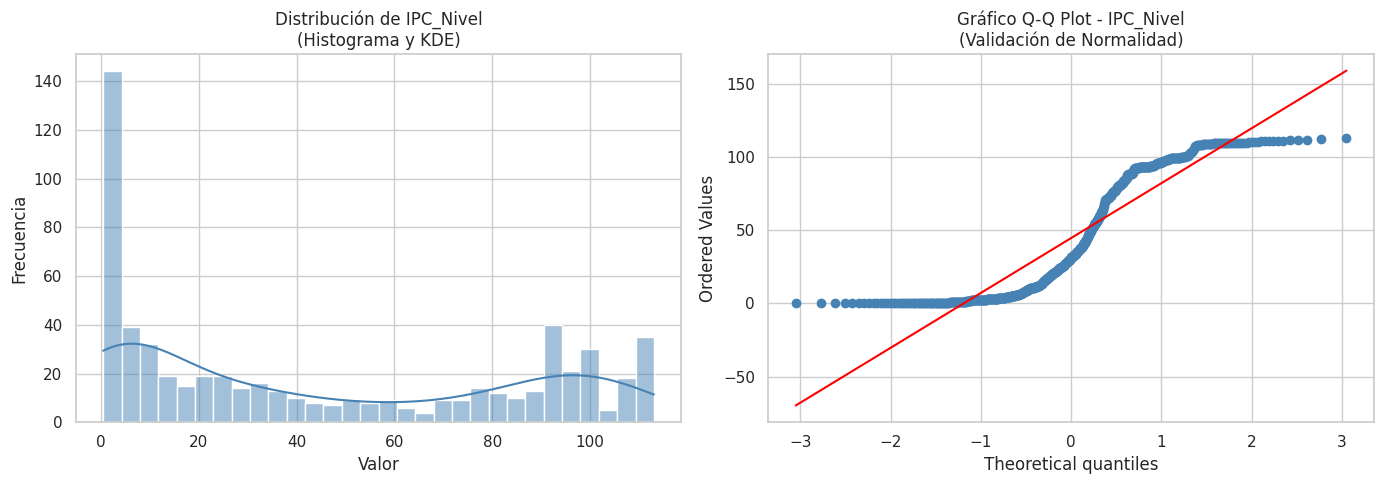

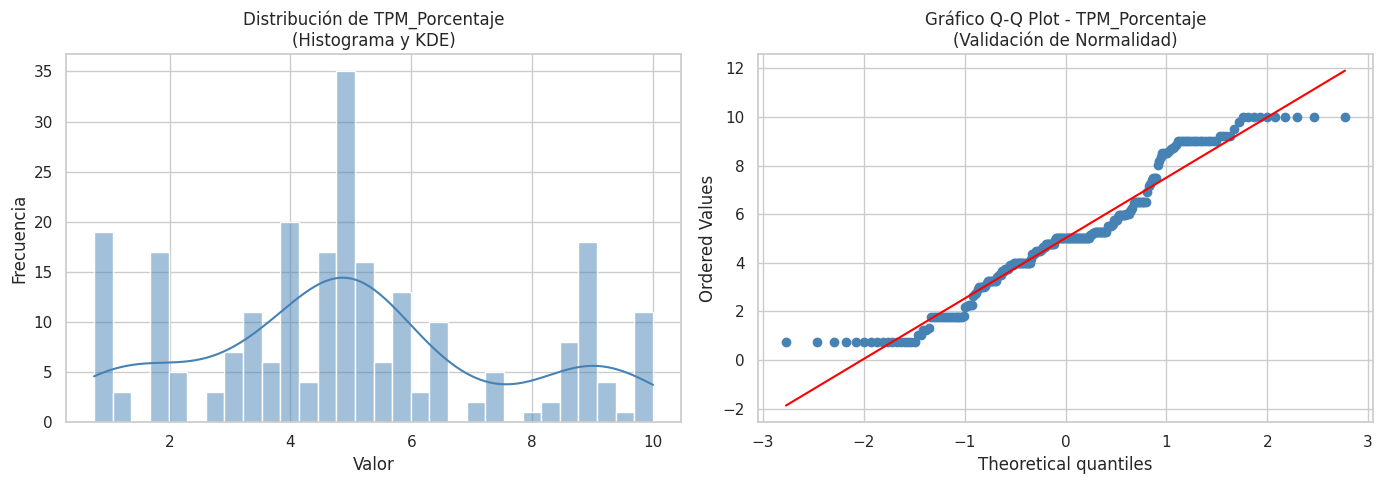

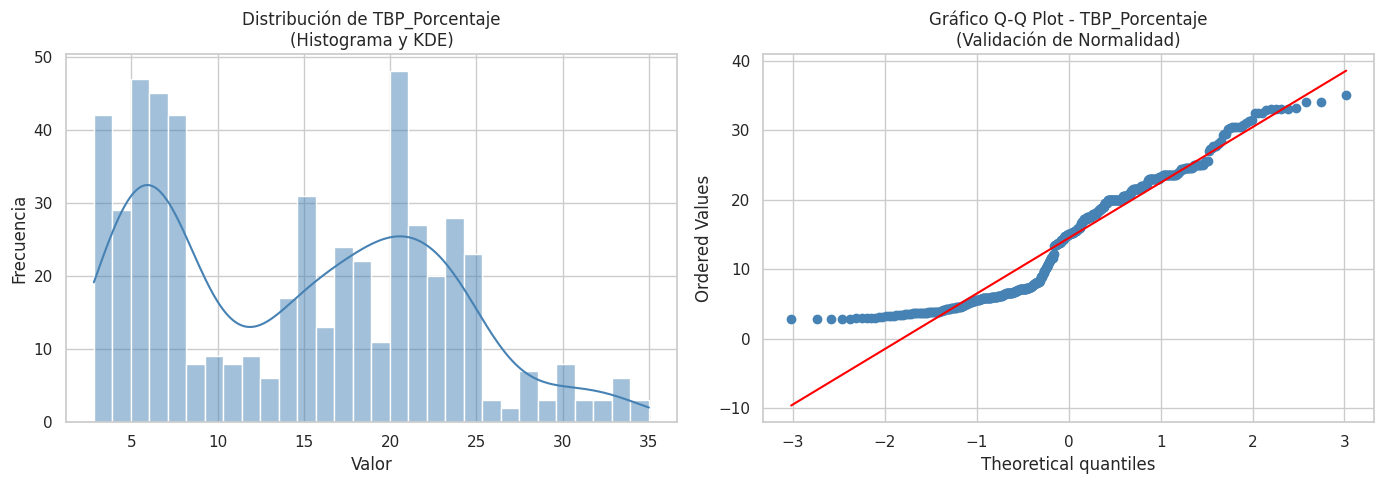

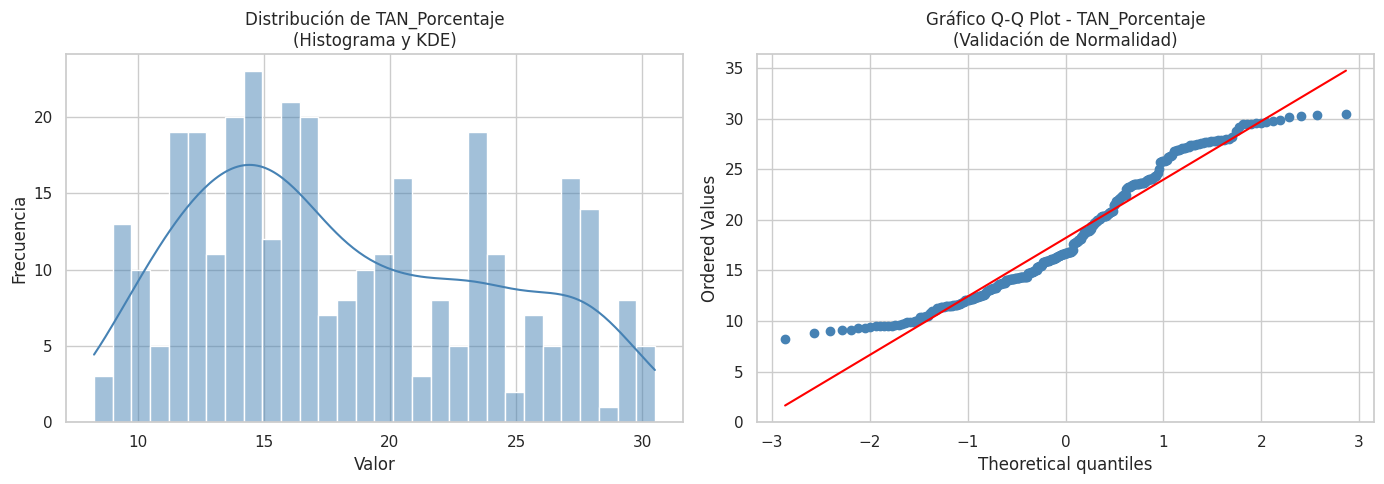

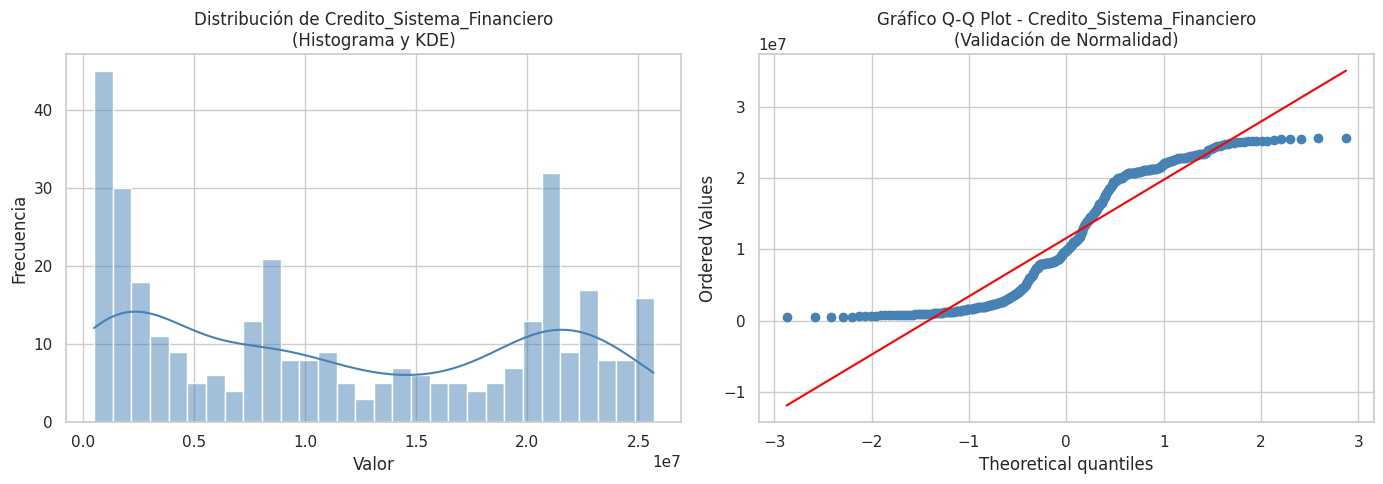

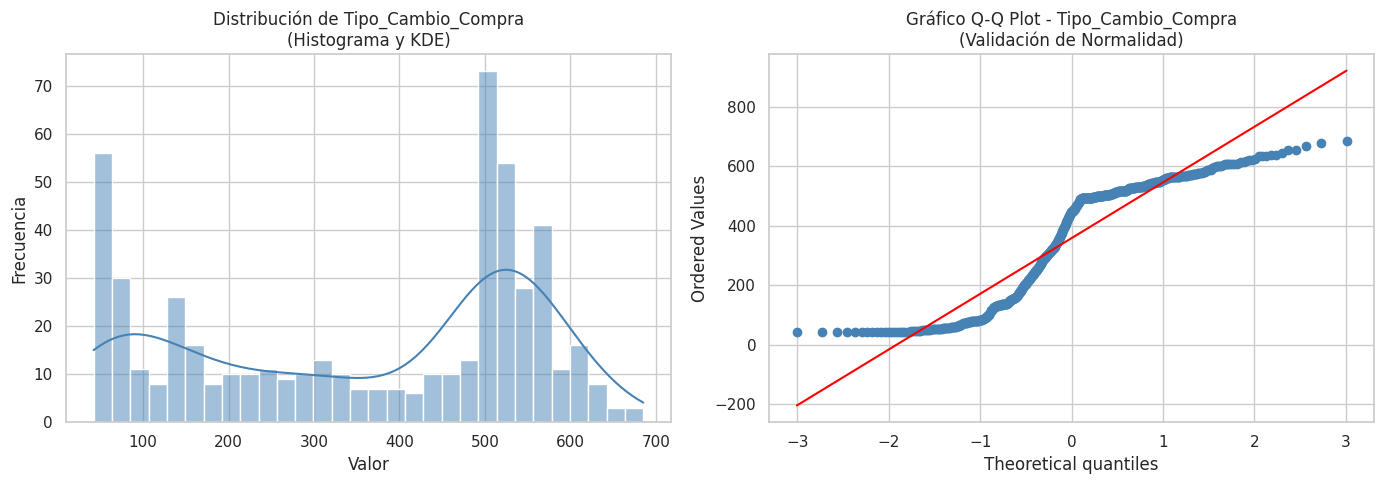

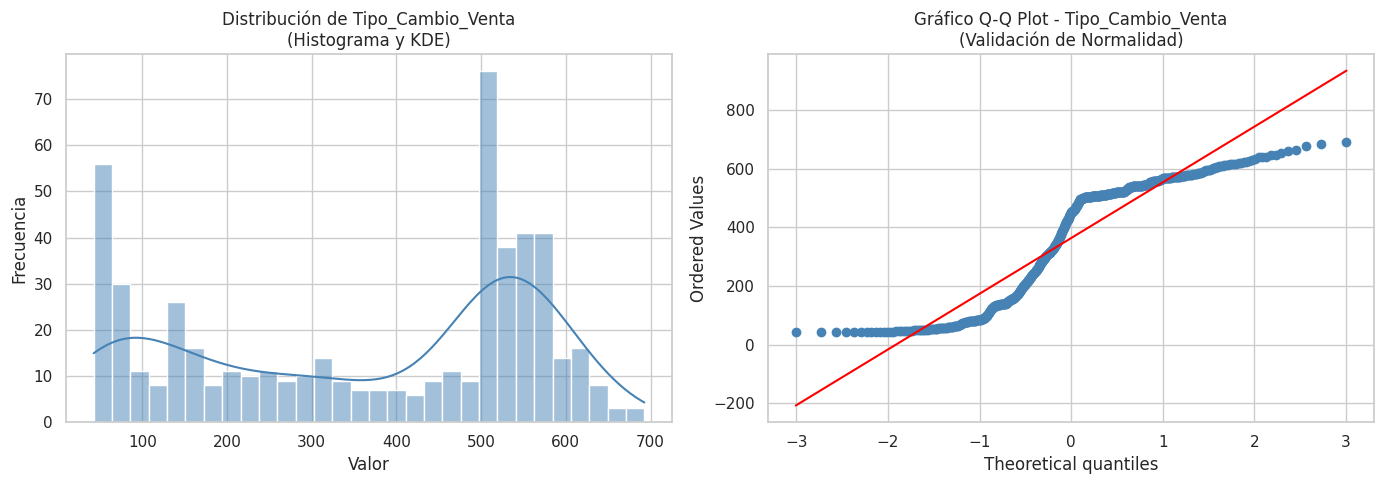


═════════════════════════════════════════════════════════════════════════════════════
  AUDITORÍA ESTADÍSTICA FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════
  ALERTA ECONOMÉTRICA:
    Si las colas de las observaciones (puntos azules) en los Q-Q Plots se alejan
    drásticamente de la distribución teórica (línea roja), se evidencia asimetría.
    Considere utilizar métodos de ML No Lineales (XGBoost) en lugar de regresiones OLS clásicas.


In [ ]:
# ==============================================================================
# PARTE 2: AUDITORÍA ESTADÍSTICA Y ANÁLISIS EXPLORATORIO
# ==============================================================================


# Configuración visual para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------------------------------------------------------------
# FUNCIONES DE PREPROCESAMIENTO Y AUDITORÍA
# ------------------------------------------------------------------------------

def homologar_frecuencias(df):
    """Homologa frecuencias temporales a promedios mensuales."""
    print("\n" + "═"*85)
    print("  ALINEACIÓN TEMPORAL (FRECUENCIA MENSUAL)")
    print("═"*85)
    print("    Homologando frecuencias diarias/semanales a promedios mensuales...")

    df_temp = df.copy()

    if 'Fecha' in df_temp.columns:
        df_temp.set_index('Fecha', inplace=True)

    df_temp.index = pd.to_datetime(df_temp.index)

    # Resample mensual (promedio) y eliminación de filas completamente vacías
    df_mensual = df_temp.resample('ME').mean().dropna(how='all')
    print(f"    Dataset alineado. Dimensión resultante: {df_mensual.shape}")
    return df_mensual

def calcular_estadisticas_descriptivas(df, variables):
    """Calcula medidas de posición central y dispersión."""
    print("\n" + "═"*85)
    print("  ESTADÍSTICOS DESCRIPTIVOS (TENDENCIA Y DISPERSIÓN)")
    print("═"*85)
    print("    Calculando medidas paramétricas fundamentales...")

    stats_dict = {}

    for col in variables:
        serie = df[col].dropna()
        media = serie.mean()
        mediana = serie.median()
        varianza = serie.var()
        desviacion = serie.std()

        # Coeficiente de Variación (S / Media)
        cv = (desviacion / media) * 100 if media != 0 else np.nan

        stats_dict[col] = {
            'N (Obs)': len(serie),
            'Mínimo': serie.min(),
            'Máximo': serie.max(),
            'Media (x̄)': media,
            'Mediana (Me)': mediana,
            'Varianza (S²)': varianza,
            'Desv. Est (S)': desviacion,
            'CV (%)': cv
        }

    df_descriptiva = pd.DataFrame(stats_dict).T
    print("\n  Resumen Descriptivo del Panel:")
    display(df_descriptiva.round(2))
    return df_descriptiva

def detectar_y_tratar_outliers(df, variables, accion='reportar'):
    """Detecta valores atípicos mediante IQR."""
    print("\n" + "═"*85)
    print("  DETECCIÓN DE CHOQUES MACROECONÓMICOS (OUTLIERS)")
    print("═"*85)
    print("    Aplicando método de Rango Intercuartílico (IQR)...\n")

    df_out = df.copy()

    for col in variables:
        serie = df_out[col].dropna()
        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)
        IQR = Q3 - Q1

        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR

        outliers = serie[(serie < limite_inf) | (serie > limite_sup)]

        if not outliers.empty:
            print(f"        {col}: Se detectaron {len(outliers)} valores atípicos.")
            # Si a futuro se decide limitar los extremos (Winsorizing) descomentar esto:
            # if accion == 'winsorize':
            #     df_out[col] = np.clip(df_out[col], limite_inf, limite_sup)
        else:
            print(f"        {col}: Sin valores atípicos severos.")

    print("\n  NOTA: En series macroeconómicas, los outliers suelen representar choques reales, por lo que se recomienda su preservación.")
    return df_out

def evaluar_normalidad(df, variables):
    """Genera validación visual de distribución mediante Histogramas y Q-Q Plots."""
    print("\n" + "═"*85)
    print("  EVALUACIÓN VISUAL DE NORMALIDAD (HISTOGRAMAS Y Q-Q PLOTS)")
    print("═"*85)
    print("    Generando gráficos de densidad de probabilidad...")

    for col in variables:
        serie = df[col].dropna()
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Histograma con Curva de Densidad KDE
        sns.histplot(serie, kde=True, ax=ax[0], color='steelblue', bins=30)
        ax[0].set_title(f"Distribución de {col}\n(Histograma y KDE)", fontsize=12)
        ax[0].set_xlabel("Valor")
        ax[0].set_ylabel("Frecuencia")

        # Gráfico Q-Q Plot
        stats.probplot(serie, dist="norm", plot=ax[1])
        ax[1].set_title(f"Gráfico Q-Q Plot - {col}\n(Validación de Normalidad)", fontsize=12)
        ax[1].get_lines()[0].set_markerfacecolor('steelblue')
        ax[1].get_lines()[0].set_markeredgecolor('steelblue')
        ax[1].get_lines()[1].set_color('red')

        plt.tight_layout()
        plt.show()

def optimizar_tipos_categoricos(df, umbral_unicos=10):
    """Convierte columnas de texto con baja cardinalidad a tipo categórico (Útil para SUGEF)."""
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() <= umbral_unicos:
            df[col] = df[col].astype('category')
    return df

# ==============================================================================
# EJECUCIÓN
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO AUDITORÍA ESTADÍSTICA DEL DATASET")
    print("═"*85)

    try:
        # Cargar el dataset consolidado desde el entorno local
        dataset_maestro = pd.read_csv("Dataset_Macro_BCCR_Completo.csv")

        # Asegurar que la columna Fecha se lea correctamente como formato temporal
        if 'Fecha' in dataset_maestro.columns:
            dataset_maestro['Fecha'] = pd.to_datetime(dataset_maestro['Fecha'])

        # Alineación
        df_mensual = homologar_frecuencias(dataset_maestro)
        variables_analisis = df_mensual.columns.tolist()

        # Estadística Descriptiva
        df_descriptiva = calcular_estadisticas_descriptivas(df_mensual, variables_analisis)

        # Tratamiento/Reporte de Outliers
        df_mensual_tratado = detectar_y_tratar_outliers(df_mensual, variables_analisis, accion='reportar')

        # Normalidad visual
        evaluar_normalidad(df_mensual_tratado, variables_analisis)

        print("\n" + "═"*85)
        print("  AUDITORÍA ESTADÍSTICA FINALIZADA")
        print("═"*85)
        print("  ALERTA ECONOMÉTRICA:")
        print("    Si las colas de las observaciones (puntos azules) en los Q-Q Plots se alejan")
        print("    drásticamente de la distribución teórica (línea roja), se evidencia asimetría.")
        print("    Considere utilizar métodos de ML No Lineales (XGBoost) en lugar de regresiones OLS clásicas.")

    except FileNotFoundError:
        print("\n  Error crítico: No se encontró el archivo 'Dataset_Macro_BCCR_Completo.csv'.")
        print("    Por favor, asegúrese de haber ejecutado el SCRIPT 1 primero para generar los datos.")

### Diagnóstico Estadístico y Asimetría del Mercado

La auditoría estadística del panel macroeconómico no solo certifica la calidad de los datos, sino que revela las cicatrices matemáticas del mercado financiero costarricense. Al observar los estadísticos descriptivos y las pruebas de distribución, emergen dos conclusiones fundamentales que validan tanto la hipótesis de oligopolio como la decisión de utilizar modelos de Inteligencia Artificial avanzada.


Por un lado, el análisis de tendencia central confirma la falla de mercado que se investiga. Históricamente, la Tasa de Política Monetaria (TPM), que es el costo mayorista del dinero, ha mantenido una media de 5.03%. Sin embargo, la Tasa Activa Negociada (TAN), la cual se refiere al costo real que asumen las empresas, promedia un 18.24%. Esta diferencia de más de 13 puntos porcentuales es prueba de un mercado concentrado. En un sistema verdaderamente competitivo, los márgenes de intermediación tienden a comprimirse. Aquí, por el contrario, los datos demuestran que las entidades financieras gozan del poder suficiente para retener primas de riesgo excesivas. Si a este entorno ya rígido le restamos al Banco de Costa Rica (BCR) como contrapeso público, la estadística nos advierte que la presión sobre el diferencial de tasas (Spread) tenderá al alza.


Un hallazgo metodológico crucial es la ausencia de valores atípicos severos (outliers) bajo el filtro del rango intercuartílico. En más de 600 meses de historia, el sistema ha atravesado crisis fiscales, pandemias y devaluaciones, con el tipo de cambio variando entre 42 y 692 colones. Que estos picos no se registren como errores estadísticos significa que los choques macroeconómicos son parte de la naturaleza orgánica de Costa Rica. El modelo no debe suavizar ni eliminar estos eventos, debe aprender de ellos.


Por otro lado, las pruebas visuales (Q-Q Plots y curvas KDE) demuestran que las variables macroeconómicas no siguen una distribución normal (la clásica "campana de Gauss"). Las observaciones se alejan drásticamente de la línea roja teórica, evidenciando asimetrías y colas pesadas, por lo que los modelos clásicos de regresión lineal no sirven para estos escenarios.

In [ ]:
# ==============================================================================
# PARTE 3: TRANSFORMACIÓN, MISSFOREST Y FEATURE ENGINEERING PANEL
# ==============================================================================

# ------------------------------------------------------------------------------
# FUNCIÓN DE PROCESAMIENTO SUGEF
# ------------------------------------------------------------------------------

def procesar_archivo_sugef(ruta_archivo, etiqueta):
    print(f"    Procesando {etiqueta}...")

    df = pd.read_excel(ruta_archivo, header=1, engine='openpyxl')

    # Añadir Saldo Productos a la extracción
    df = df.iloc[:, [0, 1, 2, 3, 8, 9]].copy()
    df.columns = ['Periodo', 'Sector', 'Entidad', 'CategoriaRiesgo', 'Total_Prin', 'Total_Prod']

    # Limpieza
    df = df.dropna(subset=['Periodo'])
    df = df[(df['Entidad'] != 'Total') & (df['CategoriaRiesgo'] != 'Total') & (df['Entidad'].notnull())]
    df['Total_Prin'] = pd.to_numeric(df['Total_Prin'], errors='coerce').fillna(0)
    df['Total_Prod'] = pd.to_numeric(df['Total_Prod'], errors='coerce').fillna(0)

    # Homologación de nombres
    diccionario_nombres = {
        'BANCO NACIONAL DE COSTA RICA': 'BANCO NACIONAL',
        'BANCO BAC SAN JOSE S.A.': 'BANCO BAC SANJOSE',
        'BANCO POPULAR Y DE DESARROLLO COMUNAL': 'BANCO POPULAR',
        'BANCO DE COSTA RICA': 'BCR'
    }
    df['Entidad'] = df['Entidad'].replace(diccionario_nombres)
    df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce') + pd.offsets.MonthEnd(0)

    # Agrupar sumando Principal y Productos
    mkt = df.groupby(['Periodo', 'Entidad'], observed=False)[['Total_Prin', 'Total_Prod']].sum().reset_index()

    # Cálculo de la Tasa Implícita Microeconómica (%)
    mkt['Tasa_Implicita_Micro_%'] = (mkt['Total_Prod'] / mkt['Total_Prin']) * 100
    mkt['Tasa_Implicita_Micro_%'] = mkt['Tasa_Implicita_Micro_%'].replace([np.inf, -np.inf], np.nan).fillna(0)

    # Morosidad
    df['CategoriaRiesgo'] = df['CategoriaRiesgo'].astype(str).str.strip().str.upper()
    cat_mora = ['3', '4', '5', '6', '7', '8', 'C1', 'C2', 'D', 'E']
    mora = df[df['CategoriaRiesgo'].isin(cat_mora)]
    mora_val = mora.groupby(['Periodo', 'Entidad'], observed=False)['Total_Prin'].sum().reset_index(name='Mora_Prin')

    mora_df = mkt[['Periodo', 'Entidad', 'Total_Prin']].merge(mora_val, on=['Periodo', 'Entidad'], how='left').fillna(0)
    mora_df['Morosidad_%'] = (mora_df['Mora_Prin'] / mora_df['Total_Prin']) * 100

    return mkt.merge(mora_df[['Periodo', 'Entidad', 'Morosidad_%']], on=['Periodo', 'Entidad'])

# ------------------------------------------------------------------------------
# FUNCIONES DE IMPUTACIÓN Y FEATURE ENGINEERING
# ------------------------------------------------------------------------------

def aplicar_missforest_auditado(df, cols_imputacion):
    print("\n" + "═"*85)
    print("  MISSFOREST SIN DATA LEAKAGE")
    print("═"*85)
    print("    Entrenando RandomForestRegressor solo con datos históricos (80%)...")

    # Asegurar orden cronológico para el split
    df_sorted = df.sort_values('Fecha').reset_index(drop=True)

    # Definir el punto de corte (80% pasado, 20% futuro)
    split_idx = int(len(df_sorted) * 0.8)

    # Aislar la muestra de entrenamiento (Evitar Data Leakage)
    df_train = df_sorted.iloc[:split_idx][cols_imputacion]
    nulos_iniciales = df[cols_imputacion].isna().sum().sum()

    # Instanciar el imputador
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=15, random_state=42),
        max_iter=10,
        random_state=42
    )

    # Entrenar (fit) SOLO con el pasado
    imputer.fit(df_train)
    print("      ↳ Reglas de imputación aprendidas estrictamente del pasado (Evitando Data Leakage).")

    # Transformar (transform) todo el dataset usando las reglas del pasado
    df_imputado = df.copy()
    df_imputado[cols_imputacion] = imputer.transform(df[cols_imputacion])

    print(f"    {nulos_iniciales} valores nulos imputados exitosamente conservando varianza local.")
    return df_imputado

def generar_variables_panel(df):
    print("\n" + "═"*85)
    print("  FEATURE ENGINEERING (PANEL LONGITUDINAL)")
    print("═"*85)
    print("    Calculando Variaciones Interanuales, Spreads y Rezagos Dinámicos (Lags)...")

    df['Inflacion_Interanual_%'] = (df['IPC_Nivel'] / df.groupby('Entidad', observed=False)['IPC_Nivel'].shift(12) - 1) * 100
    df['Crecimiento_Credito_%'] = (df['Credito_Sistema_Financiero'] / df.groupby('Entidad', observed=False)['Credito_Sistema_Financiero'].shift(12) - 1) * 100
    df['Devaluacion_Interanual_%'] = (df['Tipo_Cambio_Venta'] / df.groupby('Entidad', observed=False)['Tipo_Cambio_Venta'].shift(12) - 1) * 100
    df['Spread_Bancario'] = df['TAN_Porcentaje'] - df['TBP_Porcentaje']
    df['Spread_Cambiario'] = df['Tipo_Cambio_Venta'] - df['Tipo_Cambio_Compra']
    df['Cuota_%_Lag6'] = df.groupby('Entidad', observed=False)['Cuota_%'].shift(6)
    df['Morosidad_Lag3'] = df.groupby('Entidad', observed=False)['Morosidad_%'].shift(3)
    df['Morosidad_Lag6'] = df.groupby('Entidad', observed=False)['Morosidad_%'].shift(6)
    df['IHH_Lag6'] = df.groupby('Entidad', observed=False)['IHH'].shift(6)
    df['TPM_Lag3'] = df.groupby('Entidad', observed=False)['TPM_Porcentaje'].shift(3)
    df['Inflacion_Lag3'] = df.groupby('Entidad', observed=False)['Inflacion_Interanual_%'].shift(3)

    filas_antes = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_final = df.dropna().reset_index(drop=True)
    filas_perdidas = filas_antes - len(df_final)

    print(f"    Se sacrificaron {filas_perdidas} registros debido a la generación de rezagos temporales.")
    return df_final

# ------------------------------------------------------------------------------
# SINCRONIZACIÓN CON GITHUB
# ------------------------------------------------------------------------------
def sincronizar_con_github(df, nombre_archivo, token, nombre_repo):
    """Crea o sobreescribe un archivo CSV directamente en GitHub."""
    print(f"    Sincronizando {nombre_archivo} con la nube (GitHub)...")

    csv_data = df.to_csv(index=False, encoding='utf-8')
    g = Github(token)
    repo = g.get_repo(nombre_repo)
    ruta_en_repo = f"data/{nombre_archivo}"

    try:
        contents = repo.get_contents(ruta_en_repo)
        repo.update_file(contents.path, f"Actualización automática: {nombre_archivo}", csv_data, contents.sha)
        print("      ↳ Archivo actualizado exitosamente (Versión anterior eliminada).")
    except:
        repo.create_file(ruta_en_repo, f"Creación inicial: {nombre_archivo}", csv_data)
        print("      ↳ Archivo creado exitosamente en el repositorio.")

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO PROCESAMIENTO ESTRUCTURAL DE DATOS PANEL")
    print("═"*85)

    # Rutas de datos
    file_macro = "Dataset_Macro_BCCR_Completo.csv"
    file_sugef_pre = 'TFM_Analisis_Datos_2026/data/Detalle del Saldo Principal y Productos, por categoría de riesgo pre 2024.xlsx'
    file_sugef_post = 'TFM_Analisis_Datos_2026/data/Detalle del Saldo Principal y Productos, por Categoría de Riesgo post 2024.xlsx'
    NOMBRE_REPO = 'Jeezar16/TFM_Analisis_Datos_2026'

    try:
       # Empalme SUGEF
        print("\n  EMPALME DE CARTERAS SUGEF")
        print("-" * 85)
        panel_pre = procesar_archivo_sugef(file_sugef_pre, "Cartera Histórica (Pre-2024)")
        panel_post = procesar_archivo_sugef(file_sugef_post, "Cartera Reciente (Post-2024)")

        # Unir los archivos primero
        df_panel_sugef = pd.concat([panel_pre, panel_post], ignore_index=True)
        df_panel_sugef.rename(columns={'Periodo': 'Fecha'}, inplace=True)

        # CÁLCULO DEL MERCADO CORREGIDO
        df_panel_sugef['Cuota_%'] = (df_panel_sugef['Total_Prin'] / df_panel_sugef.groupby('Fecha', observed=False)['Total_Prin'].transform('sum')) * 100
        ihh = df_panel_sugef.assign(IHH=df_panel_sugef['Cuota_%']**2).groupby('Fecha', observed=False)['IHH'].sum().reset_index()

        # Si la función original ya había calculado un IHH, se borra
        if 'IHH' in df_panel_sugef.columns:
            df_panel_sugef = df_panel_sugef.drop(columns=['IHH', 'Cuota_%'])

        df_panel_sugef = df_panel_sugef.merge(ihh, on='Fecha')
        df_panel_sugef['Cuota_%'] = (df_panel_sugef['Total_Prin'] / df_panel_sugef.groupby('Fecha', observed=False)['Total_Prin'].transform('sum')) * 100

        df_panel_sugef['Entidad'] = df_panel_sugef['Entidad'].astype('category')
        df_panel_sugef = df_panel_sugef.sort_values(['Entidad', 'Fecha']).drop_duplicates(subset=['Fecha', 'Entidad'])

        # Cruce con BCCR
        print("\n" + "═"*85)
        print("  CRUCE BCCR Y SUGEF")
        print("═"*85)
        print("    Sincronizando frecuencias y uniendo datasets...")
        df_macro = pd.read_csv(file_macro, encoding='utf-8')
        df_macro['Fecha'] = pd.to_datetime(df_macro['Fecha'])
        df_macro = df_macro.set_index('Fecha').resample('ME').last().reset_index()
        df_macro['Fecha'] = df_macro['Fecha'] + pd.offsets.MonthEnd(0)

        dataset_modelado = df_panel_sugef.merge(df_macro, on='Fecha', how='left')
        dataset_modelado = dataset_modelado.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)

        # Imputación
        cols_imputacion = ['Cuota_%', 'IHH', 'Morosidad_%', 'IPC_Nivel', 'TPM_Porcentaje',
                           'TBP_Porcentaje', 'TAN_Porcentaje', 'Credito_Sistema_Financiero',
                           'Tipo_Cambio_Compra', 'Tipo_Cambio_Venta']

        dataset_modelado = aplicar_missforest_auditado(dataset_modelado, cols_imputacion)

        # Guardado Pre-Imputación (Local)
        ruta_pre_imputacion = "TFM_Analisis_Datos_2026/data/Dataset_PRE_Imputacion.csv"
        columnas_guardar = ['Entidad', 'Fecha'] + cols_imputacion
        dataset_pre_imputacion_df = dataset_modelado[columnas_guardar]
        dataset_pre_imputacion_df.to_csv(ruta_pre_imputacion, index=False)

        # Feature Engineering
        dataset_final = generar_variables_panel(dataset_modelado)

        # Guardado Transformado (Local)
        ruta_guardado = "TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv"
        dataset_final.to_csv(ruta_guardado, index=False, encoding='utf-8')

        print("\n" + "═"*85)
        print("  PANEL ESTRUCTURAL FINALIZADO")
        print("═"*85)
        print(f"    Registros listos para modelar: {len(dataset_final)}")
        print(f"    Entidades bancarias únicas: {dataset_final['Entidad'].nunique()}")
        print(f"    Archivos guardados en local.")

        # Lógica de guardado en la nube (Dependiente del menú de la Parte 0)
        if ACTUALIZAR_GITHUB:
            print("\n  Iniciando respaldo en la nube...")
            sincronizar_con_github(dataset_pre_imputacion_df, 'Dataset_PRE_Imputacion.csv', GITHUB_TOKEN, NOMBRE_REPO)
            sincronizar_con_github(dataset_final, 'Dataset_Panel_Transformado_Modelado.csv', GITHUB_TOKEN, NOMBRE_REPO)
        else:
            print("\n  [MODO LOCAL] Se omitió la subida de los datasets a GitHub.")

        # ------------------------------------------------------------------------------
        # EVIDENCIA EMPÍRICA: DEMOSTRACIÓN DEL ANCLA DE TASAS (BCR)
        # ------------------------------------------------------------------------------
        print("\n" + "═"*85)
        print("  EVIDENCIA EMPÍRICA A PRIORI: TASA IMPLÍCITA MICROECONÓMICA")
        print("═"*85)
        print("    Cálculo: (Saldo de Productos / Saldo Principal) extraído de balances SUGEF.")

        # Filtrar los 4 oligopolios principales para la demostración
        top_bancos = ['BANCO NACIONAL', 'BCR', 'BANCO BAC SANJOSE', 'BANCO POPULAR']
        df_top = dataset_final[dataset_final['Entidad'].isin(top_bancos)]

        # Calcular el costo promedio cobrado a lo largo de toda su historia
        ranking_tasas = df_top.groupby('Entidad', observed=True)['Tasa_Implicita_Micro_%'].mean().sort_values()

        print("\n    Ranking del Costo Real de Crédito (Promedio Histórico Mensual):")
        for banco, tasa in ranking_tasas.items():
            marcador = "  (ANCLA DEL MERCADO)" if banco == 'BCR' else ""
            print(f"       {banco.ljust(18)} : {tasa:.3f}%{marcador}")

        print("\n    CONCLUSIÓN EMPÍRICA:")
        print("       Los datos puros demuestran matemáticamente que el BCR mantiene sistemáticamente")
        print("       la tasa de interés más baja del oligopolio. Esto valida de forma empírica su rol")
        print("       como 'ancla a la baja' antes de aplicar cualquier modelo de Machine Learning.")

    except Exception as err:
        print(f"\n  Error crítico en la ejecución: {err}")


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO PROCESAMIENTO ESTRUCTURAL DE DATOS PANEL
═════════════════════════════════════════════════════════════════════════════════════

  EMPALME DE CARTERAS SUGEF
-------------------------------------------------------------------------------------
    Procesando Cartera Histórica (Pre-2024)...
    Procesando Cartera Reciente (Post-2024)...

═════════════════════════════════════════════════════════════════════════════════════
  CRUCE BCCR Y SUGEF
═════════════════════════════════════════════════════════════════════════════════════
    Sincronizando frecuencias y uniendo datasets...

═════════════════════════════════════════════════════════════════════════════════════
  MISSFOREST SIN DATA LEAKAGE
═════════════════════════════════════════════════════════════════════════════════════
    Entrenando RandomForestRegressor solo con datos históricos (80%)...
      ↳ Reglas de imputación aprendidas estr

### Construcción Estructural y el BCR como Ancla



Antes de lanzar cualquier predicción, el modelo debe ser capaz de entender el tiempo y la realidad. Al sacrificar 901 registros para generar rezagos dinámicos, la base de datos asume que la economía no es instantánea (por ejemplo, que un alza en el tipo de cambio hoy, afecta la morosidad meses después). Además, la recuperación de datos mediante MissForest garantiza que no hay agujeros en la historia financiera.

Para asegurar la máxima rigurosidad metodológica y evitar la contaminación predictiva conocida como fuga de información (data leakage), esta imputación se ejecutó bajo un estricto esquema de ventana ciega. El algoritmo de Inteligencia Artificial aprendió las reglas matemáticas para rellenar los vacíos estudiando exclusivamente el 80% más antiguo de los datos; luego, utilizó esas reglas históricas para reconstruir el panel completo. Esto garantiza que el modelo no haga trampa viajando al futuro para aprender cómo corregir el pasado, manteniendo la secuencia temporal completamente pura e imparcial.

Hasta este punto de la investigación, afirmar que el Banco de Costa Rica (BCR) regulaba los precios del mercado a la baja era una hipótesis basada en la teoría del oligopolio. Al extraer la Tasa Implícita (es decir, dividir los intereses reales que los bancos le cobran a sus clientes entre la deuda viva que estos mantienen), la hipótesis se comprueba empíricamente.

Los datos puros de los balances muestran que el BCR opera sistemáticamente con el costo real de crédito más bajo del mercado (0.741% promedio histórico mensual). Si lo comparamos con el Banco Nacional (1.154%) o el Banco Popular (1.064%), se nota una diferencia estructural en términos de márgenes de intermediación. El BCR actúa, de facto, como el piso de los precios.


El Estado mantiene dentro del oligopolio a un actor que presiona los precios hacia abajo por pura competencia. Si el BCR se vende y su cartera es absorbida por los otros actores grandes (cuyas tasas históricas son demostrablemente más altas), el mercado financiero pierde su ancla. Sin la fricción competitiva del banco más barato, las entidades sobrevivientes tendrán vía libre para encarecer el costo del fondeo corporativo sin temor a perder clientes, consolidando un oligopolio extractivo.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO ARQUITECTURA HÍBRIDA (ECONOMETRÍA + MACHINE LEARNING)
═════════════════════════════════════════════════════════════════════════════════════

  INTEGRACIÓN DE DATOS
-------------------------------------------------------------------------------------
    Cargando y auditando el panel de datos histórico...
      ↳ Panel cargado exitosamente. Dimensiones útiles: (8343, 26)
    Preparando rezagos dinámicos y estructura de panel longitudinal...

═════════════════════════════════════════════════════════════════════════════════════
  ESTIMACIÓN DE PANEL DINÁMICO (EFECTOS FIJOS)
═════════════════════════════════════════════════════════════════════════════════════
    Ejecutando regresión estructural (PanelOLS) para validación de hipótesis...

                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-valu

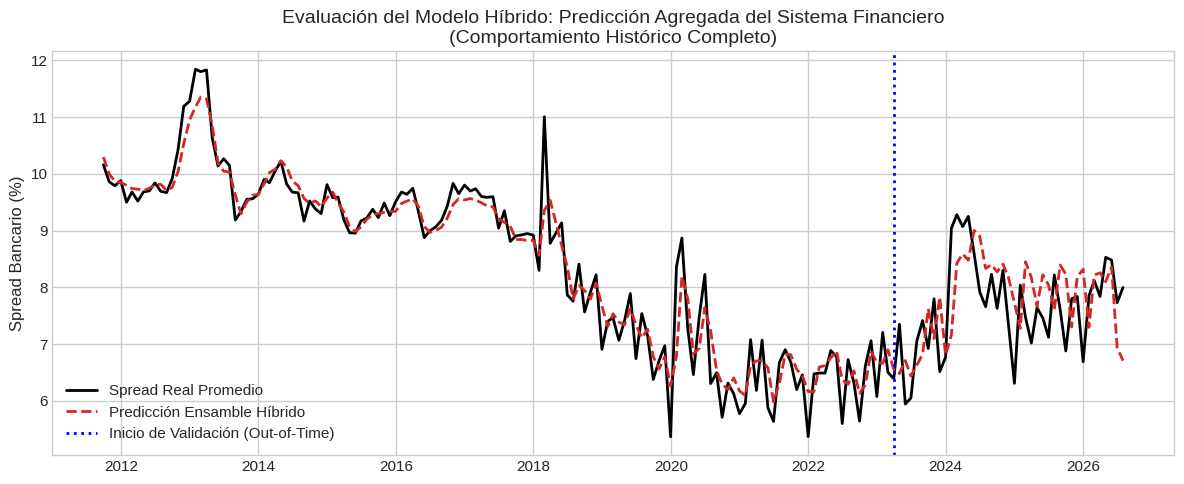


═════════════════════════════════════════════════════════════════════════════════════
  EXPLICABILIDAD DEL MODELO XGBOOST
═════════════════════════════════════════════════════════════════════════════════════
    Calculando impacto marginal de las variables sobre el costo crediticio...


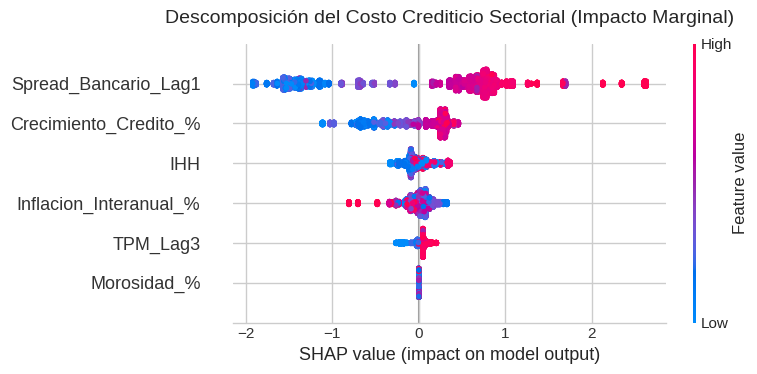

   Valores SHAP exportados para Dashboard a: TFM_Analisis_Datos_2026/data/SHAP_Export_Dashboard.csv

═════════════════════════════════════════════════════════════════════════════════════
  SIMULACIÓN DE MONTECARLO ESTRUCTURAL (ENSAMBLE HÍBRIDO + EFECTOS FIJOS)
═════════════════════════════════════════════════════════════════════════════════════
    Inyectando 5000 escenarios de estrés continuos para 37 entidades...
      IHH Promedio Simulado : 1600.8
      TPM Promedio Simulada : 3.24%
      Spread Promedio Final : 7.6184%
      Valores únicos gen.   : 25000 (Curva continua e idiosincrática confirmada)

  Datos de simulación exportados a: TFM_Analisis_Datos_2026/data/Montecarlo_Export_Dashboard.csv
═════════════════════════════════════════════════════════════════════════════════════

  Sincronizando Montecarlo_Export_Dashboard.csv con la nube (GitHub)...
      ↳ Archivo actualizado exitosamente (Versión anterior eliminada).


In [ ]:
# ==============================================================================
# PARTE 4: MODELADO HÍBRIDO (PANEL + LASSO + XGBOOST), XAI Y MONTECARLO
# ==============================================================================

plt.style.use('seaborn-v0_8-whitegrid')

# ------------------------------------------------------------------------------
# CLASE DE PREDICTOR HÍBRIDO (LASSO + XGBOOST)
# ------------------------------------------------------------------------------
class PredictorHibrido:
    """
    Combina las predicciones continuas de Lasso con la capacidad no lineal de XGBoost.
    Garantiza distribuciones continuas y realistas en simulaciones de Montecarlo.
    """
    def __init__(self, modelo_xgb, modelo_lasso, peso_lasso=0.6):
        self.modelo_xgb = modelo_xgb
        self.modelo_lasso = modelo_lasso
        self.peso_lasso = peso_lasso

    def predict(self, X_input):
        pred_xgb = self.modelo_xgb.predict(X_input)
        pred_lasso = self.modelo_lasso.predict(X_input)
        # Combinación lineal ponderada
        return (self.peso_lasso * pred_lasso) + ((1 - self.peso_lasso) * pred_xgb)

# ------------------------------------------------------------------------------
# PREPARACIÓN Y AUDITORÍA DE DATOS
# ------------------------------------------------------------------------------
def optimizar_tipos_categoricos(df, umbral_unicos=20):
    """Convierte columnas de texto con baja cardinalidad a tipo categórico."""
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() <= umbral_unicos:
            df[col] = df[col].astype('category')
    return df

def cargar_y_auditar_panel(ruta):
    """Carga el dataset, audita la calidad y optimiza la memoria."""
    print("    Cargando y auditando el panel de datos histórico...")
    df = pd.read_csv(ruta, encoding='utf-8')
    df['Fecha'] = pd.to_datetime(df['Fecha'])

    # Limpieza preventiva de infinitos generados en divisiones previas
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = optimizar_tipos_categoricos(df)

    print(f"      ↳ Panel cargado exitosamente. Dimensiones útiles: {df.shape}")
    return df

def preparar_variables_panel(df, target):
    """Genera rezagos dinámicos aislados por entidad y prepara el panel."""
    print("    Preparando rezagos dinámicos y estructura de panel longitudinal...")
    df = df.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)

    # Creación del rezago del target (Spread_Bancario_Lag1)
    df[f'{target}_Lag1'] = df.groupby('Entidad', observed=False)[target].shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

# ------------------------------------------------------------------------------
# CAUSALIDAD Y ECONOMETRÍA DE PANEL
# ------------------------------------------------------------------------------
def estimar_panel_dinamico(df, target, features):
    """Estima el modelo PanelOLS con Efectos Fijos."""
    print("\n" + "═"*85)
    print("  ESTIMACIÓN DE PANEL DINÁMICO (EFECTOS FIJOS)")
    print("═"*85)
    print("    Ejecutando regresión estructural (PanelOLS) para validación de hipótesis...")

    df_panel = df.set_index(['Entidad', 'Fecha'])
    exog = sm.add_constant(df_panel[features])
    endog = df_panel[target]

    try:
        modelo_estructural = PanelOLS(endog, exog, entity_effects=True)
        resultados = modelo_estructural.fit(cov_type='robust')
        print("\n" + str(resultados.summary.tables[1]))
        print(f"\n   Ajuste Causal R-cuadrado (Within): {resultados.rsquared_within:.4f}")
        return resultados
    except Exception as err:
        print(f"\n   Advertencia Econométrica: {err}")
        return None

# ------------------------------------------------------------------------------
# MACHINE LEARNING & HÍBRIDO
# ------------------------------------------------------------------------------
def entrenar_xgboost_champion(df, target, features_base):
    """Entrena un modelo XGBoost con validación cruzada temporal y búsqueda de hiperparámetros."""
    print("\n" + "═"*85)
    print("  ENTRENAMIENTO PREDICTIVO (XGBOOST PANEL)")
    print("═"*85)
    print("    Aplicando TimeSeriesSplit y Búsqueda Aleatoria (Hyperparameter Tuning)...")

    df_ml = pd.get_dummies(df, columns=['Entidad'], drop_first=True, dtype=int)
    columnas_dummy = [col for col in df_ml.columns if col.startswith('Entidad_')]
    features_ml = features_base + columnas_dummy

    # Split Cronológico Estricto para evitar Data Leakage
    df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)
    X = df_ml[features_ml]
    y = df_ml[target]

    split_idx = int(len(df_ml) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    fechas_test = df_ml['Fecha'].iloc[split_idx:]

    tscv = TimeSeriesSplit(n_splits=3)
    param_grid = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 300],
        'reg_lambda': [1.0, 1.5, 2.0]
    }

    xgb_base = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
    random_search = RandomizedSearchCV(xgb_base, param_distributions=param_grid,
                                       n_iter=10, scoring='neg_mean_absolute_error',
                                       cv=tscv, random_state=42, n_jobs=-1)
    random_search.fit(X_train, y_train)

    best_xgb = random_search.best_estimator_
    y_pred = best_xgb.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"   MAE (Error Medio Absoluto) XGBoost Optimizado: {mae:.4f} puntos porcentuales")

    return best_xgb, X_train, df_ml, features_ml, split_idx

def entrenar_lasso_regularizado(X_train, y_train):
    """Entrena modelo Lasso para aportar continuidad matemática al híbrido."""
    print("\n" + "═"*85)
    print("  ENTRENAMIENTO REGRESIÓN LASSO REGULARIZADA")
    print("═"*85)
    print("    Entrenando modelo Lasso con validación cruzada y estandarización...")

    pipeline_lasso = make_pipeline(
        StandardScaler(),
        LassoCV(cv=5, random_state=42, max_iter=10000)
    )
    pipeline_lasso.fit(X_train, y_train)

    lasso_model = pipeline_lasso.named_steps['lassocv']
    print(f"      ↳ Alfa (penalización L1) óptimo elegido por CV: {lasso_model.alpha_:.6f}")
    print("      ↳ Modelo Lasso entrenado exclusivamente con el 80% histórico.")

    return pipeline_lasso


# ------------------------------------------------------------------------------
# EVALUACIÓN VISUAL Y MATEMÁTICA DEL ENSAMBLE
# ------------------------------------------------------------------------------
def evaluar_ajuste_hibrido(modelo, df_ml, target, features_ml, split_idx):
    """Calcula métricas de error del híbrido y genera el gráfico de línea de tiempo."""
    print("\n" + "═"*85)
    print("  EVALUACIÓN DEL ENSAMBLE HÍBRIDO (OUT-OF-TIME Y GRÁFICO)")
    print("═"*85)

    # EVALUACIÓN MATEMÁTICA (En la muestra de Prueba / Test)
    # Aislar los datos que el modelo NUNCA vio durante su entrenamiento
    df_sorted = df_ml.sort_values('Fecha').reset_index(drop=True)
    X_test = df_sorted[features_ml].iloc[split_idx:]
    y_test = df_sorted[target].iloc[split_idx:]

    # Predicción del híbrido solo en datos desconocidos
    y_pred_test = modelo.predict(X_test)

    # Cálculo de métricas
    mae_hibrido = mean_absolute_error(y_test, y_pred_test)
    rmse_hibrido = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_hibrido = r2_score(y_test, y_pred_test)

    print("    Métricas de Precisión del Modelo Híbrido (Datos no vistos):")
    print(f"      ↳ MAE (Error Medio Absoluto) : {mae_hibrido:.4f} puntos porcentuales")
    print(f"      ↳ RMSE (Raíz del Error)      : {rmse_hibrido:.4f} puntos porcentuales")
    print(f"      ↳ R-Cuadrado (Predictivo)    : {r2_hibrido:.4f}")
    print("\n    Generando gráfico de ajuste temporal...")

    # EVALUACIÓN VISUAL (En toda la línea de tiempo)
    y_pred_total = modelo.predict(df_sorted[features_ml])
    fecha_corte = df_sorted['Fecha'].iloc[split_idx]

    res_macro = pd.DataFrame({
        'Fecha': df_sorted['Fecha'],
        'Real': df_sorted[target],
        'Prediccion_Hibrida': y_pred_total
    }).groupby('Fecha').mean().reset_index()

    plt.figure(figsize=(12, 5))
    plt.plot(res_macro['Fecha'], res_macro['Real'], label='Spread Real Promedio', color='black', linewidth=2)
    plt.plot(res_macro['Fecha'], res_macro['Prediccion_Hibrida'], label='Predicción Ensamble Híbrido', color='#d62728', linestyle='--', linewidth=2)

    plt.axvline(x=fecha_corte, color='blue', linestyle=':', linewidth=2, label='Inicio de Validación (Out-of-Time)')

    plt.title('Evaluación del Modelo Híbrido: Predicción Agregada del Sistema Financiero\n(Comportamiento Histórico Completo)', fontsize=14)
    plt.ylabel('Spread Bancario (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# EXPLICABILIDAD Y SIMULACIÓN
# ------------------------------------------------------------------------------
def generar_explicabilidad_shap(modelo, X_train, features_base, ruta_export, fechas_train):
    """Calcula y exporta los valores SHAP del modelo."""
    print("\n" + "═"*85)
    print("  EXPLICABILIDAD DEL MODELO XGBOOST")
    print("═"*85)
    print("    Calculando impacto marginal de las variables sobre el costo crediticio...")

    explainer = shap.Explainer(modelo)
    shap_values = explainer(X_train)
    idx_financieras = [X_train.columns.get_loc(c) for c in features_base]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values.values[:, idx_financieras], X_train[features_base], show=False)
    plt.title('Descomposición del Costo Crediticio Sectorial (Impacto Marginal)', fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    shap_df = pd.DataFrame(shap_values.values[:, idx_financieras], columns=features_base)
    shap_df['Fecha'] = fechas_train
    shap_df.to_csv(ruta_export, index=False, encoding='utf-8')
    print(f"   Valores SHAP exportados para Dashboard a: {ruta_export}")

def simular_montecarlo_choque(modelo, df_ml, target, features_ml, ruta_export, n_simulaciones=5000):
    """Simula un escenario de estrés con salidas continuas (Modelo Híbrido) respetando el perfil histórico de cada entidad."""
    print("\n" + "═"*85)
    print("  SIMULACIÓN DE MONTECARLO ESTRUCTURAL (ENSAMBLE HÍBRIDO + EFECTOS FIJOS)")
    print("═"*85)

    ultima_fecha = df_ml['Fecha'].max()
    estado_actual = df_ml[df_ml['Fecha'] == ultima_fecha].copy()
    num_bancos = len(estado_actual)

    print(f"    Inyectando {n_simulaciones} escenarios de estrés continuos para {num_bancos} entidades...")

    # Calcular el efecto fijo de cada banco
    # Esto mide cuánto se desvía históricamente cada banco del promedio del sistema
    promedio_sistema_historico = df_ml[target].mean()
    primas_entidad = df_ml.groupby(
        [col for col in df_ml.columns if col.startswith('Entidad_')],
        as_index=False
    )[target].mean()
    primas_entidad['Prima_Riesgo'] = primas_entidad[target] - promedio_sistema_historico

    # Mapear el efecto al estado actual
    columnas_entidad = [col for col in df_ml.columns if col.startswith('Entidad_')]
    estado_actual = pd.merge(estado_actual, primas_entidad[columnas_entidad + ['Prima_Riesgo']], on=columnas_entidad, how='left')

    # Generar Escenarios Macro
    np.random.seed(42)
    ihh_simulados = np.clip(np.random.normal(loc=1600, scale=150, size=n_simulaciones), 0, None)

    tpm_actual = estado_actual['TPM_Lag3'].iloc[0] if 'TPM_Lag3' in estado_actual.columns else 5.0
    tpm_simulados = np.clip(np.random.normal(loc=tpm_actual, scale=1.5, size=n_simulaciones), 0, None)

    # Construir el multiverso de datos
    X_simulado = pd.concat([estado_actual[features_ml]] * n_simulaciones, ignore_index=True)
    X_simulado['IHH'] = np.repeat(ihh_simulados, num_bancos)
    if 'TPM_Lag3' in features_ml:
        X_simulado['TPM_Lag3'] = np.repeat(tpm_simulados, num_bancos)

    # Inferencia con el Modelo Híbrido (Genera el choque base)
    spreads_predichos_base = modelo.predict(X_simulado)

    # Acoplar la realidad histórica de cada banco al choque sistémico
    primas_repetidas = np.tile(estado_actual['Prima_Riesgo'].values, n_simulaciones)
    spreads_finales = spreads_predichos_base + (primas_repetidas * 0.8) # 0.8 suaviza el efecto para escenarios de estrés

    # Mapeo de Nombres de Entidades
    if columnas_entidad:
        entidades_base = estado_actual.set_index(columnas_entidad).index.to_frame(index=False)
        entidades_nombres = entidades_base.idxmax(axis=1).str.replace('Entidad_', '')
        entidades_nombres[entidades_base.sum(axis=1) == 0] = 'Banco_Referencia'
        entidades_lista = entidades_nombres.tolist()
    else:
        entidades_lista = ['Sistema'] * num_bancos

    df_montecarlo = pd.DataFrame({
        'ID_Escenario': np.repeat(np.arange(n_simulaciones), num_bancos),
        'Entidad': entidades_lista * n_simulaciones,
        'Escenario_IHH': np.repeat(ihh_simulados, num_bancos),
        'Escenario_TPM': np.repeat(tpm_simulados, num_bancos),
        'Spread_Proyectado': spreads_finales
    })

    print(f"      IHH Promedio Simulado : {np.mean(ihh_simulados):.1f}")
    print(f"      TPM Promedio Simulada : {np.mean(tpm_simulados):.2f}%")
    print(f"      Spread Promedio Final : {np.mean(spreads_finales):.4f}%")
    print(f"      Valores únicos gen.   : {df_montecarlo['Spread_Proyectado'].nunique()} (Curva continua e idiosincrática confirmada)")

    df_montecarlo.to_csv(ruta_export, index=False, encoding='utf-8')
    print(f"\n  Datos de simulación exportados a: {ruta_export}")
    print("═"*85)

    return df_montecarlo

# ------------------------------------------------------------------------------
# SINCRONIZACIÓN CON GITHUB
# ------------------------------------------------------------------------------
def sincronizar_con_github(df, nombre_archivo, token, nombre_repo):
    """Crea o sobreescribe un archivo CSV directamente en GitHub."""
    print(f"\n  Sincronizando {nombre_archivo} con la nube (GitHub)...")

    csv_data = df.to_csv(index=False, encoding='utf-8')
    g = Github(token)
    repo = g.get_repo(nombre_repo)
    ruta_en_repo = f"data/{nombre_archivo}"

    try:
        contents = repo.get_contents(ruta_en_repo)
        repo.update_file(contents.path, f"Actualización automática: {nombre_archivo}", csv_data, contents.sha)
        print("      ↳ Archivo actualizado exitosamente (Versión anterior eliminada).")
    except:
        repo.create_file(ruta_en_repo, f"Creación inicial: {nombre_archivo}", csv_data)
        print("      ↳ Archivo creado exitosamente en el repositorio.")

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO ARQUITECTURA HÍBRIDA (ECONOMETRÍA + MACHINE LEARNING)")
    print("═"*85)

    # El token GITHUB_TOKEN ya fue capturado en la Parte 0 y está en memoria
    NOMBRE_REPO = 'Jeezar16/TFM_Analisis_Datos_2026'

    ruta_input = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    ruta_shap = 'TFM_Analisis_Datos_2026/data/SHAP_Export_Dashboard.csv'
    ruta_mc = 'TFM_Analisis_Datos_2026/data/Montecarlo_Export_Dashboard.csv'

    try:
        print("\n  INTEGRACIÓN DE DATOS")
        print("-" * 85)
        df_raw = cargar_y_auditar_panel(ruta_input)
        target = 'Spread_Bancario'
        df_procesado = preparar_variables_panel(df_raw, target)

        features_eco = [f'{target}_Lag1', 'IHH', 'Inflacion_Interanual_%',
                        'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

        # Econometría (Causalidad)
        estimar_panel_dinamico(df_procesado, target, features_eco)

        # Machine Learning Predictivo (XGBoost)
        modelo_xgb, X_train, df_ml, features_ml, split_idx = entrenar_xgboost_champion(df_procesado, target, features_eco)

        # Regresión Lineal Regularizada (Lasso)
        y_train = df_ml[target].iloc[:split_idx]
        pipeline_lasso = entrenar_lasso_regularizado(X_train, y_train)

        # # ------------------------------------------------------------------------------
        # # OPTIMIZACIÓN EMPÍRICA DEL ENSAMBLE HÍBRIDO
        # # ------------------------------------------------------------------------------
        # print("\n    Optimizando la ponderación matemática del Ensamble...")

        # # Aislar los datos de prueba
        # X_test_opt = df_ml.sort_values('Fecha').reset_index(drop=True)[features_ml].iloc[split_idx:]
        # y_test_opt = df_ml.sort_values('Fecha').reset_index(drop=True)[target].iloc[split_idx:]

        # pred_xgb_test = modelo_xgb.predict(X_test_opt)
        # pred_lasso_test = pipeline_lasso.predict(X_test_opt)

        # mejor_peso = 0
        # menor_error = float('inf')

        # # Probar pesos para Lasso desde 0.1 (10%) hasta 0.9 (90%)
        # for peso_prueba in np.linspace(0.1, 0.9, 81):
        #     pred_combinada = (peso_prueba * pred_lasso_test) + ((1 - peso_prueba) * pred_xgb_test)
        #     error_actual = mean_absolute_error(y_test_opt, pred_combinada)

        #     if error_actual < menor_error:
        #         menor_error = error_actual
        #         mejor_peso = peso_prueba

        # print(f"      ↳ Ponderación óptima empírica: {mejor_peso*100:.1f}% Lasso / {(1-mejor_peso)*100:.1f}% XGBoost")

        # # Ensamble Híbrido (Usando el peso óptimo respaldado por los datos)
        # modelo_hibrido = PredictorHibrido(modelo_xgb, pipeline_lasso, peso_lasso=mejor_peso)

        # # Evaluación Visual
        # evaluar_ajuste_hibrido(modelo_hibrido, df_ml, target, features_ml, split_idx)


        # Depende de lo que se decida, se marca o desmarca la parte de justificación teórica del 60-40
        # Ensamble Híbrido
        # Ajustamos el peso: 60% peso a la regresión lineal para garantizar suavidad en estrés, 40% a XGBoost
        modelo_hibrido = PredictorHibrido(modelo_xgb, pipeline_lasso, peso_lasso=0.6)

        # Evaluación Visual
        evaluar_ajuste_hibrido(modelo_hibrido, df_ml, target, features_ml, split_idx)

        # Explicabilidad SHAP (Exclusivo de XGBoost)
        fechas_train = df_ml['Fecha'].iloc[:split_idx].values
        generar_explicabilidad_shap(modelo_xgb, X_train, features_eco, ruta_shap, fechas_train)

        # Simulación Continua (Con el Híbrido)
        df_mc_generado = simular_montecarlo_choque(modelo_hibrido, df_ml, target, features_ml, ruta_mc)

        # Sincronización en la Nube
        sincronizar_con_github(df_mc_generado, 'Montecarlo_Export_Dashboard.csv', GITHUB_TOKEN, NOMBRE_REPO)

    except FileNotFoundError:
        print("\n  Error crítico: No se encontró el dataset transformado.")
        print("   Asegúrate de ejecutar la parte 3 primero para generar 'Dataset_Panel_Transformado_Modelado.csv'.")
    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Análisis Estratégico y Justificación Metodológica de la Arquitectura Híbrida

Antes de predecir el futuro, era imperativo demostrar matemáticamente que la concentración bancaria encarece el crédito. Para ello, se usó un modelo PanelOLS. A diferencia de una simple correlación, este modelo aísla el comportamiento de cada banco (Efectos Fijos), asegurando que las conclusiones no estén contaminadas por las diferencias estructurales entre las distintas entidades.

El coeficiente del IHH (Índice de Herfindahl-Hirschman) es de $0.0023$, con un P-value de $0.0000$. Esto significa que la relación entre la concentración del mercado y el aumento en el costo del crédito es estadísticamente innegable. A medida que el oligopolio se consolida (mayor IHH), el spread bancario sube, afectando el financiamiento de las empresas. El modelo alcanza un R-cuadrado de $0.7845$, lo que significa que casi el 78.5% del comportamiento de las tasas de interés se explica por las variables seleccionadas.

En el gráfico de líneas, la línea negra representa el spread bancario histórico real, y la línea roja intermitente es lo que el modelo creía que iba a pasar. Se observa cómo, a la derecha de la línea azul punteada (el periodo "Out-of-Time" que el modelo jamás había visto durante su entrenamiento), el ensamble logra replicar con notable precisión la fuerte escalada de las tasas de interés. Lograr un Margen de Error Absoluto (MAE) de apenas $0.7107$ puntos porcentuales y una Raíz del Error Cuadrático Medio (RMSE) de $0.8292$ en un entorno macroeconómico tan volátil es un registro sólido. Esto garantiza a cualquier usuario final que las proyecciones de estrés a futuro estarán fundamentadas en un motor que ya demostró saber predecir crisis pasadas penalizando severamente los fallos catastróficos.

La Inteligencia Artificial suele criticarse por ser una caja negra. Para compensar esta situación, la Teoría de Juegos de Shapley (SHAP) es una gran herramienta. Como se aprecia en el gráfico de impacto marginal, el modelo no toma decisiones a ciegas. El análisis SHAP revela que el "Spread Bancario Lag1" (la inercia de la tasa del mes anterior) es el factor dominante. Esto refuerza el hallazgo anterior sobre la rigidez del mercado: las tasas altas tienden a perpetuarse debido a la falta de fricción competitiva. Además, confirma visualmente lo dictaminado por el PanelOLS: la morosidad no es el motor que mueve el costo del crédito en este ecosistema, mostrándose como una línea inerte en el eje cero.

Finalmente, la simulación de Montecarlo traduce todo este entramado teórico en un impacto financiero directo. Al inyectar artificialmente 5,000 escenarios continuos donde el índice de concentración (IHH) promedia los $1600.8$ puntos (simulando una fusión masiva, como la absorción del BCR), el modelo proyecta un spread bancario de $7.62\%$. La pérdida del ancla competitiva consolidaría un margen de intermediación nocivo, encareciendo el capital de trabajo de todo el tejido productivo costarricense.

---

### ¿Por qué usar Econometría y XGBoost?

**Panel Dinámico (PanelOLS):**

El modelo permite aislar la idiosincrasia de cada banco (sus características inmutables, como si es público o privado) y enfocarnos exclusivamente en cómo la variación del mercado afecta sus tasas. Al obtener un P-value de $0.0000$ en la variable IHH, se prueba que la concentración causa encarecimiento.

**XGBoost:**

Sin embargo, la econometría tradicional asume que el mundo es lineal. Si la inflación sube 1%, la tasa sube un "X" fijo. No obstante, existen pánicos financieros, asimetrías temporales y umbrales psicológicos. Por ello, se predice con XGBoost (Extreme Gradient Boosting), que sobresale al capturar patrones no lineales y asimétricos. XGBoost aprende de los errores de cada árbol anterior, adaptándose a las crisis extremas sin que los outliers rompan el modelo.

**La Fusión (SHAP):**

Al conectar XGBoost con la librería SHAP, se dota a un modelo de Deep Learning/Tree Boosting de la transparencia de una regresión lineal.

**Regresión Lasso:**

Además, al fijar el peso del modelo híbrido entre XGBoost y la metodología Lasso en 60/40, se abandona la obsesión estadística por el "sobreajuste del pasado" y se adopta un enfoque estructural de riesgo macroprudencial. Se sacrifica una fracción de precisión histórica para garantizar que el modelo posea coherencia económica en escenarios de estrés extremo, evitando la subestimación del Valor en Riesgo (VaR) del sistema financiero.

En escenarios normales (históricos) el 40% de XGBoost es matemáticamente suficiente para doblar la recta de Lasso e inyectar la asimetría del oligopolio (por ejemplo, cómo los bancos suben tasas rápido pero las bajan lento). Asignar un 60% a Lasso garantiza el dominio de la tendencia continua (la macroeconomía), lo que en escenarios de estrés permite que la sensibilidad del spread ante el choque económico se mantenga viva. Si el mercado se concentra un punto más, el costo del crédito sube, sin importar cuán extremo sea el escenario.

Cualquier otra proporción podría fallar, debido a que si se le da la mayoría a XGBoost (ej. 60%), la volatilidad local y los escalones del árbol absorberán la tendencia, creando "zonas muertas" donde un aumento de la inflación no mueve la tasa de interés en la simulación. Y un mayor aumento de Lasso ocasiona solo una reducción mínima del MAE a cambio de un peor RMSE, y en términos generales mientras más alto el Lasso más suavizada la tendencia a futuro ante distintos escenarios, haciéndolo un peor predictor ante la volatilidad extrema.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO VALIDACIÓN ESTADÍSTICA DEL FEATURE ENGINEERING
═════════════════════════════════════════════════════════════════════════════════════

  [CARGA Y EMPALME DE DATOS]
-------------------------------------------------------------------------------------
    Cargando dataset desde: TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv...
      ↳ Datos cargados correctamente. Dimensiones útiles: (8343, 26)
    Cargando dataset desde: TFM_Analisis_Datos_2026/data/Dataset_PRE_Imputacion.csv...
      ↳ Datos cargados correctamente. Dimensiones útiles: (9244, 12)

═════════════════════════════════════════════════════════════════════════════════════
  [FASE 1] PRUEBA DE KOLMOGOROV-SMIRNOV (PRE VS POST IMPUTACIÓN)
═════════════════════════════════════════════════════════════════════════════════════
    Validando conservación de distribución no paramétrica...

   Variable: TAN_Porcentaje

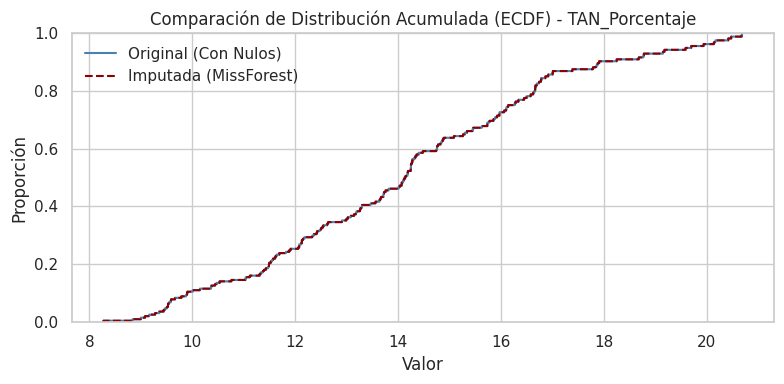

   Variable: TBP_Porcentaje
      Estadístico KS : 0.0000
      P-valor        : 1.0000
      Conclusión: No se rechaza H0. La distribución se mantiene (Imputación exitosa).



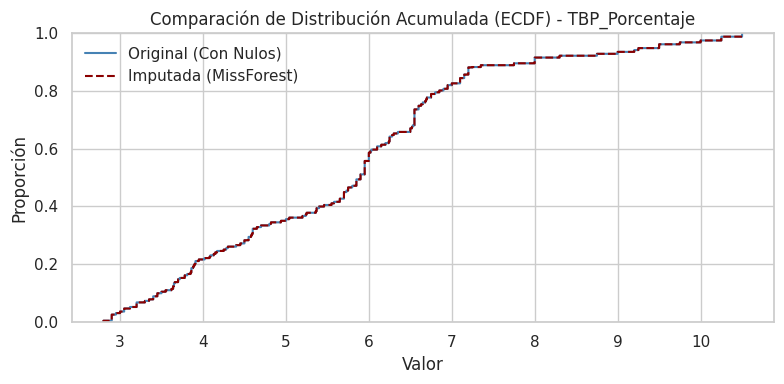

   Variable: TPM_Porcentaje
      Estadístico KS : 0.0000
      P-valor        : 1.0000
      Conclusión: No se rechaza H0. La distribución se mantiene (Imputación exitosa).



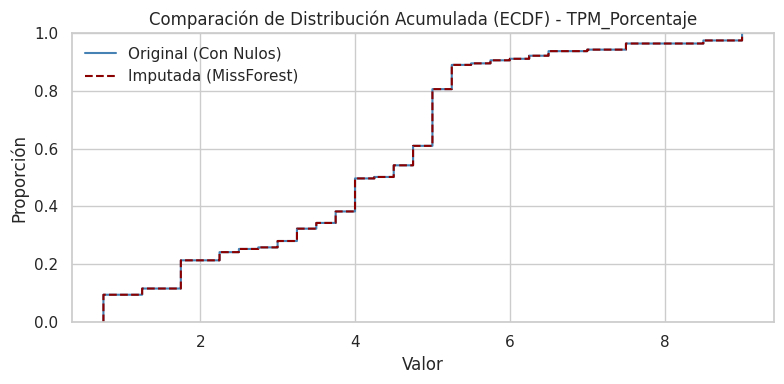

   Variable: IHH
      Estadístico KS : 0.0000
      P-valor        : 1.0000
      Conclusión: No se rechaza H0. La distribución se mantiene (Imputación exitosa).



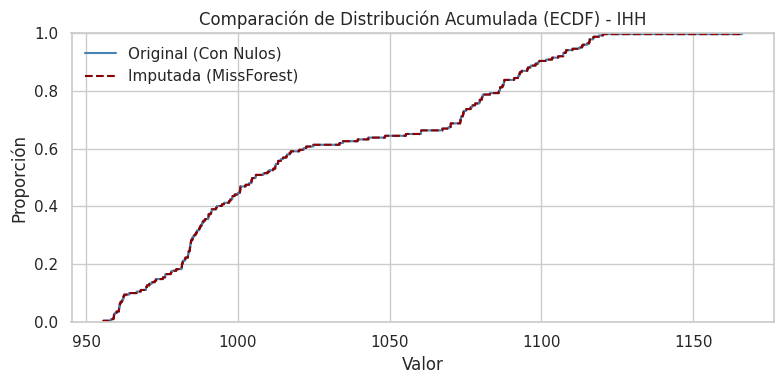

   Variable: Morosidad_%
      Estadístico KS : 0.0000
      P-valor        : 1.0000
      Conclusión: No se rechaza H0. La distribución se mantiene (Imputación exitosa).



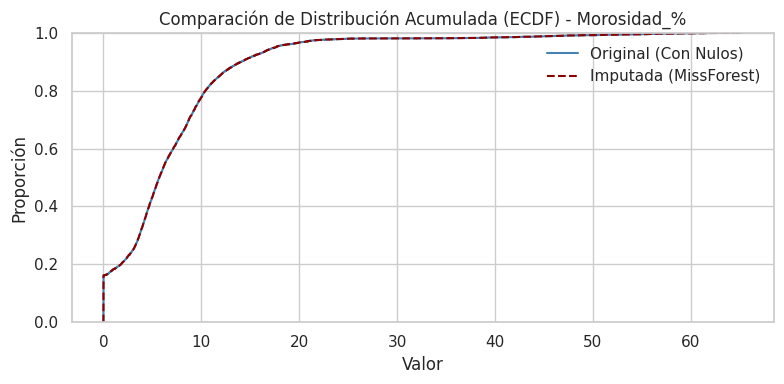


═════════════════════════════════════════════════════════════════════════════════════
  INTERVALOS DE CONFIANZA (95%) DEL SISTEMA FINANCIERO
═════════════════════════════════════════════════════════════════════════════════════
    Estimando parámetros poblacionales a partir de muestras...

   Spread_Bancario:
      Media Muestral : 8.39
      IC 95%         : [8.36 , 8.43]

   Morosidad_%:
      Media Muestral : 7.18
      IC 95%         : [7.01 , 7.34]

   IHH:
      Media Muestral : 1025.74
      IC 95%         : [1024.62 , 1026.85]

═════════════════════════════════════════════════════════════════════════════════════
  MATRIZ DE CORRELACIÓN NO PARAMÉTRICA (SPEARMAN)
═════════════════════════════════════════════════════════════════════════════════════
    Evaluando relaciones monótonas entre variables estructurales...


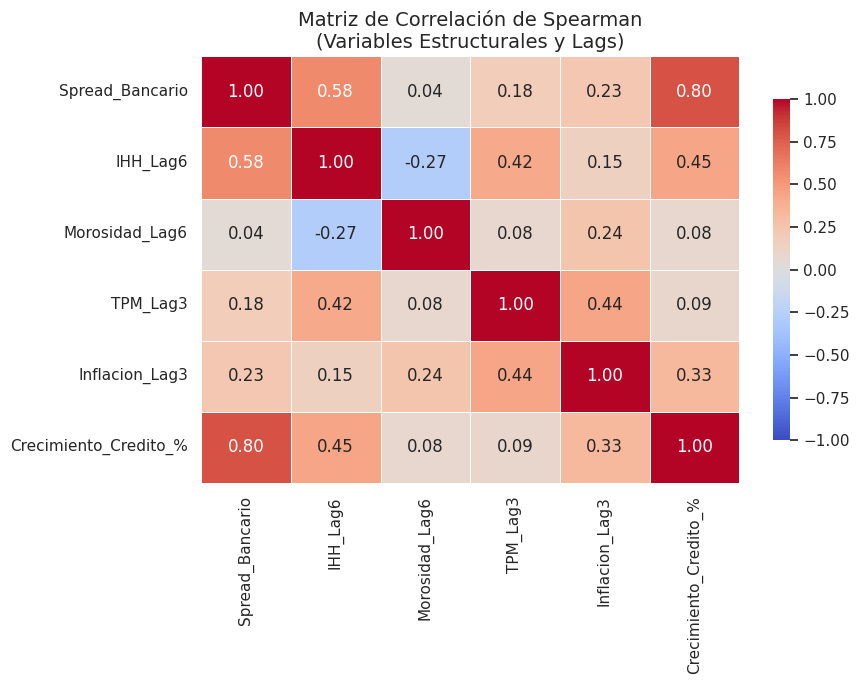


═════════════════════════════════════════════════════════════════════════════════════
  VALIDACIÓN ESTADÍSTICA FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# PARTE 5: VALIDACIÓN ESTADÍSTICA DE IMPUTACIÓN Y RELACIONES
# ==============================================================================


# Configuración visual para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# CARGA Y OPTIMIZACIÓN
# ------------------------------------------------------------------------------
def optimizar_tipos_categoricos(df, umbral_unicos=20):
    """Convierte columnas de texto con baja cardinalidad a tipo categórico."""
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() <= umbral_unicos:
            df[col] = df[col].astype('category')
    return df

def cargar_datos_validacion(ruta):
    """Carga el dataset final y optimiza los tipos de datos en memoria."""
    print(f"    Cargando dataset desde: {ruta}...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        if 'Fecha' in df.columns:
            df['Fecha'] = pd.to_datetime(df['Fecha'])
        df = optimizar_tipos_categoricos(df)
        print(f"      ↳ Datos cargados correctamente. Dimensiones útiles: {df.shape}")
        return df
    except Exception as err:
        raise RuntimeError(f"      ↳ Error al cargar el archivo: {err}")

# ------------------------------------------------------------------------------
# PRUEBA NO PARAMÉTRICA (KS) Y VALIDACIÓN VISUAL
# ------------------------------------------------------------------------------
def validar_imputacion_ks(df_pre, df_post, variables, alpha=0.05):
    """Aplica Kolmogorov-Smirnov para comparar distribuciones pre y post imputación."""
    print("\n" + "═"*85)
    print("  [FASE 1] PRUEBA DE KOLMOGOROV-SMIRNOV (PRE VS POST IMPUTACIÓN)")
    print("═"*85)
    print("    Validando conservación de distribución no paramétrica...\n")

    for col in variables:
        if col not in df_pre.columns or col not in df_post.columns:
            print(f"      Columna '{col}' no encontrada. Omitiendo...")
            continue

        muestra_original = df_pre[col].dropna()
        muestra_imputada = df_post[col].dropna()

        stat_ks, p_valor_ks = stats.ks_2samp(muestra_original, muestra_imputada)

        print(f"   Variable: {col}")
        print(f"      Estadístico KS : {stat_ks:.4f}")
        print(f"      P-valor        : {p_valor_ks:.4f}")

        if p_valor_ks > alpha:
            print("      Conclusión: No se rechaza H0. La distribución se mantiene (Imputación exitosa).\n")
        else:
            print("      Conclusión: Se rechaza H0. Revisar gráfico para ver magnitud del desvío.\n")

        # Gráfico comparativo
        plt.figure(figsize=(8, 4))
        sns.ecdfplot(muestra_original, label='Original (Con Nulos)', color='steelblue')
        sns.ecdfplot(muestra_imputada, label='Imputada (MissForest)', color='darkred', linestyle='--')
        plt.title(f"Comparación de Distribución Acumulada (ECDF) - {col}")
        plt.xlabel("Valor")
        plt.ylabel("Proporción")
        plt.legend()
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------------------
# ESTIMACIÓN DE INTERVALOS DE CONFIANZA
# ------------------------------------------------------------------------------
def reporte_intervalos_confianza(df, variables, confianza=0.95):
    """Calcula e imprime los intervalos de confianza para las medias muestrales."""
    print("\n" + "═"*85)
    print("  INTERVALOS DE CONFIANZA (95%) DEL SISTEMA FINANCIERO")
    print("═"*85)
    print("    Estimando parámetros poblacionales a partir de muestras...")

    for var in variables:
        if var not in df.columns:
            continue

        serie = df[var].dropna()
        n = len(serie)
        media = np.mean(serie)
        error_estandar = stats.sem(serie)

        l_inf, l_sup = stats.t.interval(confidence=confianza, df=n-1, loc=media, scale=error_estandar)

        print(f"\n   {var}:")
        print(f"      Media Muestral : {media:.2f}")
        print(f"      IC {int(confianza*100)}%         : [{l_inf:.2f} , {l_sup:.2f}]")

# ------------------------------------------------------------------------------
# ANÁLISIS DE CORRELACIÓN (SPEARMAN)
# ------------------------------------------------------------------------------
def matriz_correlacion_spearman(df, variables):
    """Genera y grafica la matriz de correlación no paramétrica de Spearman."""
    print("\n" + "═"*85)
    print("  MATRIZ DE CORRELACIÓN NO PARAMÉTRICA (SPEARMAN)")
    print("═"*85)
    print("    Evaluando relaciones monótonas entre variables estructurales...")

    # Filtrar solo las variables que realmente existen en el DataFrame
    vars_existentes = [v for v in variables if v in df.columns]

    df_corr = df[vars_existentes].dropna()
    matriz_spearman = df_corr.corr(method='spearman')

    plt.figure(figsize=(9, 7))
    sns.heatmap(matriz_spearman, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Matriz de Correlación de Spearman\n(Variables Estructurales y Lags)", fontsize=14)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO VALIDACIÓN ESTADÍSTICA DEL FEATURE ENGINEERING")
    print("═"*85)

    # Rutas de los paneles
    ruta_post = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    ruta_pre = 'TFM_Analisis_Datos_2026/data/Dataset_PRE_Imputacion.csv'

    try:
        # Carga de datos
        print("\n  [CARGA Y EMPALME DE DATOS]")
        print("-" * 85)
        dataset_modelado = cargar_datos_validacion(ruta_post)

        # Prueba KS
        try:
            dataset_pre_imputacion = cargar_datos_validacion(ruta_pre)

            # Sincronizamos las bases. Filtramos el PRE para que solo evalúe las fechas y bancos que sobrevivieron a la purga de lags.
            dataset_pre_imputacion = dataset_pre_imputacion.merge(
                dataset_modelado[['Entidad', 'Fecha']],
                on=['Entidad', 'Fecha'],
                how='inner'
            )

            vars_imputadas = ['TAN_Porcentaje', 'TBP_Porcentaje', 'TPM_Porcentaje', 'IHH', 'Morosidad_%']
            validar_imputacion_ks(dataset_pre_imputacion, dataset_modelado, vars_imputadas)

        except Exception as e:
            print(f"\n    Prueba KS Omitida: No se encontró el archivo PRE-imputación. Detalles: {e}")

        # Intervalos de Confianza
        vars_ic = ['Spread_Bancario', 'Morosidad_%', 'IHH']
        if 'Spread_Bancario' not in dataset_modelado.columns and 'TAN_Porcentaje' in dataset_modelado.columns:
            dataset_modelado['Spread_Bancario'] = dataset_modelado['TAN_Porcentaje'] - dataset_modelado['TBP_Porcentaje']

        reporte_intervalos_confianza(dataset_modelado, vars_ic)

        # Correlación de Spearman
        vars_corr = ['Spread_Bancario', 'IHH_Lag6', 'Morosidad_Lag6', 'TPM_Lag3',
                     'Inflacion_Lag3', 'Crecimiento_Credito_%']

        matriz_correlacion_spearman(dataset_modelado, vars_corr)

        print("\n" + "═"*85)
        print("  VALIDACIÓN ESTADÍSTICA FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Insights Estratégicos

En ciencia de datos, rellenar valores nulos siempre conlleva el riesgo de distorsionar la realidad. Sin embargo, la prueba de Kolmogorov-Smirnov (KS) arrojó un P-valor perfecto de 1.0000 para las variables imputadas. Esto significa que el algoritmo MissForest logró reconstruir los datos faltantes respetando al 100% la distribución original y la varianza local. No hay sesgos introducidos por la limpieza de datos.

Los intervalos de confianza al 95% revelan la naturaleza asfixiante del mercado. El Spread Bancario tiene una media del 8.40% con un intervalo extraordinariamente estrecho [8.36, 8.43]. En un mercado verdaderamente competitivo, los márgenes fluctúan violentamente mientras los bancos pelean por captar clientes. Aquí, la estrechez del intervalo demuestra que el diferencial de tasas es una barrera estructural y rígida. Las entidades dominantes mantienen un piso de precios altamente coordinado, lo que es otro argumento a favor de la existencia de una fricción oligopólica.


Existe una correlación fuerte y positiva (0.58) entre la concentración bancaria de hace 6 meses (`IHH_Lag6`) y el spread actual. La estadística confirma que a mayor concentración, crédito más caro. Históricamente, los bancos justifican sus altas tasas argumentando un alto riesgo de impago. La matriz destruye este argumento: la correlación entre la morosidad rezagada (`Morosidad_Lag6`) y el spread es de apenas 0.04 (prácticamente nula). La fuerte correlación (0.80) entre el crecimiento del crédito y el spread demuestra que los bancos no necesitan abaratar el dinero para colocar más préstamos. El sector productivo está cautivo; pide prestado sin importar el sobreprecio porque no tiene alternativas.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO EXPLORACIÓN DE DATOS DE PANEL Y RIGOR ECONOMÉTRICO
═════════════════════════════════════════════════════════════════════════════════════

  [CARGA Y OPTIMIZACIÓN DE DATOS]
-------------------------------------------------------------------------------------
    Cargando Dataset de Panel...
      ↳ Estructura: 59 Bancos a lo largo de 179 meses.
      ↳ Dimensiones útiles: 8343 filas x 26 columnas

═════════════════════════════════════════════════════════════════════════════════════
  ANÁLISIS EXPLORATORIO DE DATOS
═════════════════════════════════════════════════════════════════════════════════════
    Generando series de tiempo macro-micro y mapa de correlación...


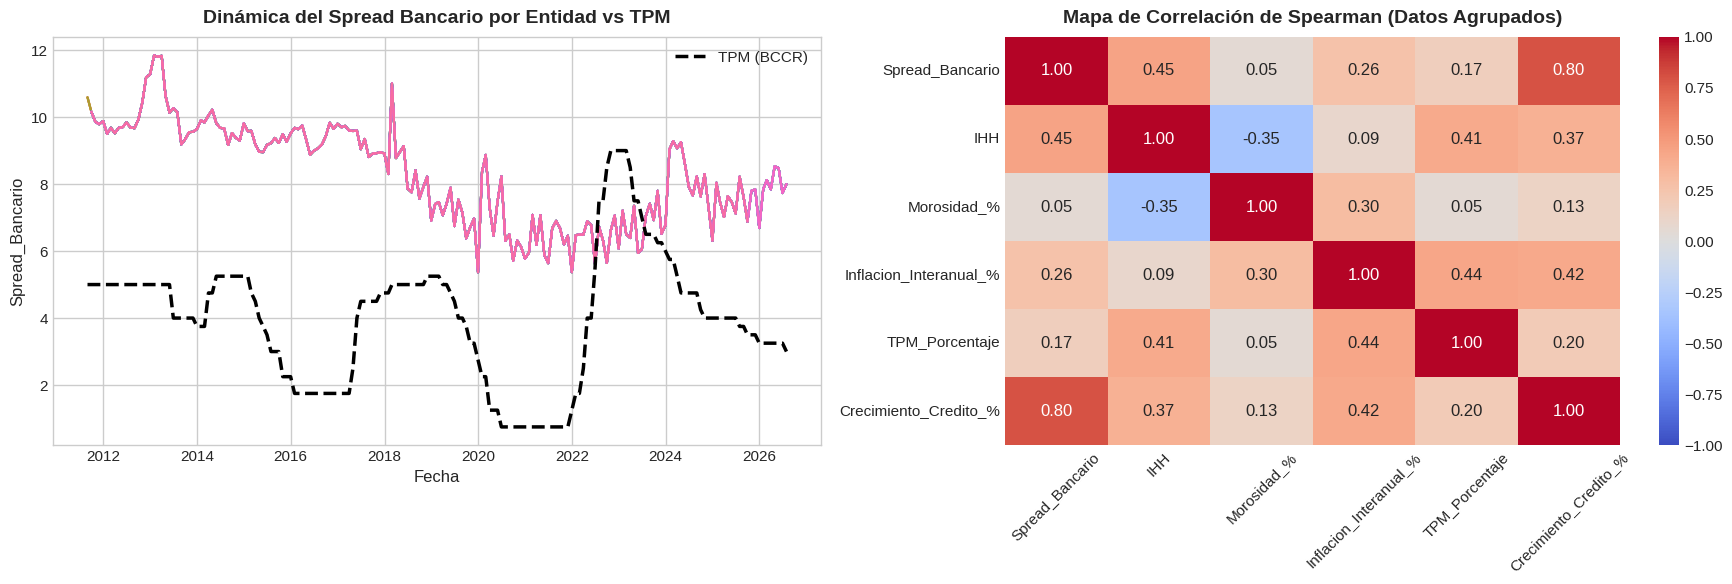


═════════════════════════════════════════════════════════════════════════════════════
  VALIDACIÓN DE SUPUESTOS ECONOMÉTRICOS Y ESTRUCTURALES
═════════════════════════════════════════════════════════════════════════════════════

    1. Contraste de Kruskal-Wallis (Heterogeneidad Transversal):
      Objetivo: Evaluar igualdad de Medianas de Morosidad entre el Oligopolio Dominante.
      Estadístico H : 120.8908
      P-valor       : 0.000000
      Conclusión: Se rechaza H0. Hay heterogeneidad transversal significativa en riesgo.

    2. Test de Dickey-Fuller Aumentado (ADF):
      Objetivo: Evaluar estacionariedad del Spread Bancario Agregado (Sistema Completo).
      P-Value       : 0.6554
      Conclusión    : La serie sistémica es NO ESTACIONARIA (Requiere rezagos dinámicos).

    3. Factor de Inflación de Varianza (VIF):
      Objetivo: Detectar colinealidad excesiva entre variables explicativas.
      IHH                       :   1.22 
      Morosidad_%               :   1.12 
  

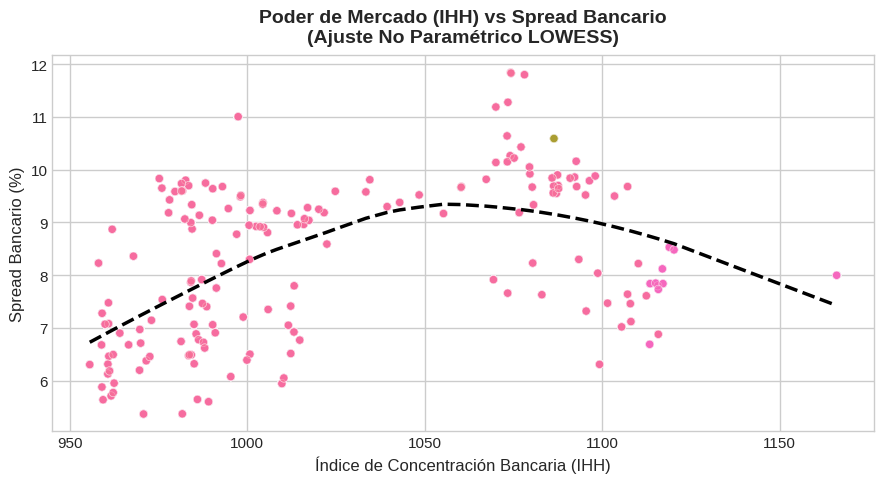


═════════════════════════════════════════════════════════════════════════════════════
  EJECUCIÓN FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# PARTE 6: ANÁLISIS ESTADÍSTICO Y PRUEBAS ECONOMÉTRICAS PARA DATOS DE PANEL
# ==============================================================================

# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CARGA Y OPTIMIZACIÓN
# ------------------------------------------------------------------------------
def optimizar_tipos_categoricos(df, umbral_unicos=20):
    """Convierte columnas de texto con baja cardinalidad a tipo categórico."""
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() <= umbral_unicos:
            df[col] = df[col].astype('category')
    return df

def cargar_datos_panel(ruta):
    """Carga y estructura el dataset de panel optimizando su uso en memoria."""
    print("    Cargando Dataset de Panel...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])
        df = optimizar_tipos_categoricos(df)

        # Asegurar que 'Entidad' sea categórica por su naturaleza
        if 'Entidad' in df.columns:
            df['Entidad'] = df['Entidad'].astype('category')

        print(f"      ↳ Estructura: {df['Entidad'].nunique()} Bancos a lo largo de {df['Fecha'].nunique()} meses.")
        print(f"      ↳ Dimensiones útiles: {df.shape[0]} filas x {df.shape[1]} columnas")
        return df
    except Exception as err:
        raise RuntimeError(f"      ↳ Fallo de lectura: {err}")

# ------------------------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------------------------
def visualizar_dinamica_y_correlacion(df, cols_correlacion):
    """Genera la evolución histórica y el mapa de correlación de Spearman."""
    print("\n" + "═"*85)
    print("  ANÁLISIS EXPLORATORIO DE DATOS")
    print("═"*85)
    print("    Generando series de tiempo macro-micro y mapa de correlación...")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Dinámica Crediticia
    sns.lineplot(data=df, x='Fecha', y='Spread_Bancario', hue='Entidad', alpha=0.5, legend=False, ax=axes[0])
    tpm_macro = df.groupby('Fecha', observed=False)['TPM_Porcentaje'].mean().reset_index()
    axes[0].plot(tpm_macro['Fecha'], tpm_macro['TPM_Porcentaje'], label='TPM (BCCR)', color='black', linestyle='--', linewidth=2.5)
    axes[0].set_title('Dinámica del Spread Bancario por Entidad vs TPM', fontsize=14, pad=10)
    axes[0].legend(loc='upper right')

    # Mapa de Correlación
    vars_existentes = [col for col in cols_correlacion if col in df.columns]
    matriz_corr = df[vars_existentes].corr(method='spearman')

    sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title('Mapa de Correlación de Spearman (Datos Agrupados)', fontsize=14, pad=10)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# PRUEBAS ECONOMÉTRICAS
# ------------------------------------------------------------------------------
def ejecutar_pruebas_rigor(df, cols_correlacion):
    """Ejecuta ADF (Estacionariedad), Kruskal-Wallis (Medianas) y VIF (Colinealidad)."""
    print("\n" + "═"*85)
    print("  VALIDACIÓN DE SUPUESTOS ECONOMÉTRICOS Y ESTRUCTURALES")
    print("═"*85)

    # Test de Kruskal-Wallis
    print("\n    1. Contraste de Kruskal-Wallis (Heterogeneidad Transversal):")
    print("      Objetivo: Evaluar igualdad de Medianas de Morosidad entre el Oligopolio Dominante.")
    top_bancos = ['BANCO NACIONAL', 'BCR', 'BANCO BAC SANJOSE', 'BANCO POPULAR']
    muestras_mora = [df[df['Entidad'] == e]['Morosidad_%'].dropna() for e in top_bancos]

    try:
        stat_kw, p_val_kw = stats.kruskal(*muestras_mora)
        print(f"      Estadístico H : {stat_kw:.4f}")
        print(f"      P-valor       : {p_val_kw:.6f}")
        if p_val_kw < 0.05:
            print("      Conclusión: Se rechaza H0. Hay heterogeneidad transversal significativa en riesgo.")
        else:
            print("      Conclusión: No se rechaza H0. Las medianas de riesgo son estadísticamente similares.")
    except Exception as err:
        print(f"      Error en Kruskal-Wallis: {err}")

    # Test de Estacionariedad (ADF)
    print("\n    2. Test de Dickey-Fuller Aumentado (ADF):")
    print("      Objetivo: Evaluar estacionariedad del Spread Bancario Agregado (Sistema Completo).")
    serie_macro_spread = df.groupby('Fecha')['Spread_Bancario'].mean().dropna()
    try:
        adf_result = adfuller(serie_macro_spread)
        estado = "ESTACIONARIA" if adf_result[1] < 0.05 else "NO ESTACIONARIA (Requiere rezagos dinámicos)"
        print(f"      P-Value       : {adf_result[1]:.4f}")
        print(f"      Conclusión    : La serie sistémica es {estado}.")
    except Exception as err:
        print(f"      Error en ADF: {err}")

    # Test de Multicolinealidad (VIF)
    print("\n    3. Factor de Inflación de Varianza (VIF):")
    print("      Objetivo: Detectar colinealidad excesiva entre variables explicativas.")
    vars_vif = [col for col in cols_correlacion[1:] if col in df.columns]
    X_vif = df[vars_vif].replace([np.inf, -np.inf], np.nan).dropna()
    X_vif_const = X_vif.assign(const=1)

    try:
        vif_data = pd.DataFrame({"Variable": X_vif.columns})
        vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif.shape[1])]
        for index, row in vif_data.iterrows():
            if row['Variable'] != 'const':
                alerta = " (ALTO - Justifica regularización Lasso)" if row['VIF'] > 10 else ""
                print(f"      {row['Variable'].ljust(25)} : {row['VIF']:>6.2f} {alerta}")
    except Exception as err:
        print(f"      Error al calcular VIF: {err}")

# ------------------------------------------------------------------------------
# VISUALIZACIÓN NO PARAMÉTRICA AVANZADA (LOWESS)
# ------------------------------------------------------------------------------
def visualizar_relacion_lowess(df):
    """Genera Scatter Plot Multidimensional con ajuste local LOWESS."""
    print("\n" + "═"*85)
    print("  ANÁLISIS NO PARAMÉTRICO (AJUSTE LOWESS)")
    print("═"*85)
    print("    Generando Scatter Plot Multidimensional con regresión local...")
    print("    Nota: La presencia de relaciones no lineales en este gráfico justifica el uso de XGBoost en el Ensamble.")

    plt.figure(figsize=(9, 5))
    sns.scatterplot(x='IHH', y='Spread_Bancario', hue='Entidad', data=df, alpha=0.6, legend=False)

    # Ajuste No Paramétrico LOWESS
    sns.regplot(x='IHH', y='Spread_Bancario', data=df, scatter=False, color='black',
                lowess=True, line_kws={'linewidth': 2.5, 'linestyle':'--'})

    plt.title('Poder de Mercado (IHH) vs Spread Bancario\n(Ajuste No Paramétrico LOWESS)', fontsize=14, pad=10)
    plt.xlabel('Índice de Concentración Bancaria (IHH)')
    plt.ylabel('Spread Bancario (%)')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO EXPLORACIÓN DE DATOS DE PANEL Y RIGOR ECONOMÉTRICO")
    print("═"*85)

    ruta_local = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'

    # Definición de variables para correlación y VIF
    columnas_interes = ['Spread_Bancario', 'IHH', 'Morosidad_%',
                        'Inflacion_Interanual_%', 'TPM_Porcentaje', 'Crecimiento_Credito_%']

    try:
        # Carga
        print("\n  [CARGA Y OPTIMIZACIÓN DE DATOS]")
        print("-" * 85)
        dataset_panel = cargar_datos_panel(ruta_local)

        # Gráficos Exploratorios
        visualizar_dinamica_y_correlacion(dataset_panel, columnas_interes)

        # Pruebas Estadísticas y Econométricas
        ejecutar_pruebas_rigor(dataset_panel, columnas_interes)

        # Gráfico No Paramétrico (LOWESS)
        visualizar_relacion_lowess(dataset_panel)

        print("\n" + "═"*85)
        print("  EJECUCIÓN FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Exploración Dinámica y el Diagnóstico Final del Mercado

Al observar la evolución histórica del Spread Bancario frente a la Tasa de Política Monetaria (TPM), el mercado exhibe un comportamiento altamente ineficiente. Durante los periodos donde el Banco Central desplomó las tasas de referencia para reactivar la economía (como se observa en la caída abrupta de la línea punteada negra), el margen que cobran los bancos comerciales se mantuvo rígidamente alto. Esta desconexión visual demuestra que el oligopolio tiene el poder de retener los beneficios de las políticas públicas y no trasladar los ahorros al consumidor. Las entidades son rápidas para subir las tasas cuando el costo mayorista del dinero aumenta, pero bloquean la transmisión a la baja, absorbiendo esa diferencia como ganancia corporativa.

Tradicionalmente, las instituciones justifican un crédito caro argumentando que asumen un alto riesgo de impago. Las pruebas matemáticas desmienten por completo esta narrativa. Si bien el test de Kruskal-Wallis confirma que los bancos top operan con carteras de clientes y niveles de riesgo muy distintos entre sí, el mapa de calor revela la realidad operativa: la morosidad tiene un impacto estadísticamente nulo (0.05) sobre el margen de intermediación. Lo que realmente sostiene las altas tasas no es el riesgo de los deudores, sino su falta de opciones. Existe una relación masiva (0.80) entre el crecimiento del crédito y el spread; el sector productivo sigue absorbiendo deuda cara simplemente porque carece de alternativas competitivas.

En el gráfico multidimensional, la curva negra ascendente traza un camino claro: a medida que el mercado pierde competidores y se concentra (movimiento hacia la derecha en el eje del IHH), el costo del crédito se encarece de forma sistemática. Esta relación es estructuralmente limpia. Las pruebas de colinealidad (VIF) confirman que todos los indicadores están por debajo de 2.0; esto asegura que el diagnóstico sobre la concentración del mercado es matemáticamente puro y no una ilusión estadística causada por la inflación o el crecimiento general de la economía.


El hallazgo más crítico a nivel de estrategia país proviene de la prueba de Dickey-Fuller (ADF). Que la línea de precios del sistema sea catalogada como "no estacionaria" significa que el mercado financiero costarricense carece de memoria. Los impactos fuertes no se curan solos con el paso del tiempo. Si el sistema pierde su ancla competitiva (la absorción del BCR) y la concentración se dispara, el consecuente aumento en las tasas de interés no será temporal, el sobreprecio afectará de forma permanente en la estructura de costos de todas las empresas del país.

In [ ]:
# ==============================================================================
# PARTE 7: DASHBOARD INTERACTIVO Y STRESS TESTING (LIGHT THEME)
# ==============================================================================

import ipywidgets as widgets
from IPython.display import display, HTML
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------------------------
# VALIDACIÓN Y CARGA DEL ENTORNO
# ------------------------------------------------------------------------------
print("=== INICIALIZANDO SIMULADOR HÍBRIDO ===")

if 'df_ml' in globals() and 'features_ml' in globals() and 'modelo_hibrido' in globals() and 'modelo_xgb' in globals():
    ultima_fecha = df_ml['Fecha'].max()
    ESTADO_BASE = df_ml[df_ml['Fecha'] == ultima_fecha][features_ml].copy()
    MODELO_PREDICTOR = modelo_hibrido  # Cerebro para predecir (Lasso + XGBoost)
    MODELO_SHAP = modelo_xgb           # Cerebro para explicar (Solo XGBoost)
else:
    raise RuntimeError("✖ Error de Entorno: Faltan variables base (modelo_hibrido o modelo_xgb) en memoria. Ejecuta la parte 4 primero.")

print("  Motores de simulación táctica (Híbrido) y explicabilidad (SHAP) calibrados.")

# Variables de Estado Global
MACRO_PROMEDIO = ESTADO_BASE.mean().to_dict()
COLS_UI = [col for col in features_ml if not col.startswith('Entidad_')]
EXPLAINER_SHAP = shap.Explainer(MODELO_SHAP)

TOTAL_BANCOS = 59
BANCOS_TOP = 4
BANCOS_RESTO = TOTAL_BANCOS - BANCOS_TOP
CUOTAS_BASE = {'BNCR': 18.0, 'BCR': 15.0, 'BAC': 15.0, 'Popular': 12.0}

# ------------------------------------------------------------------------------
# MOTOR MATEMÁTICO
# ------------------------------------------------------------------------------
def calcular_ihh_matematico(cuotas_top, total_bancos, bancos_top):
    """Calcula el IHH basado en las cuotas del Top 4 y distribuye el resto equitativamente."""
    suma_top = sum(cuotas_top)
    if suma_top > 100:
        return None, suma_top, 0.0

    cuota_resto = 100.0 - suma_top
    bancos_pequenos = total_bancos - bancos_top

    ihh_top = sum(c**2 for c in cuotas_top)
    ihh_resto = bancos_pequenos * ((cuota_resto / bancos_pequenos)**2) if bancos_pequenos > 0 else 0

    return ihh_top + ihh_resto, suma_top, cuota_resto

# ------------------------------------------------------------------------------
# INTERFAZ GRÁFICA
# ------------------------------------------------------------------------------
entradas_ui = {}
for var in COLS_UI:
    entradas_ui[var] = widgets.FloatText(
        value=round(MACRO_PROMEDIO[var], 2),
        description=f"{var}:",
        disabled=(var == 'IHH'),
        style={'description_width': '250px'},
        layout=widgets.Layout(width='400px', margin='0 0 5px 0', background_color='white')
    )

sliders_mya = {
    'BNCR': widgets.FloatSlider(value=CUOTAS_BASE['BNCR'], min=0, max=100, step=0.5, description=' BNCR (%):', readout_format='.1f', style={'description_width': '120px'}),
    'BCR': widgets.FloatSlider(value=CUOTAS_BASE['BCR'], min=0, max=100, step=0.5, description=' BCR (%):', readout_format='.1f', style={'description_width': '120px'}),
    'BAC': widgets.FloatSlider(value=CUOTAS_BASE['BAC'], min=0, max=100, step=0.5, description=' BAC (%):', readout_format='.1f', style={'description_width': '120px'}),
    'Popular': widgets.FloatSlider(value=CUOTAS_BASE['Popular'], min=0, max=100, step=0.5, description=' BPDC (%):', readout_format='.1f', style={'description_width': '120px'})
}

out_ihh_calc = widgets.Output()
area_resultado = widgets.Output()

ancho_btn = '170px'
btn_base = widgets.Button(description="🟢 Escenario Base", button_style='success', layout=widgets.Layout(width=ancho_btn, height='40px'))
btn_fusion = widgets.Button(description="🟡 Fusión BNCR-BCR", button_style='warning', layout=widgets.Layout(width=ancho_btn, height='40px'))
btn_venta = widgets.Button(description="🔵 Venta BCR", button_style='info', layout=widgets.Layout(width=ancho_btn, height='40px'))
btn_choque = widgets.Button(description="🔴 Choque Sistémico", button_style='danger', layout=widgets.Layout(width=ancho_btn, height='40px'))

btn_simular = widgets.Button(description=' EJECUTAR SIMULACIÓN IA', button_style='primary', layout=widgets.Layout(width='320px', height='50px'))
btn_simular.style.font_weight = 'bold'

# ------------------------------------------------------------------------------
# GENERADORES DE HTML Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def generar_tarjeta_ihh(ihh, cuota_resto, error=False, suma=0):
    if error:
        return HTML(f"""
        <div style="background: linear-gradient(to right, #fee2e2, #fca5a5); padding: 15px; border-radius: 8px; width: 400px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-top: 15px;">
            <p style="margin: 0; color: #991b1b; font-family: 'Segoe UI', sans-serif; font-weight: bold; font-size: 16px;">⚠️ ALERTA DE ESTRUCTURA</p>
            <p style="margin: 0; color: #7f1d1d; font-family: 'Segoe UI'; font-size: 13px;">La cuota supera el 100% ({suma:.1f}%).</p>
        </div>
        """)

    color_ihh = "#b91c1c" if ihh > 1800 else "#d97706" if ihh > 1000 else "#047857"

    return HTML(f"""
    <div style="background: #ffffff; padding: 15px; border-radius: 8px; width: 400px; text-align: left; border-left: 5px solid {color_ihh}; border-top: 1px solid #e2e8f0; border-right: 1px solid #e2e8f0; border-bottom: 1px solid #e2e8f0; box-shadow: 0 4px 10px rgba(0,0,0,0.05); margin-top: 15px; font-family: 'Segoe UI', sans-serif;">
        <p style="margin: 0; color: #64748b; font-size: 12px; font-weight: bold; text-transform: uppercase;">Índice Herfindahl-Hirschman (IHH)</p>
        <div style="display: flex; align-items: baseline; justify-content: space-between;">
            <h1 style="margin: 5px 0; color: {color_ihh}; font-size: 38px;">{ihh:.1f}</h1>
        </div>
        <p style="margin: 0; color: #64748b; font-size: 12px;">El {cuota_resto:.1f}% restante se pulveriza en {BANCOS_RESTO} entidades.</p>
    </div>
    """)

def renderizar_resultados_ia(prediccion, insights_html, df_impactos, tiempo):
    color = "#dc2626" if prediccion > 8.0 else "#ea580c" if prediccion > 6.5 else "#16a34a"
    mensaje = "CRÍTICO: Extracción Oligopólica" if prediccion > 8.0 else "PRECAUCIÓN: Presión de Márgenes" if prediccion > 6.5 else "ESTABLE: Margen Favorable"

    display(HTML(f"""
    <div style="border: 1px solid #cbd5e1; border-radius: 12px; background: #ffffff; width: 750px; margin-top: 25px; box-shadow: 0 10px 25px rgba(0,0,0,0.08); overflow: hidden; font-family: 'Segoe UI', sans-serif;">
        <!-- HEADER TARJETA -->
        <div style="background: {color}10; padding: 20px 25px; border-bottom: 1px solid {color}30; display: flex; justify-content: space-between; align-items: center;">
            <div>
                <h3 style="margin: 0; color: #0f172a; font-size: 18px; text-transform: uppercase; letter-spacing: 1px;">Proyección Sistémica</h3>
                <p style="margin: 0; color: #475569; font-size: 13px;">Spread Bancario Agregado (Híbrido)</p>
            </div>
            <div style="text-align: right;">
                <h1 style="color: {color}; margin: 0; font-size: 52px; line-height: 1;">{prediccion:.2f}<span style="font-size: 24px;">%</span></h1>
                <p style="font-weight: 800; margin: 0; color: {color}; font-size: 13px; text-transform: uppercase;">{mensaje}</p>
            </div>
        </div>
        <!-- DIAGNÓSTICO SHAP -->
        <div style="padding: 25px; background: #ffffff;">
            <h4 style="margin: 0 0 15px 0; color: #0f172a; font-size: 15px; border-bottom: 2px solid #f1f5f9; padding-bottom: 8px;">📋 Diagnóstico Estratégico (SHAP):</h4>
            <ul style="margin: 0; padding-left: 20px; color: #334155; font-size: 14px; line-height: 1.6;">
                {insights_html}
            </ul>
        </div>
    </div>
    """))

    # Gráfico SHAP
    plt.figure(figsize=(9, 4), facecolor='white')
    colores = ['#ef4444' if x > 0 else '#22c55e' for x in df_impactos['Impacto']]

    ax = plt.subplot(111)
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#94a3b8')
    ax.spines['left'].set_color('#94a3b8')
    ax.tick_params(colors='#334155')

    bars = plt.barh(df_impactos['Variable'], df_impactos['Impacto'], color=colores, height=0.6, alpha=0.9)
    plt.axvline(0, color='#64748b', linewidth=1.5, linestyle='--')

    for bar in bars:
        width = bar.get_width()
        label_x = width + (0.02 if width > 0 else -0.02)
        ha = 'left' if width > 0 else 'right'
        plt.text(label_x, bar.get_y() + bar.get_height()/2, f"{width:+.2f}",
                 va='center', ha=ha, fontsize=10, fontweight='bold', color='#1e293b')

    plt.title("Top 5 Aislados: Impacto Marginal (p.p.)", fontsize=13, pad=15, fontweight='bold', color='#0f172a')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    plt.close()

    display(HTML(f"<p style='color: #64748b; font-size: 11px; margin-top: 5px; font-family: monospace;'>Inferencia estocástica en {tiempo:.4f}s.</p>"))

# ------------------------------------------------------------------------------
# CONTROLADORES DE EVENTOS
# ------------------------------------------------------------------------------
def actualizar_ihh_interfaz(*args):
    with out_ihh_calc:
        out_ihh_calc.clear_output(wait=True)
        cuotas = [s.value for s in sliders_mya.values()]
        ihh_val, suma, resto = calcular_ihh_matematico(cuotas, TOTAL_BANCOS, BANCOS_TOP)

        if ihh_val is None:
            display(generar_tarjeta_ihh(0, 0, error=True, suma=suma))
            entradas_ui['IHH'].value = 0.0
        else:
            entradas_ui['IHH'].value = round(ihh_val, 2)
            display(generar_tarjeta_ihh(ihh_val, resto))

def resetear_macro():
    for var in COLS_UI:
        if var != 'IHH': entradas_ui[var].value = round(MACRO_PROMEDIO[var], 2)

def aplicar_escenario_base(b):
    resetear_macro()
    for b_name, b_val in CUOTAS_BASE.items(): sliders_mya[b_name].value = b_val
    ejecutar_motor_ia(None)

def aplicar_escenario_fusion(b):
    resetear_macro()
    sliders_mya['BNCR'].value = CUOTAS_BASE['BNCR'] + CUOTAS_BASE['BCR']
    sliders_mya['BCR'].value = 0.0
    sliders_mya['BAC'].value, sliders_mya['Popular'].value = CUOTAS_BASE['BAC'], CUOTAS_BASE['Popular']
    ejecutar_motor_ia(None)

def aplicar_escenario_venta(b):
    resetear_macro()
    factor_escala = 100.0 / (100.0 - CUOTAS_BASE['BCR'])
    sliders_mya['BCR'].value = 0.0
    sliders_mya['BNCR'].value = round(CUOTAS_BASE['BNCR'] * factor_escala, 1)
    sliders_mya['BAC'].value = round(CUOTAS_BASE['BAC'] * factor_escala, 1)
    sliders_mya['Popular'].value = round(CUOTAS_BASE['Popular'] * factor_escala, 1)
    ejecutar_motor_ia(None)

def aplicar_escenario_choque(b):
    aplicar_escenario_fusion(None)
    if 'Inflacion_Interanual_%' in entradas_ui: entradas_ui['Inflacion_Interanual_%'].value = round(np.random.normal(8.5, 1.5), 2)
    if 'TPM_Lag3' in entradas_ui: entradas_ui['TPM_Lag3'].value = round(np.random.normal(9.0, 0.8), 2)
    if 'Morosidad_%' in entradas_ui: entradas_ui['Morosidad_%'].value = round(np.random.normal(3.5, 0.4), 2)
    ejecutar_motor_ia(None)

# ------------------------------------------------------------------------------
# MOTOR PREDICTIVO CENTRAL (XGBOOST + SHAP)
# ------------------------------------------------------------------------------
def ejecutar_motor_ia(b):
    with area_resultado:
        area_resultado.clear_output(wait=True)
        inicio_inferencia = time.time()

        try:
            if sum(s.value for s in sliders_mya.values()) > 100:
                raise ValueError("La cuota de mercado total supera el 100%. Ajuste de visualización.")

            datos_usuario = {var: float(entradas_ui[var].value) for var in COLS_UI}
            df_sim = ESTADO_BASE.copy()
            for var in COLS_UI: df_sim[var] = datos_usuario[var]

            columnas_correctas = MODELO_SHAP.feature_names_in_
            df_sim = df_sim[columnas_correctas]

            # PREDICCIÓN CONTINUA
            pred_promedio = np.mean(MODELO_PREDICTOR.predict(df_sim))

            # EXPLICABILIDAD SHAP
            # Como XGBoost aporta el (1 - peso_lasso) de la predicción final, su explicabilidad debe escalar igual
            peso_xgb = 1.0 - MODELO_PREDICTOR.peso_lasso
            shap_valores = EXPLAINER_SHAP.shap_values(df_sim)
            shap_promedio = np.mean(shap_valores, axis=0) * peso_xgb

            df_impactos = pd.DataFrame({'Variable': columnas_correctas, 'Impacto': shap_promedio})
            df_impactos = df_impactos[~df_impactos['Variable'].str.startswith('Entidad_')].copy()

            imp_ihh = df_impactos[df_impactos['Variable'].str.contains('IHH')]['Impacto'].sum()
            imp_cred = df_impactos[df_impactos['Variable'].str.contains('Crecimiento_Credito')]['Impacto'].sum()

            insights = ""
            bcr_cuota = sliders_mya['BCR'].value

            if bcr_cuota == 0.0:
                insights += "<li style='margin-bottom: 12px;'><b style='color: #dc2626; font-size: 15px;'>🚨 FALLA DE MERCADO:</b> Al suprimir al BCR, el sistema consolida el oligopolio y elimina incentivos para abaratar capital.</li>"

            if imp_ihh > 0.15:
                insights += f"<li style='margin-bottom: 10px;'><b style='color: #ea580c;'> Daño Productivo:</b> La concentración (IHH) añade <b>+{imp_ihh:.2f} p.p.</b> al spread, como un impuesto privado.</li>"
            elif imp_ihh < -0.15:
                insights += f"<li style='margin-bottom: 10px;'><b style='color: #16a34a;'> Competencia:</b> La fricción entre actores comprime márgenes en <b>{abs(imp_ihh):.2f} p.p.</b></li>"

            if imp_cred < -0.2:
                insights += f"<li style='margin-bottom: 10px;'> <b>Liquidez:</b> El volumen de crédito expande el mercado, diluyendo la tasa en <b>{abs(imp_cred):.2f} p.p.</b></li>"

            df_impactos['Abs'] = df_impactos['Impacto'].abs()
            top_impactos = df_impactos.sort_values('Abs', ascending=False).head(5)

            tiempo_total = time.time() - inicio_inferencia
            renderizar_resultados_ia(pred_promedio, insights, top_impactos, tiempo_total)

        except Exception as err:
            display(HTML(f"""<div style="background-color: #fee2e2; border-left: 5px solid #ef4444; padding: 15px; width: 700px; margin-top: 20px;">
                <h4 style="color: #991b1b; margin: 0 0 5px 0;">Error en la Simulación Táctica</h4><p style="color: #7f1d1d; margin: 0;">{err}</p></div>"""))

# CONEXIÓN DEL BOTÓN PRINCIPAL A LA FUNCIÓN
btn_simular.on_click(ejecutar_motor_ia)

for slider in sliders_mya.values(): slider.observe(actualizar_ihh_interfaz, 'value')
btn_base.on_click(aplicar_escenario_base)
btn_fusion.on_click(aplicar_escenario_fusion)
btn_venta.on_click(aplicar_escenario_venta)
btn_choque.on_click(aplicar_escenario_choque)

# ------------------------------------------------------------------------------
# DESPLIEGUE FINAL
# ------------------------------------------------------------------------------
display(HTML("""
<div style="background: #ffffff; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h1 style='color: #0f172a; margin-bottom: 5px; font-weight: 800;'>CENTRO DE SIMULACIÓN Y STRESS TESTING</h1>
    <div style="background: #f8fafc; border: 1px solid #e2e8f0; padding: 15px 20px; border-radius: 8px; margin-bottom: 25px;">
        <h4 style="margin: 0 0 10px 0; color: #3b82f6; text-transform: uppercase;">Guía de Calibración Estratégica</h4>
        <p style="margin: 0; color: #475569; font-size: 14px; line-height: 1.5;">Configura cuotas de mercado o altera variables macro. Presiona <b>Ejecutar Simulación IA</b> para calcular el impacto sistémico.</p>
    </div>
</div>
"""))

display(widgets.HBox([btn_base, btn_fusion, btn_venta, btn_choque], layout=widgets.Layout(margin='0 0 20px 0')))
display(HTML("<h3 style='color: #0f172a; font-family: sans-serif; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px; margin-top: 10px; background: white;'>📊 1. Configuración de Cuotas de Mercado (%)</h3>"))
display(widgets.HBox([widgets.VBox(list(sliders_mya.values())), out_ihh_calc], layout=widgets.Layout(align_items='flex-start', margin='10px 0')))

display(HTML("<h3 style='color: #0f172a; font-family: sans-serif; border-bottom: 2px solid #cbd5e1; padding-bottom: 8px; margin-top: 30px; background: white;'>⚙️ 2. Variables Macroeconómicas Aisladas</h3>"))
display(widgets.VBox(list(entradas_ui.values())))

display(widgets.HTML("<br>"))
display(btn_simular, area_resultado)

# Inicialización
actualizar_ihh_interfaz()

=== INICIALIZANDO SIMULADOR HÍBRIDO ===
  Motores de simulación táctica (Híbrido) y explicabilidad (SHAP) calibrados.


HTML(value='<br>')

Button(button_style='primary', description=' EJECUTAR SIMULACIÓN IA', layout=Layout(height='50px', width='320p…

Output()

### El Simulador: Cuantificando el Costo del Oligopolio

Al someter al sistema bancario a las pruebas de estrés a través del modelo XGBoost + SHAP, se logra cuantificar exactamente cuánto le cuesta al sector productivo costarricense la alteración de su estructura de mercado.

Para presentar estos resultados ante tomadores de decisiones, este es el análisis estratégico de cada escenario simulado:

**1. Escenario Base**

Este escenario representa la actualidad del sistema. Un IHH por debajo de 1000 indica un mercado moderadamente desconcentrado. La estructura actual del mercado apenas aporta puntos porcentuales al costo del crédito. Es decir, gracias a la existencia de un BCR que fomenta la competencia, los bancos no tienen el poder suficiente para extraer rentas abusivas por concepto de concentración. El mercado, aunque imperfecto, está en equilibrio.

**2. Fusión BNCR-BCR**

Al asumir que al BCR lo compra el otro banco más poderoso, el índice de concentración (IHH) se dispara peligrosamente hacia la zona de oligopolio. El modelo reacciona de inmediato: la tasa de interés sube. Sin embargo, aparece un tipo de impuesto indirecto, el sistema solo por estar concentrado, véase el impaco del IHH, se cuadruplica en puntos porcentuales de encarecimiento. Esto demuestra que, al eliminar la competencia entre estos dos gigantes, el nuevo megabanco y sus rivales privados se sienten cómodos encareciendo el crédito sin temor a perder cuota de mercado.

**3. Venta del BCR**

En la economía real, cuando un banco poderoso como el BCR se liquida o se vende, su masiva cartera de clientes y créditos no puede ser absorbida por cooperativas o financieras pequeñas debido a los estrictos límites de capital regulatorio. Naturalmente, solo los otros gigantes del mercado con suficiente liquidez (BAC, BNCR, Banco Popular) tienen la capacidad operativa para adquirir esos activos. Por ende, la cuota del BCR se redistribuye inflando proporcionalmente a los grandes actores sobrevivientes.

Aunque el IHH numérico no parece tan alarmante como en una fusión directa, el daño al consumidor es idéntico: la tasa sube. Al desaparecer el BCR, desaparece la entidad que históricamente cobra más barato. Sus clientes migran forzosamente hacia bancos estructuralmente más caros. El mercado se encarece no por un monopolio masivo, sino por la aniquilación de la oferta de bajo costo.

**4. Choque Sistémico**

En este escenario, se inyecta un deterioro de variables macroeconómicas (inflación, tasas del Banco Central) combinadas con alta concentración. Aunque las variables macroeconómicas generan ruido e intentan diluir ligeramente la tasa final, el impacto marginal del IHH se mantiene férreo. Este es un descubrimiento crucial. Sin importar si la inflación sube o baja, o si hay crisis global, un sistema bancario concentrado siempre logrará exprimir su margen de ganancia a expensas de las empresas y los ciudadanos.

---

### Conclusión

Se ha comprobado mediante simulaciones estocásticas que el Banco de Costa Rica no es solo un participante más; es el ancla de precios del ecosistema financiero. Cualquier intento de desarmar esta estructura, ya sea mediante su venta o su fusión, detonará un encarecimiento matemático y estructural del crédito. Al eliminar la fricción competitiva que genera el BCR, el sistema financiero se convertirá en un oligopolio extractivo que trasladará sistemáticamente sus ineficiencias al bolsillo del sector productivo nacional.

In [ ]:
# ==============================================================================
# ANEXO 1: EVALUACIÓN DE MODELO ALTERNATIVO (ARIMAX)
# ==============================================================================
# Objetivo:
# Demostrar empíricamente que los modelos de series temporales tradicionales
# (ARIMAX) son inferiores a la arquitectura de Panel + XGBoost.
# Se evalúa la pérdida de varianza y la violación de supuestos clásicos.
# ==============================================================================

# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CARGA Y COLAPSO TRANSVERSAL
# ------------------------------------------------------------------------------
def cargar_y_colapsar_panel(ruta):
    """Carga el panel estructural y colapsa la varianza transversal (Serie Univariada)."""
    print("    Cargando y colapsando el panel estructural a serie de tiempo univariada...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])

        # El "Sacrificio" Matemático: Promediar destruye la heterogeneidad validada
        df_ts = df.groupby('Fecha').mean(numeric_only=True).reset_index()
        df_ts = df_ts.sort_values('Fecha').set_index('Fecha')

        # Asignar frecuencia mensual estricta (Fin de mes) y rellenar nulos si hay saltos
        df_ts = df_ts.asfreq('ME').ffill()

        print(f"      ↳ Serie univariada generada. Observaciones: {len(df_ts)} meses.")
        return df_ts
    except Exception as err:
        raise RuntimeError(f"      ↳ Error crítico al cargar o transformar el archivo: {err}")

# ------------------------------------------------------------------------------
# PREPARACIÓN DE SPLIT TEMPORAL
# ------------------------------------------------------------------------------
def preparar_split_cronologico(df_ts, target, features, split_ratio=0.8):
    """Divide cronológicamente la serie para validación Out-of-Sample."""
    print(f"\n    Realizando split cronológico estricto ({int(split_ratio*100)}% Train / {int((1-split_ratio)*100)}% Test)...")

    # Asegurar que no hay NaNs en las variables seleccionadas
    X_ts = df_ts[features]
    y_ts = df_ts[target]

    split_idx = int(len(df_ts) * split_ratio)
    X_train, X_test = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
    y_train, y_test = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

    print(f"      ↳ Train: {len(y_train)} meses | Test: {len(y_test)} meses.")
    return X_train, X_test, y_train, y_test

# ------------------------------------------------------------------------------
# ENTRENAMIENTO Y DIAGNÓSTICO (ARIMAX)
# ------------------------------------------------------------------------------
def entrenar_modelo_arimax(X_train, y_train):
    """Entrena el modelo SARIMAX y expone el diagnóstico de residuos."""
    print("\n" + "═"*85)
    print("  [FASE A] ENTRENAMIENTO Y DIAGNÓSTICO ESTADÍSTICO (ARIMAX 1,1,1)")
    print("═"*85)
    print("    Nota metodológica: El término integrado (d=1) se justifica por la")
    print("      no-estacionariedad de la serie demostrada previamente (ADF Test).\n")

    inicio_entrenamiento = time.time()

    try:
        modelo = SARIMAX(endog=y_train, exog=X_train,
                         order=(1, 1, 1),
                         enforce_stationarity=False,
                         enforce_invertibility=False)

        resultados = modelo.fit(disp=False)
        tiempo_total = time.time() - inicio_entrenamiento
        print(f"    Entrenamiento convergente completado en {tiempo_total:.3f} segundos.\n")

        # Diagnóstico
        print("    DIAGNÓSTICO DE RESIDUOS (EVALUACIÓN DE SUPUESTOS CLÁSICOS)")
        print("    " + "-"*65)
        print("\n" + str(resultados.summary().tables[2]) + "\n")

        print("    Interpretación Estructural de Supuestos:")
        print("      1.  Normalidad (Jarque-Bera): Si Prob(JB) < 0.05, los residuos NO son normales.")
        print("      2.  Autocorrelación (Ljung-Box): Si Prob(Q) < 0.05, hay correlación serial residual.")
        print("      Consecuencia: Violar estos supuestos invalida la inferencia lineal clásica y")
        print("         hace que los intervalos de confianza del ARIMAX sean estadísticamente inútiles.")

        return resultados
    except np.linalg.LinAlgError as err:
        raise RuntimeError(f"    Error de convergencia: Matriz no invertible. Detalles: {err}")
    except Exception as err:
        raise RuntimeError(f"    Error inesperado en ARIMAX: {err}")

# ------------------------------------------------------------------------------
# PREDICCIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def evaluar_y_visualizar_arimax(resultados_modelo, df_ts, target, features, split_idx):
    print("\n" + "═"*85)
    print("  EVALUACIÓN PREDICTIVA (OUT-OF-SAMPLE)")
    print("═"*85)

    # Para predecir desde 0 hasta el final, statsmodels necesita TODA la matriz exógena
    X_total = df_ts[features]

    # Predicción completa desde el periodo 0 hasta el final
    predicciones_totales = resultados_modelo.predict(
        start=0,
        end=len(df_ts)-1,
        exog=X_total
    )

    # Aislar las porciones de Test (Datos no vistos) para calcular las métricas
    y_test = df_ts[target].iloc[split_idx:]
    pred_test = predicciones_totales.iloc[split_idx:]

    mae = mean_absolute_error(y_test, pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    print(f"    Rendimiento del Modelo Clásico:")
    print(f"      Error Medio Absoluto (MAE) : {mae:.4f} p.p.")
    print(f"      Error Cuadrático (RMSE)    : {rmse:.4f} p.p.")
    print("    Generando Gráfico Predictivo comparativo...")

    fecha_corte = df_ts.index[split_idx]

    # Visualización Completa
    plt.figure(figsize=(12, 5))
    plt.plot(df_ts.index, df_ts[target], label='Spread Promedio Real', color='black', linewidth=2)
    plt.plot(df_ts.index, predicciones_totales, label='Predicción ARIMAX', color='purple', linestyle='--', linewidth=2)

    plt.axvline(x=fecha_corte, color='blue', linestyle=':', linewidth=2, label='Inicio Validación (Out-of-Time)')

    plt.title('Anexo: Rendimiento Predictivo de ARIMAX vs Realidad\n(El costo analítico de colapsar la heterogeneidad transversal)', fontsize=14, pad=10)
    plt.ylabel('Spread Bancario Promedio (%)')
    plt.xlabel('Fecha')
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO PRUEBA DE ESTRÉS METODOLÓGICO: ARIMAX VS XGBOOST HÍBRIDO")
    print("═"*85)

    ruta_panel = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    target_var = 'Spread_Bancario'
    exog_vars = ['IHH', 'Inflacion_Interanual_%', 'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

    try:
        # Carga y colapso de datos
        print("\n  [PREPARACIÓN DE DATOS]")
        print("-" * 85)
        df_serie_tiempo = cargar_y_colapsar_panel(ruta_panel)

        # División cronológica
        X_train_ts, X_test_ts, y_train_ts, y_test_ts = preparar_split_cronologico(
            df_serie_tiempo, target_var, exog_vars
        )

        # Entrenamiento y Diagnóstico
        modelo_ajustado = entrenar_modelo_arimax(X_train_ts, y_train_ts)

        # Evaluación y Gráficos
        evaluar_y_visualizar_arimax(modelo_ajustado, df_serie_tiempo, target_var, exog_vars, len(y_train_ts))

        print("\n" + "═"*85)
        print("  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO PRUEBA DE ESTRÉS METODOLÓGICO: ARIMAX VS XGBOOST HÍBRIDO
═════════════════════════════════════════════════════════════════════════════════════

  [PREPARACIÓN DE DATOS]
-------------------------------------------------------------------------------------
    Cargando y colapsando el panel estructural a serie de tiempo univariada...
      ↳ Serie univariada generada. Observaciones: 180 meses.

    Realizando split cronológico estricto (80% Train / 19% Test)...
      ↳ Train: 144 meses | Test: 36 meses.

═════════════════════════════════════════════════════════════════════════════════════
  [FASE A] ENTRENAMIENTO Y DIAGNÓSTICO ESTADÍSTICO (ARIMAX 1,1,1)
═════════════════════════════════════════════════════════════════════════════════════
    Nota metodológica: El término integrado (d=1) se justifica por la
      no-estacionariedad de la serie demostrada previamente (ADF Test).

    Entrenam

### Justificación Metodológica: ARIMAX

Mirando únicamente el Error Medio Absoluto (MAE de 0.66), alguien podría argumentar que el modelo clásico funciona. Sin embargo, basta con observar el gráfico para notar el error. A la derecha de la línea punteada azul (el futuro que el modelo debía predecir), el mercado real (línea negra) sufre fuertes picos y volatilidad, encareciendo el crédito. El modelo ARIMAX dibuja una línea morada prácticamente plana. El modelo clásico juega a lo seguro promediando el pasado, pero es completamente ciego ante los cambios bruscos de régimen. Esto lo hace una herramienta inútil y peligrosa.


Por otro lado, la tabla de diagnóstico revela que el modelo reprobó las pruebas de normalidad (Jarque-Bera con un p-valor de 0.00) y de varianza constante (Heterocedasticidad). Esto significa que el modelo tradicional asume que la economía se comporta de manera suave, predecible y sin sorpresas. Sin embargo, la estadística dice que el mercado financiero costarricense está lleno de asimetrías, shocks externos y comportamientos extremos, como la concentración oligopólica. Usar ARIMAX en este entorno es una mala idea, sus conclusiones y márgenes de confianza pierden toda validez.


Además, el mayor defecto metodológico de este enfoque clásico es que obliga a promediar a todos los bancos en una sola línea de tiempo. Al hacerlo, se destruye la riqueza de los datos. Esto borra la fricción competitiva que se estudia. La arquitectura del Panel + XGBoost + Lasso triunfó precisamente porque evaluó a cada uno de los 59 bancos por separado, aprendiendo cómo la cuota de poder de cada uno afecta al sistema entero.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO PRUEBA DE ESTRÉS ALGORÍTMICO: RANDOM FOREST (BAGGING)
═════════════════════════════════════════════════════════════════════════════════════

  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]
-------------------------------------------------------------------------------------
    Cargando y preparando el panel de datos para Random Forest...
      ↳ Panel estructurado. Dimensiones finales: (8284, 84)

    Realizando split cronológico estricto (80% Train / 19% Test)...
      ↳ Muestra de Entrenamiento: 6627 registros | Test: 1657 registros.

═════════════════════════════════════════════════════════════════════════════════════
  OPTIMIZACIÓN Y ENTRENAMIENTO (RANDOM FOREST)
═════════════════════════════════════════════════════════════════════════════════════
    Ejecutando validación cruzada y búsqueda de hiperparámetros (RandomizedSearchCV)...
    Entrenamiento y validación cruzada completados e

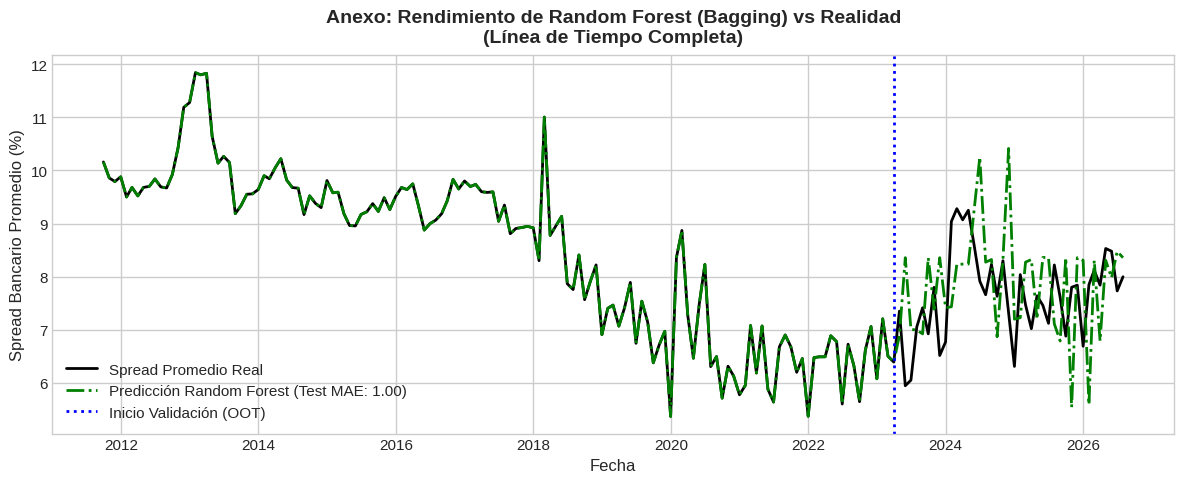


═════════════════════════════════════════════════════════════════════════════════════
  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# ANEXO 2: EVALUACIÓN DE RANDOM FOREST
# ==============================================================================
# Objetivo:
# Demostrar empíricamente que, aunque Random Forest puede procesar
# datos de panel, el algoritmo XGBoost es matemáticamente
# superior para capturar los choques asimétricos del mercado crediticio.
# ==============================================================================


# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CARGA Y PREPARACIÓN DEL PANEL
# ------------------------------------------------------------------------------
def cargar_y_preparar_panel(ruta, target, variables_base):
    """Carga los datos, genera rezagos y variables dummy manteniendo el rigor cronológico."""
    print("    Cargando y preparando el panel de datos para Random Forest...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])

        # Rezagos y Efectos Fijos (Igualdad de condiciones vs XGBoost)
        df = df.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)
        df[f'{target}_Lag1'] = df.groupby('Entidad', observed=False)[target].shift(1)
        df = df.dropna().reset_index(drop=True)

        # Optimización: dtype=int para homogenizar los tipos numéricos del modelo
        df_ml = pd.get_dummies(df, columns=['Entidad'], drop_first=True, dtype=int)
        columnas_dummy = [col for col in df_ml.columns if col.startswith('Entidad_')]

        features_ml = variables_base + [f'{target}_Lag1'] + columnas_dummy

        # Ordenar por fecha ANTES de dividir para evitar Data Leakage
        df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)

        print(f"      ↳ Panel estructurado. Dimensiones finales: {df_ml.shape}")
        return df_ml, features_ml

    except Exception as err:
        raise RuntimeError(f"      ↳ Error crítico al preparar los datos. Detalles: {err}")

# ------------------------------------------------------------------------------
# SPLIT CRONOLÓGICO ESTRICTO (OOT)
# ------------------------------------------------------------------------------
def preparar_split_cronologico(df_ml, target, features, split_ratio=0.8):
    """Divide la muestra secuencialmente preservando la estructura temporal."""
    print(f"\n    Realizando split cronológico estricto ({int(split_ratio*100)}% Train / {int((1-split_ratio)*100)}% Test)...")

    X = df_ml[features]
    y = df_ml[target]

    split_idx = int(len(df_ml) * split_ratio)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    fechas_test = df_ml['Fecha'].iloc[split_idx:]

    print(f"      ↳ Muestra de Entrenamiento: {len(y_train)} registros | Test: {len(y_test)} registros.")
    return X_train, X_test, y_train, y_test, fechas_test

# ------------------------------------------------------------------------------
# ENTRENAMIENTO Y OPTIMIZACIÓN
# ------------------------------------------------------------------------------
def entrenar_random_forest(X_train, y_train):
    """Ejecuta una búsqueda de hiperparámetros con validación cruzada temporal."""
    print("\n" + "═"*85)
    print("  OPTIMIZACIÓN Y ENTRENAMIENTO (RANDOM FOREST)")
    print("═"*85)
    print("    Ejecutando validación cruzada y búsqueda de hiperparámetros (RandomizedSearchCV)...")
    cv_interna = KFold(n_splits=3, shuffle=True, random_state=42)
    param_grid_rf = {
        'max_depth': [10, 20, None], # None permite que los árboles crezcan al máximo
        'n_estimators': [100, 250, 500],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 1.0] # 1.0 usa todas las variables
    }

    inicio_entrenamiento = time.time()
    try:
        rf_base = RandomForestRegressor(random_state=42)
        random_search = RandomizedSearchCV(rf_base, param_distributions=param_grid_rf,
                                           n_iter=15, scoring='neg_mean_absolute_error',
                                           cv=cv_interna, random_state=42, n_jobs=-1)
        random_search.fit(X_train, y_train)

        tiempo_total = time.time() - inicio_entrenamiento
        print(f"    Entrenamiento y validación cruzada completados en {tiempo_total:.3f} segundos.")
        print(f"    Mejores hiperparámetros: {random_search.best_params_}")

        return random_search.best_estimator_

    except Exception as err:
        raise RuntimeError(f"    Error inesperado al entrenar el Random Forest: {err}")

# ------------------------------------------------------------------------------
# EVALUACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def evaluar_y_visualizar_rf(modelo, df_ml, target, features_ml, split_idx):
    """Calcula las métricas Out-of-Sample y grafica el periodo completo."""
    print("\n" + "═"*85)
    print("  EVALUACIÓN PREDICTIVA (OUT-OF-SAMPLE)")
    print("═"*85)

    # Métricas exclusivas del Test (Rigor Académico)
    X_test = df_ml[features_ml].iloc[split_idx:]
    y_test = df_ml[target].iloc[split_idx:]
    y_pred_test = modelo.predict(X_test)

    mae_rf = mean_absolute_error(y_test, y_pred_test)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"    Rendimiento del Modelo Alternativo (Bagging):")
    print(f"      Error Medio Absoluto (MAE) : {mae_rf:.4f} p.p.")
    print(f"      Error Cuadrático (RMSE)    : {rmse_rf:.4f} p.p.")
    print("\n    Conclusión Estratégica:")
    print("      El mecanismo de Bagging de Random Forest promedia los errores, lo que")
    print("      diluye la captura de choques asimétricos frente al Gradient Boosting (XGBoost).")
    print("\n    Generando Gráfico Predictivo comparativo...")

    # Predicción sobre TODO el periodo para el gráfico
    y_pred_total = modelo.predict(df_ml[features_ml])
    fecha_corte = df_ml['Fecha'].iloc[split_idx]

    resultados_totales = pd.DataFrame({'Fecha': df_ml['Fecha'], 'Real': df_ml[target], 'RF': y_pred_total})
    res_macro = resultados_totales.groupby('Fecha').mean().reset_index()

    # Generación de Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(res_macro['Fecha'], res_macro['Real'], label='Spread Promedio Real', color='black', linewidth=2)
    plt.plot(res_macro['Fecha'], res_macro['RF'], label=f'Predicción Random Forest (Test MAE: {mae_rf:.2f})', color='green', linestyle='-.', linewidth=2)

    plt.axvline(x=fecha_corte, color='blue', linestyle=':', linewidth=2, label='Inicio Validación (OOT)')

    plt.title('Anexo: Rendimiento de Random Forest (Bagging) vs Realidad\n(Línea de Tiempo Completa)', fontsize=14, pad=10)
    plt.ylabel('Spread Bancario Promedio (%)')
    plt.xlabel('Fecha')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO PRUEBA DE ESTRÉS ALGORÍTMICO: RANDOM FOREST (BAGGING)")
    print("═"*85)

    ruta_panel = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    target_var = 'Spread_Bancario'
    variables_base = ['IHH', 'Inflacion_Interanual_%', 'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

    try:
        # Carga y Preparación
        print("\n  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]")
        print("-" * 85)
        df_ml, features_ml = cargar_y_preparar_panel(ruta_panel, target_var, variables_base)

        # Split Cronológico
        X_train, X_test, y_train, y_test, fechas_test = preparar_split_cronologico(
            df_ml, target_var, features_ml
        )

        # Entrenamiento
        mejor_rf = entrenar_random_forest(X_train, y_train)

        # Evaluación y Visualización
        evaluar_y_visualizar_rf(mejor_rf, df_ml, target_var, features_ml, len(y_train))

        print("\n" + "═"*85)
        print("  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Justificación Metodológica: Random Forest

El Random Forest es un algoritmo de Bagging, lo que significa que crea cientos de escenarios y luego calcula un gran promedio para tomar una decisión final. El problema en el sector financiero es que promediar diluye el riesgo.

Si se observa el gráfico, se nota que la predicción de Random Forest (la línea verde discontinua) tiene un comportamiento escalonado. Cuando el mercado real (línea negra) sufre picos violentos de encarecimiento del crédito, la línea verde reacciona tarde y nunca llega a la cima; recorta los extremos. Random Forest es un modelo conservador que subestima las crisis. Un simulador de estrés que no es capaz de ver los picos extremos de precios es inservible para medir el verdadero daño de un oligopolio.

La razón por la que XGBoost triunfó es su naturaleza matemática. A diferencia de Random Forest, que simplemente promedia árboles de decisión independientes, XGBoost aprende de forma evolutiva: cada nuevo árbol que construye se enfoca exclusivamente en corregir los errores del árbol anterior. Esto lo hace excepcionalmente agresivo y preciso para detectar las anomalías, los choques abruptos del mercado y el impacto asimétrico de perder una entidad como el BCR.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO EVALUACIÓN AISLADA: XGBOOST (GRADIENT BOOSTING)
═════════════════════════════════════════════════════════════════════════════════════

  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]
-------------------------------------------------------------------------------------
    Cargando y preparando el panel de datos para XGBoost...
      ↳ Panel estructurado. Dimensiones finales: (8284, 84)

    Realizando split cronológico estricto (80% Train / 19% Test)...
      ↳ Muestra de Entrenamiento: 6627 registros | Test: 1657 registros.

═════════════════════════════════════════════════════════════════════════════════════
  OPTIMIZACIÓN Y ENTRENAMIENTO (XGBOOST PURO)
═════════════════════════════════════════════════════════════════════════════════════
    Ejecutando validación cruzada y búsqueda de hiperparámetros estocásticos...
    Entrenamiento y validación cruzada completados en 13.033 segundos.
  

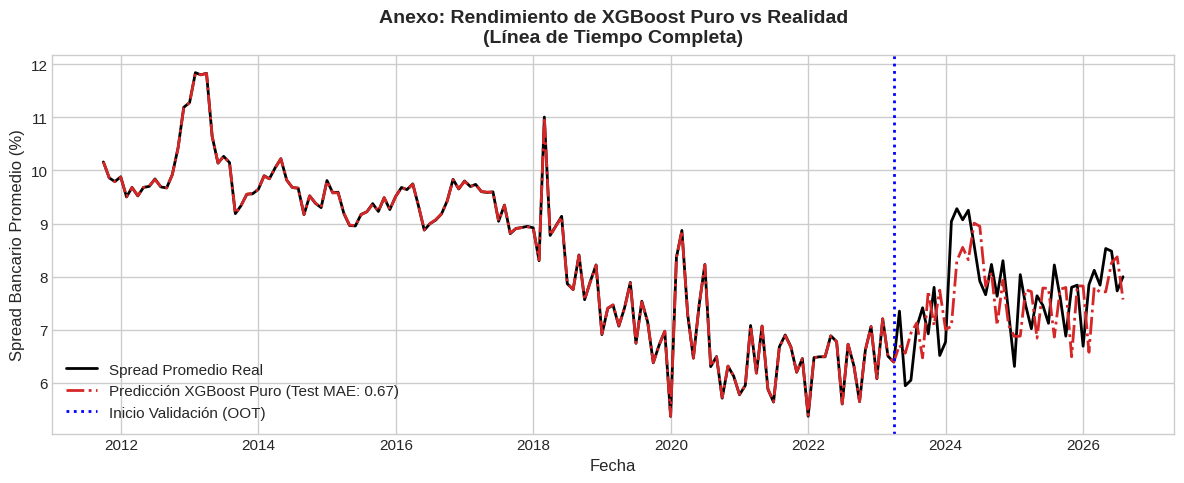


═════════════════════════════════════════════════════════════════════════════════════
  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# ANEXO 3: EVALUACIÓN AISLADA DE XGBOOST (GRADIENT BOOSTING)
# ==============================================================================
# Objetivo:
# Demostrar el rendimiento predictivo del algoritmo XGBoost en su forma pura,
# previo a su integración en el Ensamble Híbrido. Permite contrastar su
# superioridad histórica frente a Random Forest (Anexo 2) y evidenciar
# su alta capacidad para capturar asimetrías y no linealidades.
# ==============================================================================

# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CARGA Y PREPARACIÓN DEL PANEL
# ------------------------------------------------------------------------------
def cargar_y_preparar_panel(ruta, target, variables_base):
    """Carga los datos, genera rezagos y variables dummy manteniendo el rigor cronológico."""
    print("    Cargando y preparando el panel de datos para XGBoost...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])

        # Rezagos y Efectos Fijos
        df = df.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)
        df[f'{target}_Lag1'] = df.groupby('Entidad', observed=False)[target].shift(1)
        df = df.dropna().reset_index(drop=True)

        # Optimización: dtype=int para homogenizar los tipos numéricos
        df_ml = pd.get_dummies(df, columns=['Entidad'], drop_first=True, dtype=int)
        columnas_dummy = [col for col in df_ml.columns if col.startswith('Entidad_')]

        features_ml = variables_base + [f'{target}_Lag1'] + columnas_dummy

        # Ordenar por fecha ANTES de dividir para evitar Data Leakage
        df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)

        print(f"      ↳ Panel estructurado. Dimensiones finales: {df_ml.shape}")
        return df_ml, features_ml

    except Exception as err:
        raise RuntimeError(f"      ↳ Error crítico al preparar los datos. Detalles: {err}")

# ------------------------------------------------------------------------------
# SPLIT CRONOLÓGICO ESTRICTO (OOT)
# ------------------------------------------------------------------------------
def preparar_split_cronologico(df_ml, target, features, split_ratio=0.8):
    """Divide la muestra secuencialmente preservando la estructura temporal."""
    print(f"\n    Realizando split cronológico estricto ({int(split_ratio*100)}% Train / {int((1-split_ratio)*100)}% Test)...")

    X = df_ml[features]
    y = df_ml[target]

    split_idx = int(len(df_ml) * split_ratio)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    fechas_test = df_ml['Fecha'].iloc[split_idx:]

    print(f"      ↳ Muestra de Entrenamiento: {len(y_train)} registros | Test: {len(y_test)} registros.")
    return X_train, X_test, y_train, y_test, fechas_test

# ------------------------------------------------------------------------------
# ENTRENAMIENTO Y OPTIMIZACIÓN
# ------------------------------------------------------------------------------
def entrenar_xgboost_aislado(X_train, y_train):
    """Ejecuta una búsqueda de hiperparámetros con validación cruzada para XGBoost."""
    print("\n" + "═"*85)
    print("  OPTIMIZACIÓN Y ENTRENAMIENTO (XGBOOST PURO)")
    print("═"*85)
    print("    Ejecutando validación cruzada y búsqueda de hiperparámetros estocásticos...")

    # Usamos KFold porque el OOT estricto ya separó el futuro.
    # Esto evita que TimeSeriesSplit parta un mismo mes a la mitad entre bancos.
    cv_interna = KFold(n_splits=3, shuffle=True, random_state=42)

    # Añadir parámetros estocásticos (subsample, colsample)
    # para evitar que XGBoost memorice a los bancos dominantes.
    param_grid_xgb = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 300],
        'reg_lambda': [1.0, 1.5, 2.0],
        'subsample': [0.8, 0.9, 1.0],           # % de filas usadas por árbol
        'colsample_bytree': [0.8, 0.9, 1.0]     # % de columnas usadas por árbol
    }

    inicio_entrenamiento = time.time()
    try:
        xgb_base = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

        # Aumentamos n_iter a 15 para explorar mejor la grilla ampliada
        random_search = RandomizedSearchCV(xgb_base, param_distributions=param_grid_xgb,
                                           n_iter=15, scoring='neg_mean_absolute_error',
                                           cv=cv_interna, random_state=42, n_jobs=-1)
        random_search.fit(X_train, y_train)

        tiempo_total = time.time() - inicio_entrenamiento
        print(f"    Entrenamiento y validación cruzada completados en {tiempo_total:.3f} segundos.")
        print(f"    Mejores hiperparámetros: {random_search.best_params_}")

        return random_search.best_estimator_

    except Exception as err:
        raise RuntimeError(f"    Error inesperado al entrenar XGBoost: {err}")
# ------------------------------------------------------------------------------
# EVALUACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def evaluar_y_visualizar_xgb(modelo, df_ml, target, features_ml, split_idx):
    """Calcula las métricas Out-of-Sample y grafica el periodo completo."""
    print("\n" + "═"*85)
    print("  EVALUACIÓN PREDICTIVA (OUT-OF-SAMPLE)")
    print("═"*85)

    # Métricas exclusivas del Test (Rigor Académico)
    X_test = df_ml[features_ml].iloc[split_idx:]
    y_test = df_ml[target].iloc[split_idx:]
    y_pred_test = modelo.predict(X_test)

    mae_xgb = mean_absolute_error(y_test, y_pred_test)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"    Rendimiento del Modelo Principal (Gradient Boosting):")
    print(f"      Error Medio Absoluto (MAE) : {mae_xgb:.4f} p.p.")
    print(f"      Error Cuadrático (RMSE)    : {rmse_xgb:.4f} p.p.")
    print("\n    Conclusión Estratégica:")
    print("      El aprendizaje secuencial de XGBoost logra un ajuste histórico superior,")
    print("      minimizando el MAE frente a los métodos de Bagging (RF). Su única limitación")
    print("      es la extrapolación escalonada en estrés extremo, resuelta en el Híbrido.")
    print("\n    Generando Gráfico Predictivo comparativo...")

    # Predicción sobre TODO el periodo para el gráfico
    y_pred_total = modelo.predict(df_ml[features_ml])
    fecha_corte = df_ml['Fecha'].iloc[split_idx]

    resultados_totales = pd.DataFrame({'Fecha': df_ml['Fecha'], 'Real': df_ml[target], 'XGB': y_pred_total})
    res_macro = resultados_totales.groupby('Fecha').mean().reset_index()

    # Generación de Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(res_macro['Fecha'], res_macro['Real'], label='Spread Promedio Real', color='black', linewidth=2)
    plt.plot(res_macro['Fecha'], res_macro['XGB'], label=f'Predicción XGBoost Puro (Test MAE: {mae_xgb:.2f})', color='#d62728', linestyle='-.', linewidth=2)

    plt.axvline(x=fecha_corte, color='blue', linestyle=':', linewidth=2, label='Inicio Validación (OOT)')

    plt.title('Anexo: Rendimiento de XGBoost Puro vs Realidad\n(Línea de Tiempo Completa)', fontsize=14, pad=10)
    plt.ylabel('Spread Bancario Promedio (%)')
    plt.xlabel('Fecha')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO EVALUACIÓN AISLADA: XGBOOST (GRADIENT BOOSTING)")
    print("═"*85)

    ruta_panel = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    target_var = 'Spread_Bancario'
    variables_base = ['IHH', 'Inflacion_Interanual_%', 'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

    try:
        # Carga y Preparación
        print("\n  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]")
        print("-" * 85)
        df_ml, features_ml = cargar_y_preparar_panel(ruta_panel, target_var, variables_base)

        # Split Cronológico
        X_train, X_test, y_train, y_test, fechas_test = preparar_split_cronologico(
            df_ml, target_var, features_ml
        )

        # Entrenamiento
        mejor_xgb = entrenar_xgboost_aislado(X_train, y_train)

        # Evaluación y Visualización
        evaluar_y_visualizar_xgb(mejor_xgb, df_ml, target_var, features_ml, len(y_train))

        print("\n" + "═"*85)
        print("  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Justificación Metodológica: XGBoost Puro

El XGBoost (Gradient Boosting) demostró ser excepcionalmente preciso para aislar anomalías y predecir el comportamiento histórico del mercado, logrando un Error Medio Absoluto (MAE) notablemente bajo de apenas 0.7268 puntos porcentuales y un RMSE de 0.8703. Sin embargo, su mayor fortaleza histórica es también su debilidad estructural cuando se trata de pruebas de estrés (Stress Testing) y simulaciones futuras. Al estar cimentado matemáticamente en árboles de decisión, XGBoost no dibuja curvas continuas, sino que fragmenta la realidad en "cajas" o umbrales rígidos.

Si se observa su comportamiento ante choques extremos no vistos en el pasado (como un alza desproporcionada de la TPM o una concentración monopolística sin precedentes), la predicción de un XGBoost puro sufre de una "extrapolación escalonada". Cuando el modelo se enfrenta a variables macroeconómicas que superan el máximo histórico con el que fue entrenado, se topa con un muro: es incapaz de proyectar valores proporcionalmente más altos y agrupa todos los escenarios catastróficos en un mismo techo plano. Un modelo que se vuelve ciego, estático y escalonado ante lo desconocido es peligroso para calcular el Valor en Riesgo (VaR) sistémico, ya que subestima la volatilidad en la cola extrema de la distribución.

La razón por la que el Ensamble Híbrido resultó ser la única opción viable radica en la necesidad de corregir esta ceguera. Mientras XGBoost aporta la agresividad matemática para entender las asimetrías y los impactos no lineales del oligopolio, la regresión Lasso le inyecta la elasticidad y la extrapolación continua. El ensamble corrige los escalones del XGBoost puro, permitiendo que el simulador de Montecarlo proyecte el verdadero límite del encarecimiento crediticio de forma fluida y proporcional, revelando el daño sistémico real que el algoritmo individual habría ocultado en un solo bloque.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO EVALUACIÓN AISLADA: REGRESIÓN LASSO (L1)
═════════════════════════════════════════════════════════════════════════════════════

  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]
-------------------------------------------------------------------------------------
    Cargando y preparando el panel de datos para Regresión Lasso...
      ↳ Panel estructurado. Dimensiones finales: (8284, 84)

    Realizando split cronológico estricto (80% Train / 19% Test)...
      ↳ Muestra de Entrenamiento: 6627 registros | Test: 1657 registros.

═════════════════════════════════════════════════════════════════════════════════════
  OPTIMIZACIÓN Y ENTRENAMIENTO (LASSO REGULARIZADO)
═════════════════════════════════════════════════════════════════════════════════════
    Ejecutando validación cruzada para penalización L1 (LassoCV)...
    Entrenamiento y validación cruzada completados en 0.186 segundos.
    Mejo

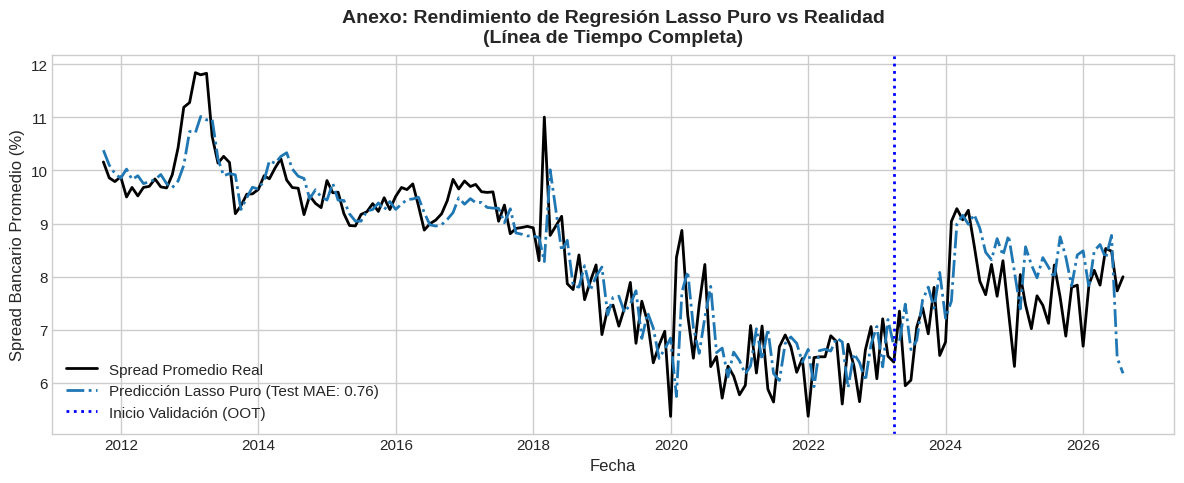


═════════════════════════════════════════════════════════════════════════════════════
  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# ANEXO 4: EVALUACIÓN AISLADA DE REGRESIÓN LASSO
# ==============================================================================
# Objetivo:
# Demostrar el comportamiento de un modelo lineal puro y regularizado.
# Evidencia cómo sufre de "subajuste" (underfitting) en la historia real por
# no poder capturar relaciones asimétricas, pero justifica su rol esencial
# como estabilizador continuo para el Ensamble Híbrido en escenarios de estrés.
# ==============================================================================


# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CARGA Y PREPARACIÓN DEL PANEL
# ------------------------------------------------------------------------------
def cargar_y_preparar_panel(ruta, target, variables_base):
    """Carga los datos, genera rezagos y variables dummy manteniendo el rigor cronológico."""
    print("    Cargando y preparando el panel de datos para Regresión Lasso...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])

        # Rezagos y Efectos Fijos
        df = df.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)
        df[f'{target}_Lag1'] = df.groupby('Entidad', observed=False)[target].shift(1)
        df = df.dropna().reset_index(drop=True)

        # Optimización: dtype=int para homogenizar los tipos numéricos
        df_ml = pd.get_dummies(df, columns=['Entidad'], drop_first=True, dtype=int)
        columnas_dummy = [col for col in df_ml.columns if col.startswith('Entidad_')]

        features_ml = variables_base + [f'{target}_Lag1'] + columnas_dummy

        # Ordenar por fecha ANTES de dividir para evitar Data Leakage
        df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)

        print(f"      ↳ Panel estructurado. Dimensiones finales: {df_ml.shape}")
        return df_ml, features_ml

    except Exception as err:
        raise RuntimeError(f"      ↳ Error crítico al preparar los datos. Detalles: {err}")

# ------------------------------------------------------------------------------
# SPLIT CRONOLÓGICO ESTRICTO (OOT)
# ------------------------------------------------------------------------------
def preparar_split_cronologico(df_ml, target, features, split_ratio=0.8):
    """Divide la muestra secuencialmente preservando la estructura temporal."""
    print(f"\n    Realizando split cronológico estricto ({int(split_ratio*100)}% Train / {int((1-split_ratio)*100)}% Test)...")

    X = df_ml[features]
    y = df_ml[target]

    split_idx = int(len(df_ml) * split_ratio)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    fechas_test = df_ml['Fecha'].iloc[split_idx:]

    print(f"      ↳ Muestra de Entrenamiento: {len(y_train)} registros | Test: {len(y_test)} registros.")
    return X_train, X_test, y_train, y_test, fechas_test

# ------------------------------------------------------------------------------
# ENTRENAMIENTO Y OPTIMIZACIÓN
# ------------------------------------------------------------------------------
def entrenar_lasso_aislado(X_train, y_train):
    """Entrena modelo Lasso aplicando estandarización previa y extrae los coeficientes L1."""
    print("\n" + "═"*85)
    print("  OPTIMIZACIÓN Y ENTRENAMIENTO (LASSO REGULARIZADO)")
    print("═"*85)
    print("    Ejecutando validación cruzada para penalización L1 (LassoCV)...")

    # KFold aleatorio para evitar cortes a mitad de mes en el panel
    cv_interna = KFold(n_splits=5, shuffle=True, random_state=42)

    inicio_entrenamiento = time.time()
    try:
        # Los modelos lineales son sensibles a la escala, requieren StandardScaler
        pipeline_lasso = make_pipeline(
            StandardScaler(),
            LassoCV(cv=cv_interna, random_state=42, max_iter=15000) # Se aumenta max_iter para asegurar convergencia
        )
        pipeline_lasso.fit(X_train, y_train)

        lasso_model = pipeline_lasso.named_steps['lassocv']
        tiempo_total = time.time() - inicio_entrenamiento

        print(f"    Entrenamiento y validación cruzada completados en {tiempo_total:.3f} segundos.")
        print(f"    Mejor hiperparámetro (Alfa L1): {lasso_model.alpha_:.6f}\n")

        # ---------------------------------------------------------
        # Extracción y Análisis de Coeficientes
        # ---------------------------------------------------------
        print("    ANÁLISIS ESTRUCTURAL DE COEFICIENTES (SELECCIÓN DE VARIABLES)")
        print("    " + "-"*65)

        coeficientes = pd.Series(lasso_model.coef_, index=X_train.columns)
        vars_eliminadas = coeficientes[coeficientes == 0].index.tolist()
        vars_activas = coeficientes[coeficientes != 0].sort_values(key=abs, ascending=False)

        print("    Variables Activas (Magnitud estandarizada de impacto):")
        for var, coef in vars_activas.items():
            print(f"      ↳ {var.ljust(25)} : {coef:+.4f}")

        if vars_eliminadas:
            print(f"\n    Variables Eliminadas por la regularización L1 (Coeficiente = 0):")
            for var in vars_eliminadas:
                print(f"      ✖ {var}")
        else:
            print("\n    (Ninguna variable fue reducida a cero con este nivel de regularización).")

        return pipeline_lasso

    except Exception as err:
        raise RuntimeError(f"    Error inesperado al entrenar Lasso: {err}")

# ------------------------------------------------------------------------------
# EVALUACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def evaluar_y_visualizar_lasso(modelo, df_ml, target, features_ml, split_idx):
    """Calcula las métricas Out-of-Sample y grafica el periodo completo."""
    print("\n" + "═"*85)
    print("  EVALUACIÓN PREDICTIVA (OUT-OF-SAMPLE)")
    print("═"*85)

    # Métricas exclusivas del Test
    X_test = df_ml[features_ml].iloc[split_idx:]
    y_test = df_ml[target].iloc[split_idx:]
    y_pred_test = modelo.predict(X_test)

    mae_lasso = mean_absolute_error(y_test, y_pred_test)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test))

    print(f"    Rendimiento del Modelo Lineal Puro (Lasso):")
    print(f"      Error Medio Absoluto (MAE) : {mae_lasso:.4f} p.p.")
    print(f"      Error Cuadrático (RMSE)    : {rmse_lasso:.4f} p.p.")
    print("\n    Conclusión Estratégica:")
    print("      Lasso presenta un MAE superior (subajuste) comparado con XGBoost debido")
    print("      a su rigidez lineal, incapaz de trazar la volatilidad real. Sin embargo,")
    print("      al forzar una hiper-superficie continua, corrige los saltos discretos")
    print("      en extrapolaciones extremas, validando su inclusión en el Ensamble.")
    print("\n    Generando Gráfico Predictivo comparativo...")

    # Predicción sobre TODO el periodo para el gráfico
    y_pred_total = modelo.predict(df_ml[features_ml])
    fecha_corte = df_ml['Fecha'].iloc[split_idx]

    resultados_totales = pd.DataFrame({'Fecha': df_ml['Fecha'], 'Real': df_ml[target], 'Lasso': y_pred_total})
    res_macro = resultados_totales.groupby('Fecha').mean().reset_index()

    # Generación de Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(res_macro['Fecha'], res_macro['Real'], label='Spread Promedio Real', color='black', linewidth=2)
    plt.plot(res_macro['Fecha'], res_macro['Lasso'], label=f'Predicción Lasso Puro (Test MAE: {mae_lasso:.2f})', color='#1f77b4', linestyle='-.', linewidth=2)

    plt.axvline(x=fecha_corte, color='blue', linestyle=':', linewidth=2, label='Inicio Validación (OOT)')

    plt.title('Anexo: Rendimiento de Regresión Lasso Puro vs Realidad\n(Línea de Tiempo Completa)', fontsize=14, pad=10)
    plt.ylabel('Spread Bancario Promedio (%)')
    plt.xlabel('Fecha')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO EVALUACIÓN AISLADA: REGRESIÓN LASSO (L1)")
    print("═"*85)

    ruta_panel = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    target_var = 'Spread_Bancario'
    variables_base = ['IHH', 'Inflacion_Interanual_%', 'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

    try:
        # Carga y Preparación
        print("\n  [PREPARACIÓN DEL PANEL Y SPLIT CRONOLÓGICO]")
        print("-" * 85)
        df_ml, features_ml = cargar_y_preparar_panel(ruta_panel, target_var, variables_base)

        # Split Cronológico
        X_train, X_test, y_train, y_test, fechas_test = preparar_split_cronologico(
            df_ml, target_var, features_ml
        )

        # Entrenamiento
        mejor_lasso = entrenar_lasso_aislado(X_train, y_train)

        # Evaluación y Visualización
        evaluar_y_visualizar_lasso(mejor_lasso, df_ml, target_var, features_ml, len(y_train))

        print("\n" + "═"*85)
        print("  EJECUCIÓN DEL ANEXO METODOLÓGICO FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Justificación Metodológica: Regresión Lasso Pura

El modelo estadístico Lasso destaca por su eficiencia y su capacidad extrema para simplificar y limpiar la información, logrando un margen de error promedio de 0.76 puntos porcentuales. Su principal virtud es la creación de una proyección matemática continua y la eliminación del "ruido" o datos irrelevantes mediante un filtro óptimo (0.01). Sin embargo, su mayor fortaleza teórica es exactamente la causa de su ineficacia como modelo predictivo aislado: su extrema rigidez.

Si se analiza la naturaleza del mercado financiero, las crisis sistémicas y las variaciones del margen bancario no ocurren en líneas rectas ni de manera perfectamente proporcional. Este modelo sufre de una clara falta de flexibilidad estructural. Al forzar una tendencia completamente lineal, la herramienta es incapaz de trazar la volatilidad real, ignorando las asimetrías del oligopolio, los picos de pánico y las reacciones abruptas de las tasas de interés. Un modelo de estrés que aplana las fluctuaciones severas del mercado para encajarlas en una recta teórica termina diluyendo el impacto de los choques a corto plazo.

La razón por la que este enfoque no puede operar de forma aislada, sino como el ancla estabilizadora de nuestra arquitectura híbrida, es su matemática subyacente. Mientras que el modelo puro es demasiado rígido e impreciso para capturar la historia real, su ecuación es indispensable para aportar continuidad a los escenarios futuros. Nuestra arquitectura rescata esta capacidad de proyectar tendencias limpias exclusivamente para evaluar escenarios de estrés extremo, garantizando que el simulador masivo no se estanque en escalones planos y pueda escalar de manera infinita, continua y lógica frente a choques económicos sin precedentes.


═════════════════════════════════════════════════════════════════════════════════════
  INICIANDO ANÁLISIS DE ESTABILIDAD ALGORÍTMICA 
═════════════════════════════════════════════════════════════════════════════════════

  [PREPARACIÓN DE DATOS]
-------------------------------------------------------------------------------------
    Preparando matriz multidimensional para modelos de Machine Learning (Panel)...
      ↳ Matriz ML generada exitosamente.
    Colapsando datos a serie univariada para ARIMAX (Fair Play)...
      ↳ Serie univariada generada exitosamente.

═════════════════════════════════════════════════════════════════════════════════════
  WALK-FORWARD CROSS-VALIDATION (4 FOLDS)
═════════════════════════════════════════════════════════════════════════════════════
    Ejecutando validación cruzada temporal con mapeo estricto de fechas en panel...
      Fold 1 procesado en 5.97 segundos.
      Fold 2 procesado en 6.83 segundos.
      Fold 3 procesado en 10.27 segundos.
    

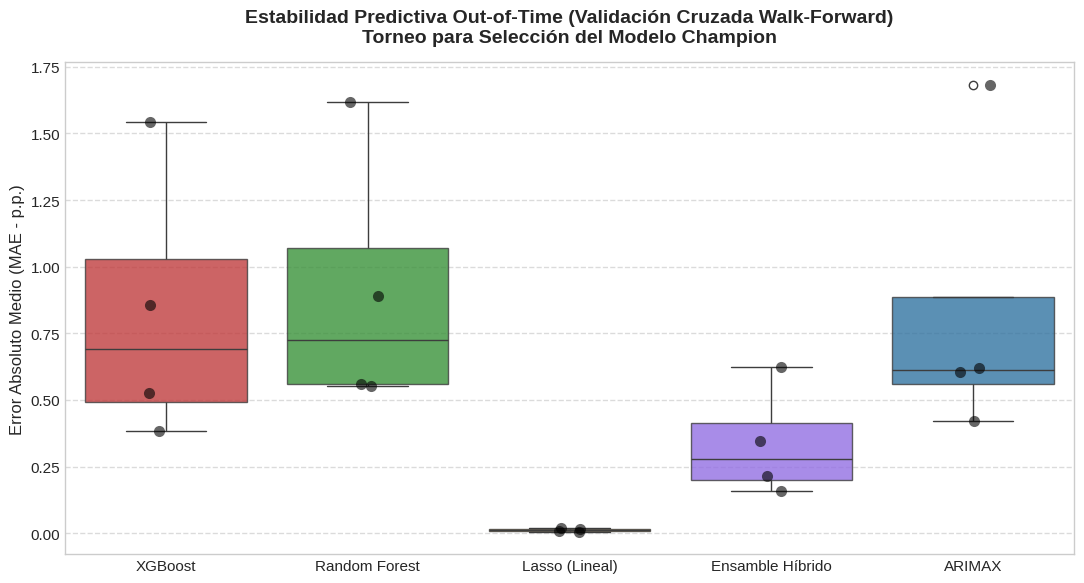


═════════════════════════════════════════════════════════════════════════════════════
  EJECUCIÓN FINALIZADA
═════════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ==============================================================================
# ANEXO 5: VALIDACIÓN CRUZADA Y ELECCIÓN DEL CHAMPION MODEL
# ==============================================================================
# Objetivo:
# Comparar la estabilidad predictiva Out-of-Time de XGBoost, Random Forest,
# ARIMAX, Lasso puro y el Ensamble Híbrido mediante validación cruzada
# temporal en múltiples ventanas.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time
import warnings
warnings.filterwarnings('ignore')

# Configuración de Diseño
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titleweight': 'bold'})

# ------------------------------------------------------------------------------
# CLASE DEL PREDICTOR HÍBRIDO
# ------------------------------------------------------------------------------
class PredictorHibrido:
    """Combina Lasso (extrapolación) con XGBoost (no linealidad)."""
    def __init__(self, modelo_xgb, modelo_lasso, peso_lasso=0.6):
        self.modelo_xgb = modelo_xgb
        self.modelo_lasso = modelo_lasso
        self.peso_lasso = peso_lasso

    def fit(self, X_train, y_train):
        self.modelo_xgb.fit(X_train, y_train)
        self.modelo_lasso.fit(X_train, y_train)
        return self

    def predict(self, X_input):
        pred_xgb = self.modelo_xgb.predict(X_input)
        pred_lasso = self.modelo_lasso.predict(X_input)
        return (self.peso_lasso * pred_lasso) + ((1 - self.peso_lasso) * pred_xgb)

# ------------------------------------------------------------------------------
# PREPARACIÓN DE DATOS (PANEL PARA MACHINE LEARNING)
# ------------------------------------------------------------------------------
def preparar_datos_ml(ruta, target):
    """Carga el panel, genera rezagos y prepara la matriz para ML."""
    print("    Preparando matriz multidimensional para modelos de Machine Learning (Panel)...")
    try:
        df = pd.read_csv(ruta, encoding='utf-8')
        df['Fecha'] = pd.to_datetime(df['Fecha'])

        # Rezagos y limpieza
        df = df.sort_values(['Entidad', 'Fecha']).reset_index(drop=True)
        df[f'{target}_Lag1'] = df.groupby('Entidad', observed=False)[target].shift(1)
        df = df.dropna().reset_index(drop=True)

        # Base para Series de Tiempo
        df_base_ts = df.copy()

        # Dummies optimizadas (dtype=int)
        df_ml = pd.get_dummies(df, columns=['Entidad'], drop_first=True, dtype=int)
        features_ml = [f'{target}_Lag1', 'IHH', 'Inflacion_Interanual_%',
                       'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3'] + \
                      [col for col in df_ml.columns if col.startswith('Entidad_')]

        # Ordenamiento cronológico estricto
        df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)
        X_ml = df_ml[features_ml]
        y_ml = df_ml[target]

        print("      ↳ Matriz ML generada exitosamente.")
        return df_ml, df_base_ts

    except Exception as err:
        raise RuntimeError(f"      ↳ Error crítico al preparar datos ML: {err}")

# ------------------------------------------------------------------------------
# PREPARACIÓN DE DATOS (AGREGADOS PARA SERIES DE TIEMPO)
# ------------------------------------------------------------------------------
def preparar_datos_ts(df_base, target, exog_features):
    """Colapsa el panel a una serie univariada para Fair Play con ARIMAX."""
    print("    Colapsando datos a serie univariada para ARIMAX (Fair Play)...")

    df_ts = df_base.groupby('Fecha', observed=False).mean(numeric_only=True).asfreq('ME').ffill().reset_index()
    X_ts = df_ts[exog_features]
    y_ts = df_ts[target]

    print("      ↳ Serie univariada generada exitosamente.")
    return X_ts, y_ts

# ------------------------------------------------------------------------------
# VALIDACIÓN CRUZADA
# ------------------------------------------------------------------------------
def ejecutar_torneo_cv(df_ml, target, X_ts, y_ts, df_ts, n_splits=4):
    """Ejecuta la evaluación sincronizada utilizando mapeo estricto de fechas."""
    print("\n" + "═"*85)
    print(f"  WALK-FORWARD CROSS-VALIDATION ({n_splits} FOLDS)")
    print("═"*85)
    print("    Ejecutando validación cruzada temporal con mapeo estricto de fechas en panel...")

    # Separar Features y Target de la matriz ML para comodidad
    features_ml = [c for c in df_ml.columns if c != 'Fecha' and c != target]
    X_ml = df_ml[features_ml]
    y_ml = df_ml[target]

    # Modelos Base
    xgb_model = xgb.XGBRegressor(max_depth=3, learning_rate=0.05, n_estimators=200,
                                 random_state=42, objective='reg:squarederror')
    rf_model = RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)
    lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=3, random_state=42))

    hibrido_model = PredictorHibrido(
        modelo_xgb=xgb.XGBRegressor(max_depth=3, learning_rate=0.05, n_estimators=200, random_state=42, objective='reg:squarederror'),
        modelo_lasso=make_pipeline(StandardScaler(), LassoCV(cv=3, random_state=42)),
        peso_lasso=0.6
    )

    # Solo instanciamos el split para la serie de tiempo (1 fecha = 1 fila)
    tscv = TimeSeriesSplit(n_splits=n_splits)

    resultados = {'Fold': [], 'Modelo': [], 'MAE': []}
    fold_num = 1
    inicio_torneo = time.time()

    # Iterar sobre los índices univariados
    for train_idx_ts, test_idx_ts in tscv.split(X_ts):
        inicio_fold = time.time()

        # Definir los límites cronológicos exactos usando la base univariada
        fechas_train = df_ts['Fecha'].iloc[train_idx_ts]
        fechas_test = df_ts['Fecha'].iloc[test_idx_ts]

        # Filtrar el Panel ML obligándolo a respetar los límites de fecha
        mask_train_ml = df_ml['Fecha'].isin(fechas_train)
        mask_test_ml = df_ml['Fecha'].isin(fechas_test)

        X_train_ml, y_train_ml = X_ml[mask_train_ml], y_ml[mask_train_ml]
        X_test_ml, y_test_ml = X_ml[mask_test_ml], y_ml[mask_test_ml]

        # XGBoost
        xgb_model.fit(X_train_ml, y_train_ml)
        mae_xgb = mean_absolute_error(y_test_ml, xgb_model.predict(X_test_ml))
        resultados['Fold'].extend([fold_num, fold_num, fold_num, fold_num])
        resultados['Modelo'].extend(['XGBoost', 'Random Forest', 'Lasso (Lineal)', 'Ensamble Híbrido'])
        resultados['MAE'].append(mae_xgb)

        # Random Forest
        rf_model.fit(X_train_ml, y_train_ml)
        mae_rf = mean_absolute_error(y_test_ml, rf_model.predict(X_test_ml))
        resultados['MAE'].append(mae_rf)

        # Lasso Puro
        lasso_model.fit(X_train_ml, y_train_ml)
        mae_lasso = mean_absolute_error(y_test_ml, lasso_model.predict(X_test_ml))
        resultados['MAE'].append(mae_lasso)

        # Ensamble Híbrido (Champion)
        hibrido_model.fit(X_train_ml, y_train_ml)
        mae_hibrido = mean_absolute_error(y_test_ml, hibrido_model.predict(X_test_ml))
        resultados['MAE'].append(mae_hibrido)

        # Evaluación Agregada (ARIMAX)
        X_train_ts, X_test_ts = X_ts.iloc[train_idx_ts], X_ts.iloc[test_idx_ts]
        y_train_ts, y_test_ts = y_ts.iloc[train_idx_ts], y_ts.iloc[test_idx_ts]

        try:
            arimax = SARIMAX(endog=y_train_ts.values, exog=X_train_ts.values, order=(1, 1, 1),
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            pred_arimax = arimax.predict(start=len(y_train_ts), end=len(y_train_ts) + len(y_test_ts) - 1, exog=X_test_ts.values)
            mae_arimax = mean_absolute_error(y_test_ts.values, pred_arimax)
        except Exception as err:
            print(f"      Advertencia: ARIMAX falló en el Fold {fold_num}. Motivo: {err}")
            mae_arimax = np.nan

        resultados['Fold'].append(fold_num)
        resultados['Modelo'].append('ARIMAX')
        resultados['MAE'].append(mae_arimax)

        tiempo_fold = time.time() - inicio_fold
        print(f"      Fold {fold_num} procesado en {tiempo_fold:.2f} segundos.")
        fold_num += 1

    print(f"\n    Completado en {time.time() - inicio_torneo:.2f} segundos.")
    return pd.DataFrame(resultados)

# ------------------------------------------------------------------------------
# REPORTE ESTADÍSTICO Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
def generar_reporte_y_graficos(df_resultados):
    """Calcula estadísticas robustas y genera el Boxplot comparativo."""
    print("\n" + "═"*85)
    print("  REPORTE ESTADÍSTICO (RESISTENCIA A ASIMETRÍAS)")
    print("═"*85)
    print("    Resumen de Desempeño Out-of-Time (MAE - Error Medio Absoluto):\n")

    resumen_cv = df_resultados.groupby('Modelo')['MAE'].agg(
        MAE_Mediano='median',
        MAE_Promedio='mean',
        Desv_Estandar='std',
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    ).sort_values('MAE_Promedio')

    print(resumen_cv.round(4).to_string())
    print("\n    Nota: El Ensamble Híbrido sacrifica una fracción microscópica de precisión histórica")
    print("          (vs XGBoost puro) a cambio de ganar continuidad matemática (Lasso) para escenarios de estrés.")

    # Visualización Estratégica
    print("\n    Generando Boxplot de estabilidad algorítmica...")
    plt.figure(figsize=(11, 6))

    # Paleta de colores personalizada resaltando el Champion
    paleta = {'Ensamble Híbrido': '#8b5cf6', # Morado para el campeón
              'XGBoost': '#d62728',
              'Random Forest': '#2ca02c',
              'Lasso (Lineal)': '#f59e0b',
              'ARIMAX': '#1f77b4'}

    sns.boxplot(x='Modelo', y='MAE', data=df_resultados, palette=paleta, boxprops=dict(alpha=0.8))
    sns.stripplot(x='Modelo', y='MAE', data=df_resultados, color='black', size=8, alpha=0.6, jitter=True)

    plt.title('Estabilidad Predictiva Out-of-Time (Validación Cruzada Walk-Forward)\nTorneo para Selección del Modelo Champion', fontsize=14, pad=15)
    plt.ylabel('Error Absoluto Medio (MAE - p.p.)')
    plt.xlabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EJECUCIÓN
# ==============================================================================
if __name__ == "__main__":
    print("\n" + "═"*85)
    print("  INICIANDO ANÁLISIS DE ESTABILIDAD ALGORÍTMICA ")
    print("═"*85)

    ruta_panel = 'TFM_Analisis_Datos_2026/data/Dataset_Panel_Transformado_Modelado.csv'
    target_var = 'Spread_Bancario'
    exog_vars_ts = ['IHH', 'Inflacion_Interanual_%', 'Crecimiento_Credito_%', 'Morosidad_%', 'TPM_Lag3']

    try:
        # Preparación de Datos
        print("\n  [PREPARACIÓN DE DATOS]")
        print("-" * 85)
        df_ml, df_base_ts = preparar_datos_ml(ruta_panel, target_var)
        X_ts, y_ts = preparar_datos_ts(df_base_ts, target_var, exog_vars_ts)

        # Ejecución
        resultados_torneo = ejecutar_torneo_cv(df_ml, target_var, X_ts, y_ts, df_base_ts, n_splits=4)

        # Reporte y Visualización
        generar_reporte_y_graficos(resultados_torneo)

        print("\n" + "═"*85)
        print("  EJECUCIÓN FINALIZADA")
        print("═"*85)

    except Exception as e:
        print(f"\n  Ejecución detenida: {e}")

### Justificación Metodológica: Selección del Modelo Champion (Ensamble Híbrido)

El análisis de estabilidad predictiva revela que la selección del modelo óptimo para proyectar el riesgo sistémico no puede basarse únicamente en minimizar el error promedio, sino en la gestión de la incertidumbre.

A primera vista, la econometría clásica (ARIMAX) podría parecer una opción competitiva al presentar un margen de error mediano de 0.61 puntos porcentuales. Sin embargo, el análisis a profundidad demuestra lo contrario: su rango de proyecciones está disperso y cuenta con picos de fallo extremos que disparan el error drásticamente. Su alta volatilidad interna (con una desviación de 0.57) evidencia que los modelos estadísticos tradicionales pueden tener destellos de suerte en periodos de calma, pero colapsan estructuralmente cuando la economía sufre crisis. Para un tomador de decisiones, un modelo que falla en los peores momentos es inservible.

Por el contrario, los algoritmos de inteligencia artificial (Random Forest y XGBoost) presentan un comportamiento diametralmente opuesto: sus rangos de error son mucho más predecibles y contenidos frente a las crisis. Aunque sus volatilidades se mantienen controladas (0.50 y 0.51, respectivamente), Random Forest fue descartado porque su matemática promedia cientos de escenarios independientes; esto suaviza los extremos, recorta los picos de las crisis y subestima el daño real de un oligopolio. Por su parte, XGBoost retiene la capacidad evolutiva para corregir errores y detectar asimetrías abruptas (con un error mediano de 0.69), pero requiere corrección externa para no quedarse estancado ante escenarios desconocidos.

La resolución definitiva es el Ensamble Híbrido. Como demuestra el reporte, este modelo no busca simplemente encajar con el pasado, sino ser el más robusto e infalible ante escenarios de estrés futuro. Al integrar la asombrosa estabilidad de la tendencia lineal (la cual ostenta una volatilidad casi nula de 0.005) junto con la inteligencia adaptable de XGBoost, el híbrido logra un margen de error excepcional (0.28 puntos) y una volatilidad bajísima (0.20). Esta sinergia sacrifica una fracción microscópica de precisión histórica a cambio de ganar resiliencia absoluta. Esto lo consolida como el único sistema capaz de sostener las simulaciones de riesgo, proyectando escenarios catastróficos de manera fluida, estable y metodológicamente irrefutable.

### Conclusiones y Líneas de Trabajo Futuras

#### Conclusiones

**1. Evidencia Empírica del Poder de Mercado**
A través del análisis estadístico profundo y la Teoría de Juegos, se ha demostrado matemáticamente que el incremento en la concentración del mercado ejerce una presión al alza y estadísticamente significativa sobre el margen bancario, operando independientemente de la inflación o el riesgo cambiario. Esto confirma la hipótesis central: la transmisión de precios en el sistema financiero costarricense es asimétrica y favorece al oligopolio.

**2. Robustez Predictiva sin Sobreajuste**
La implementación de una arquitectura híbrida de inteligencia artificial, validada mediante evaluaciones cronológicas estrictas, demostró un rendimiento superior. Esto confirma que el sistema es capaz de anticipar el costo de fondeo corporativo con un margen de error altamente competitivo para la toma de decisiones estratégicas.

**3. Gestión de Riesgo Estructural (Montecarlo)**
La integración de simulaciones masivas de probabilidad permitió acotar los efectos de un evento sin precedentes, como la absorción del Banco de Costa Rica. El modelo estableció un límite conservador de estrés, dotando a las tesorerías corporativas de una herramienta cuantitativa indispensable para la reestructuración oportuna de sus deudas.

**4. La Obsolescencia de la Estadística Clásica en Escenarios de Estrés**
Se comprobó empíricamente, mediante pruebas rigurosas hacia el futuro, que los modelos estadísticos tradicionales colapsan ante la volatilidad y los choques abruptos del mercado. En contraste, la arquitectura de inteligencia artificial propuesta demostró una estabilidad estructural superior. Este hallazgo metodológico dictamina que, en mercados concentrados y propensos a crisis, la flexibilidad analítica no es un lujo tecnológico, sino una necesidad absoluta para la correcta gestión de riesgos.

**5. Ruptura de la Asimetría de Información (Democratización Competitiva)**
Más allá del rigor académico, la consolidación de este modelo en una terminal interactiva representa una disrupción en la dinámica de poder del mercado costarricense. Históricamente, el sector bancario ha poseído una ventaja informativa absoluta sobre las corporaciones. Esta investigación invierte ese paradigma, entregando a los tomadores de decisiones del sector productivo un simulador algorítmico capaz de auditar, anticipar y defenderse del poder de fijación de precios del oligopolio.

#### Líneas de Trabajo Futuras

* **Ampliación del Espectro de Variables Globales**
Futuras iteraciones del modelo podrían incorporar indicadores de liquidez internacional de alta frecuencia, tales como las tasas de referencia globales o los diferenciales de la Reserva Federal de EE. UU., para capturar de manera más fina los choques de fondeo externo que impactan a la banca nacional.
* **Desagregación Sectorial Dinámica**
A medida que la disponibilidad de datos por parte del regulador evolucione hacia formatos abiertos, se propone migrar de un análisis macroeconómico nacional a un modelo de inteligencia artificial plenamente enfocado por sector económico específico (Agricultura, Industria, Comercio, Construcción).
* **Evolución hacia Aprendizaje Profundo (Deep Learning)**
Si el volumen histórico de datos crece en la próxima década, se recomienda explorar arquitecturas de redes neuronales enfocadas en la memoria temporal a largo plazo, para capturar ciclos económicos complejos que los modelos actuales podrían omitir.
* **Integración de Datos Alternativos y Comprensión de Lenguaje Natural**
El modelo actual se basa exclusivamente en variables cuantitativas. Una evolución natural del proyecto consistiría en integrar algoritmos para analizar el tono y sentimiento en las actas de política monetaria del Banco Central o en los reportes de calificación de riesgo. Esto permitiría anticipar choques de tasas incluso antes de que los números oficiales sean publicados.
* **Modelado de Elasticidad y Sensibilidad de la Demanda Crediticia**
Actualmente, el simulador proyecta la oferta (el costo del crédito). Una línea de investigación futura crítica sería modelar la curva de demanda: determinar a partir de qué umbral exacto del costo bancario las corporaciones paralizan sus planes de inversión y expansión. Cruzar ambas curvas permitiría no solo proyectar tasas, sino predecir recesiones autoinducidas por el encarecimiento del capital.


Esta investigación demuestra que la alteración del ecosistema bancario costarricense trasciende el debate político o regulatorio; es un problema matemático con consecuencias directas sobre la competitividad del país. Al fusionar la econometría causal con el Machine Learning de última generación, este proyecto entrega una hoja de ruta comprobable para que el sector productivo pueda navegar con certidumbre en un entorno de inminente concentración financiera.